***
# Supervised | Unsupervised Learning : Detecting and Evaluating Anomalies in Categorical Data Under Supervised and Unsupervised Settings

***
### [**John Pauline Pineda**](https://github.com/JohnPaulinePineda) <br> <br> *June 21, 2025*
***

* [**1. Table of Contents**](#TOC)
    * [1.1 Data Background](#1.1)
    * [1.2 Data Description](#1.2)
    * [1.3 Data Quality Assessment](#1.3)
    * [1.4 Data Preprocessing](#1.4)
        * [1.4.1 Ordinal Binning](#1.4.1)
        * [1.4.2 Category Aggregration and Encoding](#1.4.2)
        * [1.4.3 Synthetic Outlier Labeling via Frequency-Based Tagging](#1.4.3)
        * [1.4.4 Data Splitting](#1.4.4)
    * [1.5 Data Exploration](#1.5)
        * [1.5.1 Exploratory Data Analysis](#1.5.1)
        * [1.5.2 Hypothesis Testing](#1.5.2)
    * [1.6 Model Hyperparameter Tuning and Evaluation Preparation](#1.6)
        * [1.6.1 Model Evaluation Metrics Description](#1.6.1)
        * [1.6.2 Model Hyperparameter Tuning and Evaluation Function Development](#1.6.2)
    * [1.7 Model Development With Synthetic Ground Truth Labels](#1.7)
        * [1.7.1 Isolation Forest](#1.7.1)
        * [1.7.2 Local Outlier Factor](#1.7.2)
        * [1.7.3 K-Nearest Neighbors Outlier Score](#1.7.3)
        * [1.7.4 Histogram-Based Outlier Score](#1.7.4)
    * [1.8 Model Development Without Ground Truth Labels](#1.8)
        * [1.8.1 Isolation Forest](#1.8.1)
        * [1.8.2 Local Outlier Factor](#1.8.2)
        * [1.8.3 K-Nearest Neighbors Outlier Score](#1.8.3)
        * [1.8.4 Histogram-Based Outlier Score](#1.8.4)
    * [1.9 Consolidated Findings](#1.9)
* [**2. Summary**](#Summary)   
* [**3. References**](#References)

***

# 1. Table of Contents <a class="anchor" id="TOC"></a>

This project explores various **Outlier Detection** techniques specifically tailored for datasets with purely categorical features, utilizing multiple tools and libraries available in <mark style="background-color: #CCECFF"><b>Python</b></mark>. The analysis was carried out in two distinct experimental settings: a **Supervised Setting** where synthetic outlier ground truth labels are available, and an **Unsupervised Setting** where no labels are assumed. The methods applied in both settings span a diverse range of non-deep learning techniques, including classical statistical, distance-based, and pattern-based models including: **Isolation Forest**, **Clustering-Based Local Outlier Factor (CBLOF)**, **K-Nearest Neighbors (KNN)** and **Histogram-Based Outlier Score (HBOS)**. In the supervised setting, outlier detection methods were evaluated using traditional classification metrics such as the **Area Under the Receiver Operating Characteristic Curve(AUROC)**, **F1-Score**, and **Precision@N** to assess their ability to distinguish true outliers from normal observations. In contrast, the unsupervised setting employed label-agnostic evaluation strategies, leveraging internal and score-based metrics such as **Silhouette Score on Outlier Scores**, **Outlier Score Entropy** and **Score Variance**. These were complemented by **Principal Component Analysis (PCA) and Uniform Manifold Approximation and Projection (UMAP) Visualizations** to assess the score separability and clustering quality across methods. This dual-framework approach allows for a comprehensive understanding of how each method performs under both label-available and label-free conditions, providing a rigorous basis for outlier detection in categorical data contexts. All results were consolidated in a [<span style="color: #FF0000"><b>Summary</b></span>](#Summary) presented at the end of the document. 

[Outlier Detection](https://link.springer.com/book/10.1007/978-3-319-47578-3) in datasets composed exclusively of categorical variables poses unique challenges because most traditional techniques rely on notions like distance, density, or variance—concepts naturally defined in numerical spaces. In contrast, categorical data lacks inherent numeric relationships or ordering, making it non-trivial to apply distance-based or distribution-based methods directly. However, there are still structured and principled approaches to identify anomalies in such datasets. At its core, an outlier in categorical data is an observation that exhibits a rare or unexpected combination of attribute levels. While each individual variable may contain common categories, their joint configuration may be highly improbable, making the observation an outlier even if no single variable is unusual in isolation. The most basic yet powerful approach begins by examining frequency distributions by way of tallying the count of each unique record configuration and flagging those that occur rarely or not at all in the rest of the data as potential anomalies. To go a step further, one can estimate probabilities of individual variable levels and their joint probabilities across combinations of features. This idea underlies models where the joint likelihood of feature values is used as an outlier score. However, due to the curse of dimensionality — even with a moderate number of variables — the number of possible category combinations grows exponentially, making pure joint frequency estimation unreliable in high dimensions. This motivates the use of dimensionality reduction techniques which maps categorical data into a continuous latent space. In this lower-dimensional space, standard outlier detection techniques can be applied more reliably. In other cases, categorical variables are transformed using encoding schemes to enable the use of well-established numeric algorithms. For instance, one-hot encoding represents each level of a categorical variable as a binary vector, while ordinal encoding assigns arbitrary numeric values to categories. More advanced encodings like entity embeddings can preserve semantic similarity between categories learned via neural networks. Once encoded, various outlier detection methods can be applied, provided the encoding faithfully retains category relationships. An alternative family of methods relies on clustering to group similar categorical records. Outliers are identified either as records not belonging to any dense cluster, or as records that lie far from their cluster's central profile. Finally, rule-based outlier detection extract conditional patterns and flag records that violate these frequent rules. In conclusion, while outlier detection in categorical data is fundamentally different from numeric data due to the lack of inherent distances or ordering, a combination of probability modeling, encoding and transformation, rule learning, and clustering can be used to detect anomalies effectively. The choice of method depends on the structure of the data, the cardinality of features, and whether interpretability or predictive performance is prioritized.

[Outlier Detection In Categorical Data With Ground Truth Labels](https://link.springer.com/book/10.1007/978-3-319-47578-3) becomes a supervised classification task. In this setting, the goal is not just to detect anomalies, but to train models that can predict outlier status reliably, based on known labeled examples. This scenario is relatively rare in real-world applications, but it allows for robust evaluation and algorithm benchmarking. To begin, each observation in the dataset is tagged as either an "inlier" or an "outlier". This label can be derived from domain expertise, human annotation, or synthetic injection of anomalies for experimental setups. The categorical features are then encoded using techniques such as one-hot, ordinal, or entity embeddings so that they can be processed by standard supervised learning models or outlier scoring algorithms. Outlier detection methods are then trained on these encoded features. Even though these methods are typically unsupervised, in this scenario, their outputs—namely, the anomaly scores — can be evaluated using the known labels. Evaluation metrics for this setting include: Precision@N (a variation of precision that is particularly useful in ranking problems like outlier detection for evaluating the top N most confident predictions rather than all predictions), F1-Score (harmonic mean of precision and recall for balancing both metrics, particularly useful when there's a tradeoff), AUROC (Area Under the Receiver Operating Characteristic Curve) (evaluates the model’s ability to distinguish between inliers and outliers across various thresholds, where a higher value indicates better separability). This setup allows for quantitative comparison of different models and hyperparameters. Because true outliers are known, models can be ranked, tuned, and selected with confidence.

[Outlier Detection In Categorical Data Without Ground Truth Labels](https://link.springer.com/book/10.1007/978-3-319-47578-3) is a purely unsupervised learning task. This introduces significant challenges: since the true identity of outliers is unknown, models cannot be trained or validated using standard supervised metrics. Instead, evaluation shifts toward the intrinsic structure of the data and the behavior of anomaly scores. To begin, categorical data must be carefully encoded using strategies that retain their semantic meaning. Common encoding methods include one-hot encoding (to preserve disjoint category identity), ordinal encoding (for ordered categories), and entity embeddings (to capture latent similarity among categories). Once the data is numerically represented, various unsupervised algorithms can be applied to compute outlier scores. These scores reflect the degree of "outlierness" of each observation based on algorithm-specific logic such as isolation depth, density deviation, or cluster distance. In the absence of ground truth labels, the quality of these scores is evaluated using unsupervised score-based metrics. These metrics help assess whether the algorithm has meaningfully differentiated outliers from inliers in a data-driven way including Outlier Score Entropy (measures the unpredictability or uniformity in the distribution of outlier scores where a very low entropy may indicate that the model is not distinguishing between normal and anomalous observations), score variance (examines the spread of anomaly scores across all observations where a low variance suggests that the model assigns similar scores to most points, possibly indicating insensitivity to actual structure), silhouette score on outlier scores (clusters the outlier scores themselves into two or more groups and evaluates how well-separated these clusters are with a high silhouette score suggesting that the model produces score groupings that align with distinguishable data behavior, reinforcing the meaningfulness of its outlier assignments) and clustering stability (assesses how consistent the outlier groupings remain when the input data or model parameters are slightly perturbed with low variability across runs implying that the model is robust and not overly sensitive to sampling artifacts, which boosts confidence in the flagged anomalies). These unsupervised evaluation techniques offer a practical lens through which model performance can be judged, even in the complete absence of labeled anomalies. When multiple models consistently flag the same observations as anomalous, or when scores exhibit structured and stable separation, this further validates the relevance of the identified outliers. Ultimately, there is no single "correct" model in unsupervised outlier detection without ground truth. Instead, a combination of score distribution analysis, clustering behavior, consistency checks, and domain interpretability is used to triangulate the credibility of the results. This makes practitioner insight and a deep understanding of the domain especially important when applying these methods to categorical data.



## 1.1. Data Background <a class="anchor" id="1.1"></a>

An open [Thyroid Disease Dataset](https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data) from [Kaggle](https://www.kaggle.com/) (with all credits attributed to [Jai Naru](https://www.kaggle.com/jainaru) and [Abuchi Onwuegbusi](https://www.kaggle.com/datasets/abuchionwuegbusi/thyroid-cancer-recurrence-prediction/data)) was used for the analysis as consolidated from the following primary sources: 
1. Reference Repository entitled **Differentiated Thyroid Cancer Recurrence** from [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/915/differentiated+thyroid+cancer+recurrence)
2. Research Paper entitled **Machine Learning for Risk Stratification of Thyroid Cancer Patients: a 15-year Cohort Study** from the [European Archives of Oto-Rhino-Laryngology](https://link.springer.com/article/10.1007/s00405-023-08299-w)

This study hypothesized that the various clinicopathological characteristics influence differentiated thyroid cancer recurrence between patients.

The dichotomous categorical variable for the study is:
* <span style="color: #FF0000">Recurred</span> - Status of the patient (Yes, Recurrence of differentiated thyroid cancer | No, No recurrence of differentiated thyroid cancer)

The predictor variables for the study are:
* <span style="color: #FF0000">Age</span> - Patient's age (Years)
* <span style="color: #FF0000">Gender</span> - Patient's sex (M | F)
* <span style="color: #FF0000">Smoking</span> - Indication of smoking (Yes | No)
* <span style="color: #FF0000">Hx Smoking</span> - Indication of smoking history (Yes | No)
* <span style="color: #FF0000">Hx Radiotherapy</span> - Indication of radiotherapy history for any condition (Yes | No)
* <span style="color: #FF0000">Thyroid Function</span> - Status of thyroid function (Clinical Hyperthyroidism, Hypothyroidism | Subclinical Hyperthyroidism, Hypothyroidism | Euthyroid)
* <span style="color: #FF0000">Physical Examination</span> - Findings from physical examination including palpation of the thyroid gland and surrounding structures (Normal | Diffuse Goiter | Multinodular Goiter | Single Nodular Goiter Left, Right)
* <span style="color: #FF0000">Adenopathy</span> - Indication of enlarged lymph nodes in the neck region (No | Right | Extensive | Left | Bilateral | Posterior)
* <span style="color: #FF0000">Pathology</span> - Specific thyroid cancer type as determined by pathology examination of biopsy samples (Follicular | Hurthel Cell | Micropapillary | Papillary)
* <span style="color: #FF0000">Focality</span> - Indication if the cancer is limited to one location or present in multiple locations (Uni-Focal | Multi-Focal)
* <span style="color: #FF0000">Risk</span> - Risk category of the cancer based on various factors, such as tumor size, extent of spread, and histological type (Low | Intermediate | High)
* <span style="color: #FF0000">T</span> - Tumor classification based on its size and extent of invasion into nearby structures (T1a | T1b | T2 | T3a | T3b | T4a | T4b)
* <span style="color: #FF0000">N</span> - Nodal classification indicating the involvement of lymph nodes (N0 | N1a | N1b)
* <span style="color: #FF0000">M</span> - Metastasis classification indicating the presence or absence of distant metastases (M0 | M1)
* <span style="color: #FF0000">Stage</span> - Overall stage of the cancer, typically determined by combining T, N, and M classifications (I | II | III | IVa | IVb)
* <span style="color: #FF0000">Response</span> - Cancer's response to treatment (Biochemical Incomplete | Indeterminate | Excellent | Structural Incomplete)

While the original dataset was designed for a categorical classification task predicting thyroid cancer recurrence, this study repurposes it for an outlier detection framework. In this revised context, the original response variable will be excluded, and only a subset of predictors—specifically those capturing clinicopathological characteristics—will be retained. These predictors will be converted into binary categorical variables to standardize representation. A synthetic binary response variable will then be generated using a frequency-based tagging strategy, labeling rare combinations of category levels as outliers and the rest as inliers. The goal is to estimate outlier scores for each observation and assess model performance in both supervised settings (using the synthetic labels) and unsupervised settings (without labels). This approach allows for evaluating the effectiveness of categorical outlier detection methods in a medically relevant context where rare clinicopathological profiles may signify atypical or high-risk cases.


## 1.2. Data Description <a class="anchor" id="1.2"></a>

1. The initial tabular dataset was comprised of 383 observations and 17 variables (including 1 target and 16 predictors).
    * **383 rows** (observations)
    * **17 columns** (variables)
        * **1/17 target** (categorical)
             * <span style="color: #FF0000">Recurred</span>
        * **1/17 predictor** (numeric)
             * <span style="color: #FF0000">Age</span>
        * **16/17 predictor** (categorical)
             * <span style="color: #FF0000">Gender</span>
             * <span style="color: #FF0000">Smoking</span>
             * <span style="color: #FF0000">Hx_Smoking</span>
             * <span style="color: #FF0000">Hx_Radiotherapy</span>
             * <span style="color: #FF0000">Thyroid_Function</span>
             * <span style="color: #FF0000">Physical_Examination</span>
             * <span style="color: #FF0000">Adenopathy</span>
             * <span style="color: #FF0000">Pathology</span>
             * <span style="color: #FF0000">Focality</span>
             * <span style="color: #FF0000">Risk</span>
             * <span style="color: #FF0000">T</span>
             * <span style="color: #FF0000">N</span>
             * <span style="color: #FF0000">M</span>
             * <span style="color: #FF0000">Stage</span>
             * <span style="color: #FF0000">Response</span>


In [231]:
##################################
# Loading Python Libraries
##################################
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import itertools
import os
import pickle
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
%matplotlib inline

from operator import truediv
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, entropy

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, roc_auc_score, precision_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, ParameterGrid
import umap.umap_ as umap

from pyod.models.knn import KNN
from pyod.models.hbos import HBOS
from pyod.models.cblof import CBLOF
from pyod.models.iforest import IForest

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="umap")


In [232]:
##################################
# Defining file paths
##################################
DATASETS_ORIGINAL_PATH = r"datasets\original"
DATASETS_FINAL_PATH = r"datasets\final\complete"
DATASETS_FINAL_TRAIN_PATH = r"datasets\final\train"
DATASETS_FINAL_TRAIN_FEATURES_PATH = r"datasets\final\train\features"
DATASETS_FINAL_TRAIN_TARGET_PATH = r"datasets\final\train\target"
DATASETS_FINAL_VALIDATION_PATH = r"datasets\final\validation"
DATASETS_FINAL_VALIDATION_FEATURES_PATH = r"datasets\final\validation\features"
DATASETS_FINAL_VALIDATION_TARGET_PATH = r"datasets\final\validation\target"
DATASETS_FINAL_TEST_PATH = r"datasets\final\test"
DATASETS_FINAL_TEST_FEATURES_PATH = r"datasets\final\test\features"
DATASETS_FINAL_TEST_TARGET_PATH = r"datasets\final\test\target"
MODELS_PATH = r"models"


In [233]:
##################################
# Loading the dataset
# from the DATASETS_ORIGINAL_PATH
##################################
thyroid_cancer = pd.read_csv(os.path.join("..", DATASETS_ORIGINAL_PATH, "Thyroid_Diff.csv"))


In [234]:
##################################
# Performing a general exploration of the dataset
##################################
print('Dataset Dimensions: ')
display(thyroid_cancer.shape)


Dataset Dimensions: 


(383, 17)

In [235]:
##################################
# Listing the column names and data types
##################################
print('Column Names and Data Types:')
display(thyroid_cancer.dtypes)


Column Names and Data Types:


Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiotherapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                object
dtype: object

In [236]:
##################################
# Renaming and standardizing the column names
# to replace blanks with undercores
##################################
thyroid_cancer.columns = thyroid_cancer.columns.str.replace(" ", "_")


In [237]:
##################################
# Taking a snapshot of the dataset
##################################
thyroid_cancer.head()


,Age,Gender,Smoking,Hx_Smoking,Hx_Radiotherapy,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [238]:
##################################
# Selecting categorical columns (both object and categorical types)
# and listing the unique categorical levels
##################################
cat_cols = thyroid_cancer.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"Categorical | Object Column: {col}")
    print(thyroid_cancer[col].unique())  
    print("-" * 40)
    

Categorical | Object Column: Gender
['F' 'M']
----------------------------------------
Categorical | Object Column: Smoking
['No' 'Yes']
----------------------------------------
Categorical | Object Column: Hx_Smoking
['No' 'Yes']
----------------------------------------
Categorical | Object Column: Hx_Radiotherapy
['No' 'Yes']
----------------------------------------
Categorical | Object Column: Thyroid_Function
['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']
----------------------------------------
Categorical | Object Column: Physical_Examination
['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']
----------------------------------------
Categorical | Object Column: Adenopathy
['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']
----------------------------------------
Categorical | Object Column: Pathology
['Micropapillary' 'Papillary' 'Folli

In [239]:
##################################
# Correcting a category level
##################################
thyroid_cancer["Pathology"] = thyroid_cancer["Pathology"].replace("Hurthel cell", "Hurthle Cell")


In [240]:
##################################
# Setting the levels of the categorical variables
##################################
thyroid_cancer['Recurred'] = thyroid_cancer['Recurred'].astype('category')
thyroid_cancer['Recurred'] = thyroid_cancer['Recurred'].cat.set_categories(['No', 'Yes'], ordered=True)
thyroid_cancer['Gender'] = thyroid_cancer['Gender'].astype('category')
thyroid_cancer['Gender'] = thyroid_cancer['Gender'].cat.set_categories(['M', 'F'], ordered=True)
thyroid_cancer['Smoking'] = thyroid_cancer['Smoking'].astype('category')
thyroid_cancer['Smoking'] = thyroid_cancer['Smoking'].cat.set_categories(['No', 'Yes'], ordered=True)
thyroid_cancer['Hx_Smoking'] = thyroid_cancer['Hx_Smoking'].astype('category')
thyroid_cancer['Hx_Smoking'] = thyroid_cancer['Hx_Smoking'].cat.set_categories(['No', 'Yes'], ordered=True)
thyroid_cancer['Hx_Radiotherapy'] = thyroid_cancer['Hx_Radiotherapy'].astype('category')
thyroid_cancer['Hx_Radiotherapy'] = thyroid_cancer['Hx_Radiotherapy'].cat.set_categories(['No', 'Yes'], ordered=True)
thyroid_cancer['Thyroid_Function'] = thyroid_cancer['Thyroid_Function'].astype('category')
thyroid_cancer['Thyroid_Function'] = thyroid_cancer['Thyroid_Function'].cat.set_categories(['Euthyroid', 'Subclinical Hypothyroidism', 'Subclinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Clinical Hyperthyroidism'], ordered=True)
thyroid_cancer['Physical_Examination'] = thyroid_cancer['Physical_Examination'].astype('category')
thyroid_cancer['Physical_Examination'] = thyroid_cancer['Physical_Examination'].cat.set_categories(['Normal', 'Single nodular goiter-left', 'Single nodular goiter-right', 'Multinodular goiter', 'Diffuse goiter'], ordered=True)
thyroid_cancer['Adenopathy'] = thyroid_cancer['Adenopathy'].astype('category')
thyroid_cancer['Adenopathy'] = thyroid_cancer['Adenopathy'].cat.set_categories(['No', 'Left', 'Right', 'Bilateral', 'Posterior', 'Extensive'], ordered=True)
thyroid_cancer['Pathology'] = thyroid_cancer['Pathology'].astype('category')
thyroid_cancer['Pathology'] = thyroid_cancer['Pathology'].cat.set_categories(['Hurthle Cell', 'Follicular', 'Micropapillary', 'Papillary'], ordered=True)
thyroid_cancer['Focality'] = thyroid_cancer['Focality'].astype('category')
thyroid_cancer['Focality'] = thyroid_cancer['Focality'].cat.set_categories(['Uni-Focal', 'Multi-Focal'], ordered=True)
thyroid_cancer['Risk'] = thyroid_cancer['Risk'].astype('category')
thyroid_cancer['Risk'] = thyroid_cancer['Risk'].cat.set_categories(['Low', 'Intermediate', 'High'], ordered=True)
thyroid_cancer['T'] = thyroid_cancer['T'].astype('category')
thyroid_cancer['T'] = thyroid_cancer['T'].cat.set_categories(['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'], ordered=True)
thyroid_cancer['N'] = thyroid_cancer['N'].astype('category')
thyroid_cancer['N'] = thyroid_cancer['N'].cat.set_categories(['N0', 'N1a', 'N1b'], ordered=True)
thyroid_cancer['M'] = thyroid_cancer['M'].astype('category')
thyroid_cancer['M'] = thyroid_cancer['M'].cat.set_categories(['M0', 'M1'], ordered=True)
thyroid_cancer['Stage'] = thyroid_cancer['Stage'].astype('category')
thyroid_cancer['Stage'] = thyroid_cancer['Stage'].cat.set_categories(['I', 'II', 'III', 'IVA', 'IVB'], ordered=True)
thyroid_cancer['Response'] = thyroid_cancer['Response'].astype('category')
thyroid_cancer['Response'] = thyroid_cancer['Response'].cat.set_categories(['Excellent', 'Structural Incomplete', 'Biochemical Incomplete', 'Indeterminate'], ordered=True)


In [241]:
##################################
# Performing a general exploration of the numeric variables
##################################
print('Numeric Variable Summary:')
display(thyroid_cancer.describe(include='number').transpose())


Numeric Variable Summary:


,count,mean,std,min,25%,50%,75%,max
Age,383.0,40.866841,15.134494,15.0,29.0,37.0,51.0,82.0


In [242]:
##################################
# Performing a general exploration of the categorical variables
##################################
print('Categorical Variable Summary:')
display(thyroid_cancer.describe(include='category').transpose())


Categorical Variable Summary:


,count,unique,top,freq
Gender,383,2,F,312
Smoking,383,2,No,334
Hx_Smoking,383,2,No,355
Hx_Radiotherapy,383,2,No,376
Thyroid_Function,383,5,Euthyroid,332
Physical_Examination,383,5,Single nodular goiter-right,140
Adenopathy,383,6,No,277
Pathology,383,4,Papillary,287
Focality,383,2,Uni-Focal,247
Risk,383,3,Low,249


In [243]:
##################################
# Performing a general exploration of the categorical variable levels
# based on the ordered categories
##################################
ordered_cat_cols = thyroid_cancer.select_dtypes(include=["category"]).columns
for col in ordered_cat_cols:
    print(f"Column: {col}")
    print("Absolute Frequencies:")
    print(thyroid_cancer[col].value_counts().reindex(thyroid_cancer[col].cat.categories))
    print("\nNormalized Frequencies:")
    print(thyroid_cancer[col].value_counts(normalize=True).reindex(thyroid_cancer[col].cat.categories))
    print("-" * 50)
    

Column: Gender
Absolute Frequencies:
M     71
F    312
Name: count, dtype: int64

Normalized Frequencies:
M    0.185379
F    0.814621
Name: proportion, dtype: float64
--------------------------------------------------
Column: Smoking
Absolute Frequencies:
No     334
Yes     49
Name: count, dtype: int64

Normalized Frequencies:
No     0.872063
Yes    0.127937
Name: proportion, dtype: float64
--------------------------------------------------
Column: Hx_Smoking
Absolute Frequencies:
No     355
Yes     28
Name: count, dtype: int64

Normalized Frequencies:
No     0.926893
Yes    0.073107
Name: proportion, dtype: float64
--------------------------------------------------
Column: Hx_Radiotherapy
Absolute Frequencies:
No     376
Yes      7
Name: count, dtype: int64

Normalized Frequencies:
No     0.981723
Yes    0.018277
Name: proportion, dtype: float64
--------------------------------------------------
Column: Thyroid_Function
Absolute Frequencies:
Euthyroid                      332
Subclini

## 1.3. Data Quality Assessment <a class="anchor" id="1.3"></a>

Data quality findings based on assessment are as follows:
1. A total of 19 duplicated rows were identified.
    * In total, 34 observations were affected, consisting of 16 unique occurrences and 19 subsequent duplicates.
    * These 19 duplicates spanned 16 distinct variations, meaning some variations had multiple duplicates.
    * To clean the dataset, all 19 duplicate rows were removed, retaining only the first occurrence of each of the 16 unique variations.
2. No missing data noted for any variable with Null.Count>0 and Fill.Rate<1.0.
3. Low variance observed for 8 variables with First.Second.Mode.Ratio>5.
    * <span style="color: #FF0000">Hx_Radiotherapy</span>: First.Second.Mode.Ratio = 51.000 (comprised 2 category levels)
    * <span style="color: #FF0000">M</span>: First.Second.Mode.Ratio = 19.222 (comprised 2 category levels)
    * <span style="color: #FF0000">Thyroid_Function</span>: First.Second.Mode.Ratio = 15.650 (comprised 5 category levels)
    * <span style="color: #FF0000">Hx_Smoking</span>: First.Second.Mode.Ratio = 12.000 (comprised 2 category levels)
    * <span style="color: #FF0000">Stage</span>: First.Second.Mode.Ratio = 9.812 (comprised 5 category levels)
    * <span style="color: #FF0000">Smoking</span>: First.Second.Mode.Ratio = 6.428 (comprised 2 category levels)
    * <span style="color: #FF0000">Pathology</span>: First.Second.Mode.Ratio = 6.022 (comprised 4 category levels)
    * <span style="color: #FF0000">Adenopathy</span>: First.Second.Mode.Ratio = 5.375 (comprised 5 category levels)
4. No low variance observed for any variable with Unique.Count.Ratio>10.
5. No high skewness observed for any variable with Skewness>3 or Skewness<(-3).


In [244]:
##################################
# Counting the number of duplicated rows
##################################
thyroid_cancer.duplicated().sum()


np.int64(19)

In [245]:
##################################
# Exploring the duplicated rows
##################################
duplicated_rows = thyroid_cancer[thyroid_cancer.duplicated(keep=False)]
display(duplicated_rows)


,Age,Gender,Smoking,Hx_Smoking,Hx_Radiotherapy,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
22,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
32,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
38,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
40,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
61,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
66,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
67,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
69,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No


In [246]:
##################################
# Checking if duplicated rows have identical values across all columns
##################################
num_unique_dup_rows = duplicated_rows.drop_duplicates().shape[0]
num_total_dup_rows = duplicated_rows.shape[0]
if num_unique_dup_rows == 1:
    print("All duplicated rows have the same values across all columns.")
else:
    print(f"There are {num_unique_dup_rows} unique versions among the {num_total_dup_rows} duplicated rows.")
    

There are 16 unique versions among the 35 duplicated rows.


In [247]:
##################################
# Counting the unique variations among duplicated rows
##################################
unique_dup_variations = duplicated_rows.drop_duplicates()
variation_counts = duplicated_rows.value_counts().reset_index(name="Count")
print("Unique duplicated row variations and their counts:")
display(variation_counts)


Unique duplicated row variations and their counts:


,Age,Gender,Smoking,Hx_Smoking,Hx_Radiotherapy,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred,Count
0,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,4
1,32,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,3
2,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
3,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
4,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
5,29,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No,2
6,31,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
7,34,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
8,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No,2
9,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No,2


In [248]:
##################################
# Removing the duplicated rows and
# retaining only the first occurrence
##################################
thyroid_cancer_row_filtered = thyroid_cancer.drop_duplicates(keep="first")
print('Dataset Dimensions: ')
display(thyroid_cancer_row_filtered.shape)


Dataset Dimensions: 


(364, 17)

In [249]:
##################################
# Gathering the data types for each column
##################################
data_type_list = list(thyroid_cancer_row_filtered.dtypes)


In [250]:
##################################
# Gathering the variable names for each column
##################################
variable_name_list = list(thyroid_cancer_row_filtered.columns)


In [251]:
##################################
# Gathering the number of observations for each column
##################################
row_count_list = list([len(thyroid_cancer_row_filtered)] * len(thyroid_cancer_row_filtered.columns))


In [252]:
##################################
# Gathering the number of missing data for each column
##################################
null_count_list = list(thyroid_cancer_row_filtered.isna().sum(axis=0))


In [253]:
##################################
# Gathering the number of non-missing data for each column
##################################
non_null_count_list = list(thyroid_cancer_row_filtered.count())


In [254]:
##################################
# Gathering the missing data percentage for each column
##################################
fill_rate_list = map(truediv, non_null_count_list, row_count_list)


In [255]:
##################################
# Formulating the summary
# for all columns
##################################
all_column_quality_summary = pd.DataFrame(zip(variable_name_list,
                                              data_type_list,
                                              row_count_list,
                                              non_null_count_list,
                                              null_count_list,
                                              fill_rate_list), 
                                        columns=['Column.Name',
                                                 'Column.Type',
                                                 'Row.Count',
                                                 'Non.Null.Count',
                                                 'Null.Count',                                                 
                                                 'Fill.Rate'])
display(all_column_quality_summary)


,Column.Name,Column.Type,Row.Count,Non.Null.Count,Null.Count,Fill.Rate
0,Age,int64,364,364,0,1.0
1,Gender,category,364,364,0,1.0
2,Smoking,category,364,364,0,1.0
3,Hx_Smoking,category,364,364,0,1.0
4,Hx_Radiotherapy,category,364,364,0,1.0
5,Thyroid_Function,category,364,364,0,1.0
6,Physical_Examination,category,364,364,0,1.0
7,Adenopathy,category,364,364,0,1.0
8,Pathology,category,364,364,0,1.0
9,Focality,category,364,364,0,1.0


In [256]:
##################################
# Counting the number of columns
# with Fill.Rate < 1.00
##################################
len(all_column_quality_summary[(all_column_quality_summary['Fill.Rate']<1)])


0

In [257]:
##################################
# Identifying the rows
# with Fill.Rate < 0.90
##################################
column_low_fill_rate = all_column_quality_summary[(all_column_quality_summary['Fill.Rate']<0.90)]


In [258]:
##################################
# Gathering the indices for each observation
##################################
row_index_list = thyroid_cancer_row_filtered.index


In [259]:
##################################
# Gathering the number of columns for each observation
##################################
column_count_list = list([len(thyroid_cancer_row_filtered.columns)] * len(thyroid_cancer_row_filtered))


In [260]:
##################################
# Gathering the number of missing data for each row
##################################
null_row_list = list(thyroid_cancer_row_filtered.isna().sum(axis=1))


In [261]:
##################################
# Gathering the missing data percentage for each column
##################################
missing_rate_list = map(truediv, null_row_list, column_count_list)


In [262]:
##################################
# Identifying the rows
# with missing data
##################################
all_row_quality_summary = pd.DataFrame(zip(row_index_list,
                                           column_count_list,
                                           null_row_list,
                                           missing_rate_list), 
                                        columns=['Row.Name',
                                                 'Column.Count',
                                                 'Null.Count',                                                 
                                                 'Missing.Rate'])
display(all_row_quality_summary)


,Row.Name,Column.Count,Null.Count,Missing.Rate
0,0,17,0,0.0
1,1,17,0,0.0
2,2,17,0,0.0
3,3,17,0,0.0
4,4,17,0,0.0
...,...,...,...,...
359,378,17,0,0.0
360,379,17,0,0.0
361,380,17,0,0.0
362,381,17,0,0.0


In [263]:
##################################
# Counting the number of rows
# with Missing.Rate > 0.00
##################################
len(all_row_quality_summary[(all_row_quality_summary['Missing.Rate']>0.00)])


0

In [264]:
##################################
# Formulating the dataset
# with numeric columns only
##################################
thyroid_cancer_numeric = thyroid_cancer_row_filtered.select_dtypes(include='number')


In [265]:
##################################
# Gathering the variable names for each numeric column
##################################
numeric_variable_name_list = thyroid_cancer_numeric.columns


In [266]:
##################################
# Gathering the minimum value for each numeric column
##################################
numeric_minimum_list = thyroid_cancer_numeric.min()


In [267]:
##################################
# Gathering the mean value for each numeric column
##################################
numeric_mean_list = thyroid_cancer_numeric.mean()


In [268]:
##################################
# Gathering the median value for each numeric column
##################################
numeric_median_list = thyroid_cancer_numeric.median()


In [269]:
##################################
# Gathering the maximum value for each numeric column
##################################
numeric_maximum_list = thyroid_cancer_numeric.max()


In [270]:
##################################
# Gathering the first mode values for each numeric column
##################################
numeric_first_mode_list = [thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[0] for x in thyroid_cancer_numeric]


In [271]:
##################################
# Gathering the second mode values for each numeric column
##################################
numeric_second_mode_list = [thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[1] for x in thyroid_cancer_numeric]


In [272]:
##################################
# Gathering the count of first mode values for each numeric column
##################################
numeric_first_mode_count_list = [thyroid_cancer_numeric[x].isin([thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[0]]).sum() for x in thyroid_cancer_numeric]


In [273]:
##################################
# Gathering the count of second mode values for each numeric column
##################################
numeric_second_mode_count_list = [thyroid_cancer_numeric[x].isin([thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[1]]).sum() for x in thyroid_cancer_numeric]


In [274]:
##################################
# Gathering the first mode to second mode ratio for each numeric column
##################################
numeric_first_second_mode_ratio_list = map(truediv, numeric_first_mode_count_list, numeric_second_mode_count_list)


In [275]:
##################################
# Gathering the count of unique values for each numeric column
##################################
numeric_unique_count_list = thyroid_cancer_numeric.nunique(dropna=True)


In [276]:
##################################
# Gathering the number of observations for each numeric column
##################################
numeric_row_count_list = list([len(thyroid_cancer_numeric)] * len(thyroid_cancer_numeric.columns))


In [277]:
##################################
# Gathering the unique to count ratio for each numeric column
##################################
numeric_unique_count_ratio_list = map(truediv, numeric_unique_count_list, numeric_row_count_list)


In [278]:
##################################
# Gathering the skewness value for each numeric column
##################################
numeric_skewness_list = thyroid_cancer_numeric.skew()


In [279]:
##################################
# Gathering the kurtosis value for each numeric column
##################################
numeric_kurtosis_list = thyroid_cancer_numeric.kurtosis()


In [280]:
##################################
# Generating a column quality summary for the numeric column
##################################
numeric_column_quality_summary = pd.DataFrame(zip(numeric_variable_name_list,
                                                numeric_minimum_list,
                                                numeric_mean_list,
                                                numeric_median_list,
                                                numeric_maximum_list,
                                                numeric_first_mode_list,
                                                numeric_second_mode_list,
                                                numeric_first_mode_count_list,
                                                numeric_second_mode_count_list,
                                                numeric_first_second_mode_ratio_list,
                                                numeric_unique_count_list,
                                                numeric_row_count_list,
                                                numeric_unique_count_ratio_list,
                                                numeric_skewness_list,
                                                numeric_kurtosis_list), 
                                        columns=['Numeric.Column.Name',
                                                 'Minimum',
                                                 'Mean',
                                                 'Median',
                                                 'Maximum',
                                                 'First.Mode',
                                                 'Second.Mode',
                                                 'First.Mode.Count',
                                                 'Second.Mode.Count',
                                                 'First.Second.Mode.Ratio',
                                                 'Unique.Count',
                                                 'Row.Count',
                                                 'Unique.Count.Ratio',
                                                 'Skewness',
                                                 'Kurtosis'])
display(numeric_column_quality_summary)


,Numeric.Column.Name,Minimum,Mean,Median,Maximum,First.Mode,Second.Mode,First.Mode.Count,Second.Mode.Count,First.Second.Mode.Ratio,Unique.Count,Row.Count,Unique.Count.Ratio,Skewness,Kurtosis
0,Age,15,41.25,38.0,82,31,27,21,13,1.615385,65,364,0.178571,0.678269,-0.359255


In [281]:
##################################
# Counting the number of numeric columns
# with First.Second.Mode.Ratio > 5.00
##################################
len(numeric_column_quality_summary[(numeric_column_quality_summary['First.Second.Mode.Ratio']>5)])


0

In [282]:
##################################
# Counting the number of numeric columns
# with Unique.Count.Ratio > 10.00
##################################
len(numeric_column_quality_summary[(numeric_column_quality_summary['Unique.Count.Ratio']>10)])


0

In [283]:
##################################
# Counting the number of numeric columns
# with Skewness > 3.00 or Skewness < -3.00
##################################
len(numeric_column_quality_summary[(numeric_column_quality_summary['Skewness']>3) | (numeric_column_quality_summary['Skewness']<(-3))])


0

In [284]:
##################################
# Formulating the dataset
# with categorical columns only
##################################
thyroid_cancer_categorical = thyroid_cancer_row_filtered.select_dtypes(include='category')


In [285]:
##################################
# Gathering the variable names for the categorical column
##################################
categorical_variable_name_list = thyroid_cancer_categorical.columns


In [286]:
##################################
# Gathering the first mode values for each categorical column
##################################
categorical_first_mode_list = [thyroid_cancer_row_filtered[x].value_counts().index.tolist()[0] for x in thyroid_cancer_categorical]


In [287]:
##################################
# Gathering the second mode values for each categorical column
##################################
categorical_second_mode_list = [thyroid_cancer_row_filtered[x].value_counts().index.tolist()[1] for x in thyroid_cancer_categorical]


In [288]:
##################################
# Gathering the count of first mode values for each categorical column
##################################
categorical_first_mode_count_list = [thyroid_cancer_categorical[x].isin([thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[0]]).sum() for x in thyroid_cancer_categorical]


In [289]:
##################################
# Gathering the count of second mode values for each categorical column
##################################
categorical_second_mode_count_list = [thyroid_cancer_categorical[x].isin([thyroid_cancer_row_filtered[x].value_counts(dropna=True).index.tolist()[1]]).sum() for x in thyroid_cancer_categorical]


In [290]:
##################################
# Gathering the first mode to second mode ratio for each categorical column
##################################
categorical_first_second_mode_ratio_list = map(truediv, categorical_first_mode_count_list, categorical_second_mode_count_list)


In [291]:
##################################
# Gathering the count of unique values for each categorical column
##################################
categorical_unique_count_list = thyroid_cancer_categorical.nunique(dropna=True)


In [292]:
##################################
# Gathering the number of observations for each categorical column
##################################
categorical_row_count_list = list([len(thyroid_cancer_categorical)] * len(thyroid_cancer_categorical.columns))


In [293]:
##################################
# Gathering the unique to count ratio for each categorical column
##################################
categorical_unique_count_ratio_list = map(truediv, categorical_unique_count_list, categorical_row_count_list)


In [294]:
##################################
# Generating a column quality summary for the categorical columns
##################################
categorical_column_quality_summary = pd.DataFrame(zip(categorical_variable_name_list,
                                                    categorical_first_mode_list,
                                                    categorical_second_mode_list,
                                                    categorical_first_mode_count_list,
                                                    categorical_second_mode_count_list,
                                                    categorical_first_second_mode_ratio_list,
                                                    categorical_unique_count_list,
                                                    categorical_row_count_list,
                                                    categorical_unique_count_ratio_list), 
                                        columns=['Categorical.Column.Name',
                                                 'First.Mode',
                                                 'Second.Mode',
                                                 'First.Mode.Count',
                                                 'Second.Mode.Count',
                                                 'First.Second.Mode.Ratio',
                                                 'Unique.Count',
                                                 'Row.Count',
                                                 'Unique.Count.Ratio'])
display(categorical_column_quality_summary)


,Categorical.Column.Name,First.Mode,Second.Mode,First.Mode.Count,Second.Mode.Count,First.Second.Mode.Ratio,Unique.Count,Row.Count,Unique.Count.Ratio
0,Gender,F,M,293,71,4.126761,2,364,0.005495
1,Smoking,No,Yes,315,49,6.428571,2,364,0.005495
2,Hx_Smoking,No,Yes,336,28,12.000000,2,364,0.005495
3,Hx_Radiotherapy,No,Yes,357,7,51.000000,2,364,0.005495
4,Thyroid_Function,Euthyroid,Clinical Hyperthyroidism,313,20,15.650000,5,364,0.013736
5,Physical_Examination,Multinodular goiter,Single nodular goiter-right,135,127,1.062992,5,364,0.013736
6,Adenopathy,No,Right,258,48,5.375000,6,364,0.016484
7,Pathology,Papillary,Micropapillary,271,45,6.022222,4,364,0.010989
8,Focality,Uni-Focal,Multi-Focal,228,136,1.676471,2,364,0.005495
9,Risk,Low,Intermediate,230,102,2.254902,3,364,0.008242


In [295]:
##################################
# Counting the number of categorical columns
# with First.Second.Mode.Ratio > 5.00
##################################
len(categorical_column_quality_summary[(categorical_column_quality_summary['First.Second.Mode.Ratio']>5)])


8

In [296]:
##################################
# Identifying the categorical columns
# with First.Second.Mode.Ratio > 5.00
##################################
display(categorical_column_quality_summary[(categorical_column_quality_summary['First.Second.Mode.Ratio']>5)].sort_values(by=['First.Second.Mode.Ratio'], ascending=False))


,Categorical.Column.Name,First.Mode,Second.Mode,First.Mode.Count,Second.Mode.Count,First.Second.Mode.Ratio,Unique.Count,Row.Count,Unique.Count.Ratio
3,Hx_Radiotherapy,No,Yes,357,7,51.000000,2,364,0.005495
12,M,M0,M1,346,18,19.222222,2,364,0.005495
4,Thyroid_Function,Euthyroid,Clinical Hyperthyroidism,313,20,15.650000,5,364,0.013736
2,Hx_Smoking,No,Yes,336,28,12.000000,2,364,0.005495
13,Stage,I,II,314,32,9.812500,5,364,0.013736
1,Smoking,No,Yes,315,49,6.428571,2,364,0.005495
7,Pathology,Papillary,Micropapillary,271,45,6.022222,4,364,0.010989
6,Adenopathy,No,Right,258,48,5.375000,6,364,0.016484


In [297]:
##################################
# Counting the number of categorical columns
# with Unique.Count.Ratio > 10.00
##################################
len(categorical_column_quality_summary[(categorical_column_quality_summary['Unique.Count.Ratio']>10)])


0

## 1.4. Data Preprocessing <a class="anchor" id="1.4"></a>

### 1.4.1 Ordinal Binning <a class="anchor" id="1.4.1"></a>

1. The variable <span style="color: #FF0000">Age</span> was applied with ordinal binning to transform from a numeric to a binary categorical predictor named <span style="color: #FF0000">Age_Group</span>:
    * <span style="color: #FF0000">Age_Group</span>: 
        * **258** <span style="color: #FF0000">Age_Group=<50</span>: 70.87%
        * **106** <span style="color: #FF0000">Age_Group=50+</span>: 29.12%
2. Certain unnecessary columns were excluded as follows:
    * Predictor variable <span style="color: #FF0000">Age</span> was replaced with <span style="color: #FF0000">Age_Group</span>
    * Response variable <span style="color: #FF0000">Recurred</span> will not be used in the context of the analysis
3. Certain predictor columns were similarly excluded as noted with extremely low variance containing categories with very few or almost no variations across observations:
    * <span style="color: #FF0000">Hx_Smoking</span> 
    * <span style="color: #FF0000">Hx_Radiotherapy</span>
    * <span style="color: #FF0000">M</span> 


In [298]:
##################################
# Creating a dataset copy
# of the row filtered data
##################################
thyroid_cancer_baseline = thyroid_cancer_row_filtered.copy()

In [299]:
##################################
# Defining bins and labels
##################################
bins = [0, 50, float('inf')]
labels = ['<50', '50+']

In [300]:
##################################
# Creating ordinal bins
# for the numeric column
##################################
thyroid_cancer_baseline['Age_Group'] = pd.cut(thyroid_cancer_baseline['Age'], bins=bins, labels=labels, right=False)
thyroid_cancer_baseline['Age_Group'] = pd.Categorical(thyroid_cancer_baseline['Age_Group'], categories=labels, ordered=True)
display(thyroid_cancer_baseline)

,Age,Gender,Smoking,Hx_Smoking,Hx_Radiotherapy,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred,Age_Group
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No,<50
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No,<50
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No,<50
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No,50+
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No,50+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes,50+
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes,50+
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes,50+
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthle Cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes,50+


In [301]:
##################################
# Performing a general exploration of the categorical variable levels
# of the ordinally binned predictor
##################################
print("Column: Age_Group")
print("Absolute Frequencies:")
print(thyroid_cancer_baseline['Age_Group'].value_counts().reindex(thyroid_cancer_baseline['Age_Group'].cat.categories))
print("\nNormalized Frequencies:")
print(thyroid_cancer_baseline['Age_Group'].value_counts(normalize=True).reindex(thyroid_cancer_baseline['Age_Group'].cat.categories))

Column: Age_Group
Absolute Frequencies:
<50    258
50+    106
Name: count, dtype: int64

Normalized Frequencies:
<50    0.708791
50+    0.291209
Name: proportion, dtype: float64


In [302]:
##################################
# Preparing the working dataset
# by excluding columns that are
# irrelevant and had data quality issues
##################################
exclude_cols_irrelevant_dataquality = ['Age', 'Recurred', 'Hx_Smoking', 'Hx_Radiotherapy', 'M']
thyroid_cancer_baseline_filtered = thyroid_cancer_baseline.drop(columns=exclude_cols_irrelevant_dataquality)
display(thyroid_cancer_baseline_filtered)

,Gender,Smoking,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,Stage,Response,Age_Group
0,F,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,I,Indeterminate,<50
1,F,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,I,Excellent,<50
2,F,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,I,Excellent,<50
3,F,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,I,Excellent,50+
4,F,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,I,Excellent,50+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,M,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,IVB,Biochemical Incomplete,50+
379,M,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,IVB,Structural Incomplete,50+
380,M,Yes,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,IVB,Structural Incomplete,50+
381,M,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthle Cell,Multi-Focal,High,T4b,N1b,IVA,Structural Incomplete,50+


### 1.4.2 Category Aggregration and Encoding <a class="anchor" id="1.4.2"></a>

1. 9 categorical predictors were observed with categories consisting of too few cases exhibiting high cardinality:
    * <span style="color: #FF0000">Thyroid_Function</span>: 
        * **313** <span style="color: #FF0000">Thyroid_Function=Euthyroid</span>: 85.98%
        * **14** <span style="color: #FF0000">Thyroid_Function=Subclinical Hypothyroidism</span>: 3.86%
        * **5** <span style="color: #FF0000">Thyroid_Function=Subclinical Hyperthyroidism</span>: 1.37%
        * **12** <span style="color: #FF0000">Thyroid_Function=Clinical Hypothyroidism</span>: 3.29%
        * **20** <span style="color: #FF0000">Thyroid_Function=Clinical Hyperthyroidism</span>: 5.49%
    * <span style="color: #FF0000">Physical_Examination</span>:
        * **7** <span style="color: #FF0000">Physical_Examination=Normal</span>: 1.92%
        * **88** <span style="color: #FF0000">Physical_Examination=Single nodular goiter-left</span>: 24.17%
        * **127** <span style="color: #FF0000">Physical_Examination=Single nodular goiter-right</span>: 34.89%
        * **135** <span style="color: #FF0000">Physical_Examination=Multinodular goiter</span>: 37.09%
        * **7** <span style="color: #FF0000">Physical_Examination=Diffuse goiter</span>: 1.92%
    * <span style="color: #FF0000">Adenopathy</span>:
        * **258** <span style="color: #FF0000">Adenopathy=No</span>: 70.87%
        * **17** <span style="color: #FF0000">Adenopathy=Left</span>: 4.67%
        * **48** <span style="color: #FF0000">Adenopathy=Right</span>: 13.19%
        * **32** <span style="color: #FF0000">Adenopathy=Bilateral</span>: 8.79%
        * **2** <span style="color: #FF0000">Adenopathy=Posterior</span>: 5.49%
        * **7** <span style="color: #FF0000">Adenopathy=Extensive</span>: 1.92%
    * <span style="color: #FF0000">Pathology</span>:
        * **20** <span style="color: #FF0000">Pathology=Hurthle Cell</span>: 5.49%
        * **28** <span style="color: #FF0000">Pathology=Follicular</span>: 7.69%
        * **45** <span style="color: #FF0000">Pathology=Micropapillary</span>: 12.36%
        * **271** <span style="color: #FF0000">Pathology=Papillary</span>: 74.45%
    * <span style="color: #FF0000">Risk</span>:
        * **230** <span style="color: #FF0000">Risk=Low</span>: 63.18%
        * **102** <span style="color: #FF0000">Risk=Intermediate</span>: 28.02%
        * **32** <span style="color: #FF0000">Risk=High</span>: 8.79%
    * <span style="color: #FF0000">T</span>:
        * **46** <span style="color: #FF0000">T=T1a</span>: 12.63%
        * **40** <span style="color: #FF0000">T=T1b</span>: 10.98%
        * **138** <span style="color: #FF0000">T=T2</span>: 37.91%
        * **96** <span style="color: #FF0000">T=T3a</span>: 26.37%
        * **16** <span style="color: #FF0000">T=T3b</span>: 4.39%
        * **20** <span style="color: #FF0000">T=T4a</span>: 5.49%
        * **8** <span style="color: #FF0000">T=T4b</span>: 2.19%
    * <span style="color: #FF0000">N</span>:
        * **249** <span style="color: #FF0000">N=N0</span>: 68.41%
        * **22** <span style="color: #FF0000">N=N1a</span>: 6.04%
        * **93** <span style="color: #FF0000">N=N1b</span>: 25.54%
    * <span style="color: #FF0000">Stage</span>:
        * **314** <span style="color: #FF0000">Stage=I</span>: 86.26%
        * **32** <span style="color: #FF0000">Stage=II</span>: 8.79%
        * **4** <span style="color: #FF0000">Stage=III</span>: 1.09%
        * **3** <span style="color: #FF0000">Stage=IVA</span>: 0.82%
        * **11** <span style="color: #FF0000">Stage=IVB</span>: 3.02%
    * <span style="color: #FF0000">Response</span>:
        * **189** <span style="color: #FF0000">Response=Excellent</span>: 51.92%
        * **91** <span style="color: #FF0000">Response=Structural Incomplete</span>: 25.00%
        * **23** <span style="color: #FF0000">Response=Biochemical Incomplete</span>: 6.31%
        * **61** <span style="color: #FF0000">Response=Indeterminate</span>: 16.75%
2. Category aggregation was applied to certain categorical predictors observed with many levels containing only a few observations to improve data cardinality:
    * <span style="color: #FF0000">Thyroid_Function</span>: 
        * **313** <span style="color: #FF0000">Thyroid_Function=Euthyroid</span>: 85.98%
        * **51** <span style="color: #FF0000">Thyroid_Function=Hypothyroidism or Hyperthyroidism</span>: 14.01%
    * <span style="color: #FF0000">Physical_Examination</span>:
        * **142** <span style="color: #FF0000">Physical_Examination=Normal or Single Nodular Goiter </span>: 39.01%
        * **222** <span style="color: #FF0000">Physical_Examination=Multinodular or Diffuse Goiter</span>: 60.98%
    * <span style="color: #FF0000">Adenopathy</span>:
        * **258** <span style="color: #FF0000">Adenopathy=No</span>: 70.87%
        * **106** <span style="color: #FF0000">Adenopathy=Yes</span>: 29.12%
    * <span style="color: #FF0000">Pathology</span>:
        * **48** <span style="color: #FF0000">Pathology=Non-Papillary </span>: 13.18%
        * **316** <span style="color: #FF0000">Pathology=Papillary</span>: 86.81%
    * <span style="color: #FF0000">Risk</span>:
        * **134** <span style="color: #FF0000">Risk=Low</span>: 36.81%
        * **230** <span style="color: #FF0000">Risk=Intermediate to High</span>: 63.18%
    * <span style="color: #FF0000">T</span>:
        * **224** <span style="color: #FF0000">T=T1 to T2</span>: 61.53%
        * **140** <span style="color: #FF0000">T=T3 to T4b</span>: 38.46%
    * <span style="color: #FF0000">N</span>:
        * **249** <span style="color: #FF0000">N=N0</span>: 68.41%
        * **115** <span style="color: #FF0000">N=N1</span>: 31.59%
    * <span style="color: #FF0000">Stage</span>:
        * **314** <span style="color: #FF0000">Stage=I</span>: 86.26%
        * **50** <span style="color: #FF0000">Stage=II to IVB</span>: 13.73%
    * <span style="color: #FF0000">Response</span>:
        * **189** <span style="color: #FF0000">Response=Excellent</span>: 51.92%
        * **175** <span style="color: #FF0000">Response=Indeterminate or Incomplete</span>: 48.07%
3. To focus on potential outliers from factors specifically pertaining to the clinicopathological characteristics of patients, only 6 categorical predictors were chosen to be contextually valid for the upstream analysis:
    * <span style="color: #FF0000">Gender</span>: 
        * **313** <span style="color: #FF0000">Gender=M</span>: 19.50%
        * **51** <span style="color: #FF0000">Gender=F</span>: 80.49%
    * <span style="color: #FF0000">Thyroid_Function</span>: 
        * **313** <span style="color: #FF0000">Thyroid_Function=Euthyroid</span>: 85.98%
        * **51** <span style="color: #FF0000">Thyroid_Function=Hypothyroidism or Hyperthyroidism</span>: 14.01%
    * <span style="color: #FF0000">Physical_Examination</span>:
        * **142** <span style="color: #FF0000">Physical_Examination=Normal or Single Nodular Goiter </span>: 39.01%
        * **222** <span style="color: #FF0000">Physical_Examination=Multinodular or Diffuse Goiter</span>: 60.98%
    * <span style="color: #FF0000">Adenopathy</span>:
        * **258** <span style="color: #FF0000">Adenopathy=No</span>: 70.87%
        * **106** <span style="color: #FF0000">Adenopathy=Yes</span>: 29.12%
    * <span style="color: #FF0000">Pathology</span>:
        * **48** <span style="color: #FF0000">Pathology=Non-Papillary </span>: 13.18%
        * **316** <span style="color: #FF0000">Pathology=Papillary</span>: 86.81%
    * <span style="color: #FF0000">Age_Group</span>: 
        * **313** <span style="color: #FF0000">Age_Group=<50</span>: 70.88%
        * **51** <span style="color: #FF0000">Age_Group=50+</span>: 29.12%


In [303]:
##################################
# Performing a general exploration of the categorical variable levels
# based on the ordered categories
# before category aggregation
##################################
ordered_cat_cols = thyroid_cancer_baseline_filtered.select_dtypes(include=["category"]).columns
for col in ordered_cat_cols:
    print(f"Column: {col}")
    print("Absolute Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts().reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("\nNormalized Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts(normalize=True).reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("-" * 50)

Column: Gender
Absolute Frequencies:
M     71
F    293
Name: count, dtype: int64

Normalized Frequencies:
M    0.195055
F    0.804945
Name: proportion, dtype: float64
--------------------------------------------------
Column: Smoking
Absolute Frequencies:
No     315
Yes     49
Name: count, dtype: int64

Normalized Frequencies:
No     0.865385
Yes    0.134615
Name: proportion, dtype: float64
--------------------------------------------------
Column: Thyroid_Function
Absolute Frequencies:
Euthyroid                      313
Subclinical Hypothyroidism      14
Subclinical Hyperthyroidism      5
Clinical Hypothyroidism         12
Clinical Hyperthyroidism        20
Name: count, dtype: int64

Normalized Frequencies:
Euthyroid                      0.859890
Subclinical Hypothyroidism     0.038462
Subclinical Hyperthyroidism    0.013736
Clinical Hypothyroidism        0.032967
Clinical Hyperthyroidism       0.054945
Name: proportion, dtype: float64
-------------------------------------------------

In [304]:
##################################
# Merging small categories into broader groups 
# for certain categorical predictors
# to ensure sufficient representation in statistical models 
# and prevent sparsity issues in cross-validation
##################################
thyroid_cancer_baseline_filtered['Thyroid_Function'] = thyroid_cancer_baseline_filtered['Thyroid_Function'].map(lambda x: 'Euthyroid' if (x in ['Euthyroid'])  else 'Hypothyroidism or Hyperthyroidism').astype('category')
thyroid_cancer_baseline_filtered['Physical_Examination'] = thyroid_cancer_baseline_filtered['Physical_Examination'].map(lambda x: 'Normal or Single Nodular Goiter' if (x in ['Normal', 'Single nodular goiter-left', 'Single nodular goiter-right'])  else 'Multinodular or Diffuse Goiter').astype('category')
thyroid_cancer_baseline_filtered['Adenopathy'] = thyroid_cancer_baseline_filtered['Adenopathy'].map(lambda x: 'No' if x == 'No' else ('Yes' if pd.notna(x) and x != '' else x)).astype('category')
thyroid_cancer_baseline_filtered['Pathology'] = thyroid_cancer_baseline_filtered['Pathology'].map(lambda x: 'Non-Papillary' if (x in ['Hurthle Cell', 'Follicular'])  else 'Papillary').astype('category')
thyroid_cancer_baseline_filtered['Risk'] = thyroid_cancer_baseline_filtered['Risk'].map(lambda x: 'Low' if (x in ['Low'])  else 'Intermediate to High').astype('category')
thyroid_cancer_baseline_filtered['T'] = thyroid_cancer_baseline_filtered['T'].map(lambda x: 'T1 to T2' if (x in ['T1a', 'T1b', 'T2'])  else 'T3 to T4b').astype('category')
thyroid_cancer_baseline_filtered['N'] = thyroid_cancer_baseline_filtered['N'].map(lambda x: 'N0' if (x in ['N0'])  else 'N1').astype('category')
thyroid_cancer_baseline_filtered['Stage'] = thyroid_cancer_baseline_filtered['Stage'].map(lambda x: 'I' if (x in ['I'])  else 'II to IVB').astype('category')
thyroid_cancer_baseline_filtered['Response'] = thyroid_cancer_baseline_filtered['Response'].map(lambda x: 'Indeterminate or Incomplete' if (x in ['Indeterminate', 'Structural Incomplete', 'Biochemical Incomplete'])  else 'Excellent').astype('category')
thyroid_cancer_baseline_filtered.head()


,Gender,Smoking,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,Stage,Response,Age_Group
0,F,No,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,Uni-Focal,Low,T1 to T2,N0,I,Indeterminate or Incomplete,<50
1,F,No,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,Uni-Focal,Low,T1 to T2,N0,I,Excellent,<50
2,F,No,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,Uni-Focal,Low,T1 to T2,N0,I,Excellent,<50
3,F,No,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,Uni-Focal,Low,T1 to T2,N0,I,Excellent,50+
4,F,No,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,Multi-Focal,Low,T1 to T2,N0,I,Excellent,50+


In [305]:
##################################
# Preparing the working dataset
# by excluding columns that 
# were contextually unnecessary for the analysis
##################################
exclude_cols_contextuallyunnecessary = ['Smoking', 'Focality', 'Risk', 'T', 'N', 'Stage', 'Response']
thyroid_cancer_baseline_filtered = thyroid_cancer_baseline_filtered.drop(columns=exclude_cols_contextuallyunnecessary)
display(thyroid_cancer_baseline_filtered)

,Gender,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Age_Group
0,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50
1,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,<50
2,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50
3,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,50+
4,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,50+
...,...,...,...,...,...,...
378,M,Euthyroid,Normal or Single Nodular Goiter,Yes,Papillary,50+
379,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+
380,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+
381,M,Hypothyroidism or Hyperthyroidism,Multinodular or Diffuse Goiter,Yes,Non-Papillary,50+


In [306]:
##################################
# Performing a general exploration of the categorical variable levels
# based on the ordered categories
# after category aggregation
##################################
ordered_cat_cols = thyroid_cancer_baseline_filtered.select_dtypes(include=["category"]).columns
for col in ordered_cat_cols:
    print(f"Column: {col}")
    print("Absolute Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts().reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("\nNormalized Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts(normalize=True).reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("-" * 50)

Column: Gender
Absolute Frequencies:
M     71
F    293
Name: count, dtype: int64

Normalized Frequencies:
M    0.195055
F    0.804945
Name: proportion, dtype: float64
--------------------------------------------------
Column: Thyroid_Function
Absolute Frequencies:
Euthyroid                            313
Hypothyroidism or Hyperthyroidism     51
Name: count, dtype: int64

Normalized Frequencies:
Euthyroid                            0.85989
Hypothyroidism or Hyperthyroidism    0.14011
Name: proportion, dtype: float64
--------------------------------------------------
Column: Physical_Examination
Absolute Frequencies:
Multinodular or Diffuse Goiter     142
Normal or Single Nodular Goiter    222
Name: count, dtype: int64

Normalized Frequencies:
Multinodular or Diffuse Goiter     0.39011
Normal or Single Nodular Goiter    0.60989
Name: proportion, dtype: float64
--------------------------------------------------
Column: Adenopathy
Absolute Frequencies:
No     258
Yes    106
Name: count, dt

### 1.4.3 Synthetic Outlier Labeling via Frequency-Based Tagging <a class="anchor" id="1.4.3"></a>

1. A synthetic outlier label named <span style="color: #FF0000">Outlier</span> that will serve as the new response variable was generated containing two categorical levels:
    * <span style="color: #FF0000">Outlier</span>: 
        * **325** <span style="color: #FF0000">Outlier=No</span>: 89.28% (common patterns representing =>10% of categorical combinations based on frequency tagging)
        * **39** <span style="color: #FF0000">Outlier=Yes</span>: 10.71% (rare patterns representing <10% of categorical combinations based on frequency tagging)

In [307]:
##################################
# Defining a function for implementing a
# frequency-based outlier tagging
##################################
def frequency_based_outlier_tagging(df, threshold=0.01):
    freq = df.value_counts(normalize=True)
    rare_patterns = freq[freq < threshold].index
    outlier_mask = df.apply(lambda row: tuple(row) in rare_patterns, axis=1)
    labels = ['No', 'Yes']
    return pd.Categorical(outlier_mask.map({True: 'Yes', False: 'No'}), categories=labels, ordered=True)
thyroid_cancer_baseline_filtered['Outlier'] = frequency_based_outlier_tagging(thyroid_cancer_baseline_filtered.drop(columns='Outlier', errors='ignore'))
display(thyroid_cancer_baseline_filtered)


,Gender,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Age_Group,Outlier
0,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50,No
1,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,<50,No
2,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50,No
3,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,50+,No
4,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,50+,No
...,...,...,...,...,...,...,...
378,M,Euthyroid,Normal or Single Nodular Goiter,Yes,Papillary,50+,No
379,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+,No
380,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+,No
381,M,Hypothyroidism or Hyperthyroidism,Multinodular or Diffuse Goiter,Yes,Non-Papillary,50+,Yes


In [308]:
##################################
# Performing a general exploration of the categorical variable levels
# based on the ordered categories
# after category aggregation
# and generation of the synthetic outlier labeling
##################################
ordered_cat_cols = thyroid_cancer_baseline_filtered.columns
for col in ordered_cat_cols:
    print(f"Column: {col}")
    print("Absolute Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts().reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("\nNormalized Frequencies:")
    print(thyroid_cancer_baseline_filtered[col].value_counts(normalize=True).reindex(thyroid_cancer_baseline_filtered[col].cat.categories))
    print("-" * 50)
    

Column: Gender
Absolute Frequencies:
M     71
F    293
Name: count, dtype: int64

Normalized Frequencies:
M    0.195055
F    0.804945
Name: proportion, dtype: float64
--------------------------------------------------
Column: Thyroid_Function
Absolute Frequencies:
Euthyroid                            313
Hypothyroidism or Hyperthyroidism     51
Name: count, dtype: int64

Normalized Frequencies:
Euthyroid                            0.85989
Hypothyroidism or Hyperthyroidism    0.14011
Name: proportion, dtype: float64
--------------------------------------------------
Column: Physical_Examination
Absolute Frequencies:
Multinodular or Diffuse Goiter     142
Normal or Single Nodular Goiter    222
Name: count, dtype: int64

Normalized Frequencies:
Multinodular or Diffuse Goiter     0.39011
Normal or Single Nodular Goiter    0.60989
Name: proportion, dtype: float64
--------------------------------------------------
Column: Adenopathy
Absolute Frequencies:
No     258
Yes    106
Name: count, dt

### 1.4.4 Data Splitting <a class="anchor" id="1.4.4"></a>

1. The baseline dataset after preprocessing is comprised of:
    * **364 rows** (observations)
        * **325 Outlier=No**: 89.28%
        * **39 Outlier=Yes**: 10.71%
    * **6 columns** (variables)
        * **6/6 predictor** (categorical)
             * <span style="color: #FF0000">Gender</span>
             * <span style="color: #FF0000">Thyroid_Function</span>
             * <span style="color: #FF0000">Physical_Examination</span>
             * <span style="color: #FF0000">Adenopathy</span>
             * <span style="color: #FF0000">Pathology</span>            
             * <span style="color: #FF0000">Age_Group</span>
2. The baseline dataset was divided into three subsets using a fixed random seed:
    * **test data**: 25% of the original data with class stratification applied
    * **train data (initial)**: 75% of the original data with class stratification applied
        * **train data (final)**: 75% of the **train (initial)** data with class stratification applied
        * **validation data**: 25% of the **train (initial)** data with class stratification applied
3. Models were developed from the **train data (final)**. 
4. Among candidate models, the final model was selected based on performance on the **validation data**. 
5. Performance of the selected final model (and other candidate models for post-model selection comparison) were evaluated using the **test data**. 
6. The **train data (final)** subset is comprised of:
    * **204 rows** (observations)
        * **182 Outlier=No**: 89.22%
        * **22 Outlier=Yes**: 10.78%
    * **6 columns** (variables)
7. The **validation data** subset is comprised of:
    * **69 rows** (observations)
        * **62 Outlier=No**: 89.85%
        * **7 Outlier=Yes**: 10.14%
    * **6 columns** (variables)
8. The **test data** subset is comprised of:
    * **91 rows** (observations)
        * **81 Outlier=No**: 89.01%
        * **10 Outlier=Yes**: 10.99%
    * **6 columns** (variables)


In [309]:
##################################
# Creating a dataset copy
# of the aggregated and encoded data
##################################
thyroid_cancer_presplitting = thyroid_cancer_baseline_filtered.copy()


In [310]:
##################################
# Performing a general exploration
# of the presplitting dataset
##################################
print('Final Dataset Dimensions: ')
display(thyroid_cancer_presplitting.shape)
display(thyroid_cancer_presplitting)

Final Dataset Dimensions: 


(364, 7)

,Gender,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Age_Group,Outlier
0,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50,No
1,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,<50,No
2,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,<50,No
3,F,Euthyroid,Normal or Single Nodular Goiter,No,Papillary,50+,No
4,F,Euthyroid,Multinodular or Diffuse Goiter,No,Papillary,50+,No
...,...,...,...,...,...,...,...
378,M,Euthyroid,Normal or Single Nodular Goiter,Yes,Papillary,50+,No
379,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+,No
380,M,Euthyroid,Multinodular or Diffuse Goiter,Yes,Papillary,50+,No
381,M,Hypothyroidism or Hyperthyroidism,Multinodular or Diffuse Goiter,Yes,Non-Papillary,50+,Yes


In [311]:
##################################
# Exploring the outlier breakdown
##################################
print('Target Variable Breakdown: ')
thyroid_cancer_breakdown = thyroid_cancer_presplitting.groupby('Outlier', observed=True).size().reset_index(name='Count')
thyroid_cancer_breakdown['Percentage'] = (thyroid_cancer_breakdown['Count'] / len(thyroid_cancer_baseline)) * 100
display(thyroid_cancer_breakdown)


Target Variable Breakdown: 


,Outlier,Count,Percentage
0,No,325,89.285714
1,Yes,39,10.714286


In [312]:
##################################
# Encoding categorical data through Label Encoding
##################################
thyroid_cancer_presplitting_verbose = thyroid_cancer_presplitting.copy()
label_encoders = {}
for col in thyroid_cancer_presplitting.columns:
    le = LabelEncoder()
    thyroid_cancer_presplitting[col] = le.fit_transform(thyroid_cancer_presplitting[col])
    label_encoders[col] = le

In [313]:
##################################
# Performing a general exploration
# of the label encoded presplitting dataset
##################################
print('Final Dataset Dimensions: ')
display(thyroid_cancer_presplitting.shape)
display(thyroid_cancer_presplitting)

Final Dataset Dimensions: 


(364, 7)

,Gender,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Age_Group,Outlier
0,0,0,1,0,1,1,0
1,0,0,0,0,1,1,0
2,0,0,1,0,1,1,0
3,0,0,1,0,1,0,0
4,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...
378,1,0,1,1,1,0,0
379,1,0,0,1,1,0,0
380,1,0,0,1,1,0,0
381,1,1,0,1,0,0,1


In [314]:
##################################
# Formulating the train and test data
# from the final dataset
# by applying stratification and
# using a 75-25 ratio
##################################
thyroid_cancer_train_initial, thyroid_cancer_test = train_test_split(thyroid_cancer_presplitting, 
                                                                     test_size=0.25, 
                                                                     stratify=thyroid_cancer_presplitting['Outlier'], 
                                                                     random_state=987654321)


In [315]:
##################################
# Performing a general exploration
# of the initial training dataset
##################################
X_train_initial = thyroid_cancer_train_initial.drop('Outlier', axis = 1)
y_train_initial = thyroid_cancer_train_initial['Outlier']
print('Initial Train Dataset Dimensions: ')
display(X_train_initial.shape)
display(y_train_initial.shape)
print('Initial Train Target Variable Breakdown: ')
display(y_train_initial.value_counts())
print('Initial Train Target Variable Proportion: ')
display(y_train_initial.value_counts(normalize = True))


Initial Train Dataset Dimensions: 


(273, 6)

(273,)

Initial Train Target Variable Breakdown: 


Outlier
0    244
1     29
Name: count, dtype: int64

Initial Train Target Variable Proportion: 


Outlier
0    0.893773
1    0.106227
Name: proportion, dtype: float64

In [316]:
##################################
# Performing a general exploration
# of the test dataset
##################################
X_test = thyroid_cancer_test.drop('Outlier', axis = 1)
y_test = thyroid_cancer_test['Outlier']
print('Test Dataset Dimensions: ')
display(X_test.shape)
display(y_test.shape)
print('Test Target Variable Breakdown: ')
display(y_test.value_counts())
print('Test Target Variable Proportion: ')
display(y_test.value_counts(normalize = True))


Test Dataset Dimensions: 


(91, 6)

(91,)

Test Target Variable Breakdown: 


Outlier
0    81
1    10
Name: count, dtype: int64

Test Target Variable Proportion: 


Outlier
0    0.89011
1    0.10989
Name: proportion, dtype: float64

In [317]:
##################################
# Formulating the train and validation data
# from the train dataset
# by applying stratification and
# using a 75-25 ratio
##################################
thyroid_cancer_train, thyroid_cancer_validation = train_test_split(thyroid_cancer_train_initial, 
                                                                   test_size=0.25, 
                                                                   stratify=thyroid_cancer_train_initial['Outlier'], 
                                                                   random_state=987654321)


In [318]:
##################################
# Performing a general exploration
# of the final training dataset
##################################
X_train = thyroid_cancer_train.drop('Outlier', axis = 1)
y_train = thyroid_cancer_train['Outlier']
print('Final Train Dataset Dimensions: ')
display(X_train.shape)
display(y_train.shape)
print('Final Train Target Variable Breakdown: ')
display(y_train.value_counts())
print('Final Train Target Variable Proportion: ')
display(y_train.value_counts(normalize = True))


Final Train Dataset Dimensions: 


(204, 6)

(204,)

Final Train Target Variable Breakdown: 


Outlier
0    182
1     22
Name: count, dtype: int64

Final Train Target Variable Proportion: 


Outlier
0    0.892157
1    0.107843
Name: proportion, dtype: float64

In [319]:
##################################
# Performing a general exploration
# of the validation dataset
##################################
X_validation = thyroid_cancer_validation.drop('Outlier', axis = 1)
y_validation = thyroid_cancer_validation['Outlier']
print('Validation Dataset Dimensions: ')
display(X_validation.shape)
display(y_validation.shape)
print('Validation Target Variable Breakdown: ')
display(y_validation.value_counts())
print('Validation Target Variable Proportion: ')
display(y_validation.value_counts(normalize = True))


Validation Dataset Dimensions: 


(69, 6)

(69,)

Validation Target Variable Breakdown: 


Outlier
0    62
1     7
Name: count, dtype: int64

Validation Target Variable Proportion: 


Outlier
0    0.898551
1    0.101449
Name: proportion, dtype: float64

In [320]:
##################################
# Saving the training data
# to the DATASETS_FINAL_TRAIN_PATH
# and DATASETS_FINAL_TRAIN_FEATURES_PATH
# and DATASETS_FINAL_TRAIN_TARGET_PATH
##################################
thyroid_cancer_train.to_csv(os.path.join("..", DATASETS_FINAL_TRAIN_PATH, "thyroid_cancer_train.csv"), index=False)
X_train.to_csv(os.path.join("..", DATASETS_FINAL_TRAIN_FEATURES_PATH, "X_train.csv"), index=False)
y_train.to_csv(os.path.join("..", DATASETS_FINAL_TRAIN_TARGET_PATH, "y_train.csv"), index=False)


In [321]:
##################################
# Saving the validation data
# to the DATASETS_FINAL_VALIDATION_PATH
# and DATASETS_FINAL_VALIDATION_FEATURE_PATH
# and DATASETS_FINAL_VALIDATION_TARGET_PATH
##################################
thyroid_cancer_validation.to_csv(os.path.join("..", DATASETS_FINAL_VALIDATION_PATH, "thyroid_cancer_validation.csv"), index=False)
X_validation.to_csv(os.path.join("..", DATASETS_FINAL_VALIDATION_FEATURES_PATH, "X_validation.csv"), index=False)
y_validation.to_csv(os.path.join("..", DATASETS_FINAL_VALIDATION_TARGET_PATH, "y_validation.csv"), index=False)


In [322]:
##################################
# Saving the test data
# to the DATASETS_FINAL_TEST_PATH
# and DATASETS_FINAL_TEST_FEATURES_PATH
# and DATASETS_FINAL_TEST_TARGET_PATH
##################################
thyroid_cancer_test.to_csv(os.path.join("..", DATASETS_FINAL_TEST_PATH, "thyroid_cancer_test.csv"), index=False)
X_test.to_csv(os.path.join("..", DATASETS_FINAL_TEST_FEATURES_PATH, "X_test.csv"), index=False)
y_test.to_csv(os.path.join("..", DATASETS_FINAL_TEST_TARGET_PATH, "y_test.csv"), index=False)


## 1.5. Data Exploration <a class="anchor" id="1.5"></a>

### 1.5.1 Exploratory Data Analysis <a class="anchor" id="1.5.1"></a>

1. EDA findings from the count distribution chart, Cramer's V heatmap, stacked bar plot and mosaic plot demonstrated that the synthetically-labeled outliers were predominantly driven by rare combinations of category levels from the following predictors:
    * <span style="color: #FF0000">Gender=Male</span>
    * <span style="color: #FF0000">Thyroid_Function=Hypothyroidism or Hyperthyroidism</span>
    * <span style="color: #FF0000">Pathology=Non-Papillary</span>  
2. As dimensionality reduction and visualization techniques, t-SNE and UMAP more effectively separated inliers and outliers than PCA for categorical data.          
    * PCA as a linear technique, looks for directions in the data that maximize variance, assuming numeric continuity and linear relationships. But categorical data, especially binary variables (like 0/1), are not linearly related, have limited variance and no natural order. So, PCA ended up compressing their relationships poorly — particularly when outliers deviate in combinatorial patterns rather than linear magnitude.
    * t-SNE and UMAP are nonlinear techniques that preserve local structure (how similar or dissimilar each instance is to its neighbors) and operate on distance or similarity matrices rather than assuming numeric variance. This allows them to better cluster inliers and separate outliers, especially when outliers have rare category combinations not aligned with major clusters.
        * tSNE, as compared to UMAP, is a non-parametric approach that doesn’t learn a transformation function. Once t-SNE has been embedded on the training data, it cannot be applied to new/unseen data and making it unfit and impractical for validation or deployment.
        * UMAP is a nonlinear approach, like t-SNE, but also parametric (via fit_transform() and transform()). It can be used to fit on training data and transform validation/test data with the same learned structure, that makes it perfect for ML pipelines.

In [323]:
##################################
# Creating a function for plotting
# count distributions for all categorical features 
# to assess class balance and frequency patterns across variables
##################################
def plot_category_distribution(df):
    plt.figure(figsize=(18, 10))
    for i, col in enumerate(df.columns):
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            plt.subplot((df.shape[1] // 3 + 1), 3, i + 1)
            sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index, palette="viridis", legend=False)
            plt.xticks(rotation=0)
            plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


In [324]:
##################################
# Creating a function for computing Cramér’s V
# to estimate the association strength between categorical variables
# and displaying a correlation heatmap of label-encoded categorical features
# to identify relationships and potential redundancy
##################################
def plot_cramers_v_heatmap(df):
    def cramers_v(confusion_matrix):
        chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        return np.sqrt(phi2 / min(k - 1, r - 1))

    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    n = len(cat_cols)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i, j] = 1.0
            else:
                confusion_matrix = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])
                matrix[i, j] = cramers_v(confusion_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, xticklabels=cat_cols, yticklabels=cat_cols,
                annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Cramér's V Heatmap for Categorical Associations")
    plt.tight_layout()
    plt.show()

In [325]:
##################################
# Creating a function for 
# generating a t-SNE 2D scatter plot 
# for visualizing high-dimensional categorical structure
# colored by label/outlier status
##################################
def plot_tsne(df, label_col=None):
    df_encoded = df.drop(columns=[label_col]) if label_col else df.copy()
    le = LabelEncoder()
    for col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    X_embedded = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(df_encoded)
    fig = px.scatter(
        x=X_embedded[:, 0],
        y=X_embedded[:, 1],
        color=df[label_col].astype(str) if label_col else None,
        labels={'color': label_col or ""},
        title=f"t-SNE Visualization {'with Labels' if label_col else ''}"
    )
    fig.show()
    

In [326]:
##################################
# Creating a function for 
# projecting high-dimensional encoded categorical data
# into two principal components for variance-driven visualization
# with label coloring applied
##################################
def plot_pca(df, label_col=None):
    df_encoded = df.drop(columns=[label_col]) if label_col else df.copy()
    le = LabelEncoder()
    for col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    X_pca = PCA(n_components=2).fit_transform(df_encoded)
    fig = px.scatter(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        color=df[label_col].astype(str) if label_col else None,
        labels={'color': label_col or ""},
        title=f"PCA Visualization {'with Labels' if label_col else ''}"
    )
    fig.show()
    

In [327]:
##################################
# Creating a function for 
# performing UMAP dimensionality reduction 
# to reveal clusters or outlier structure 
# in a low-dimensional space labeled by class
##################################
def plot_umap(df, label_col=None):
    df_encoded = df.drop(columns=[label_col]) if label_col else df.copy()
    le = LabelEncoder()
    for col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(df_encoded)
    fig = px.scatter(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        color=df[label_col].astype(str) if label_col else None,
        labels={'color': label_col or ""},
        title=f"UMAP Visualization {'with Labels' if label_col else ''}"
    )
    fig.show()
    

In [328]:
##################################
# Creating a function for 
# generating stacked bar plots showing the proportional distribution
# of each category across the label groups 
# to visualize feature-label association
##################################
def stacked_bar_plot(df, label_col):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cat_cols = [col for col in cat_cols if col != label_col]

    n_plots = len(cat_cols)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        cross_tab = pd.crosstab(df[col], df[label_col], normalize='index')
        cross_tab.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', legend=False)
        axes[i].set_title(f"{col} vs {label_col}")
        axes[i].set_ylabel("Proportion")
        axes[i].tick_params(axis='x', rotation=0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=label_col, loc='upper right')
    plt.tight_layout()
    plt.show()
    

In [329]:
##################################
# Creating a function for 
# plotting a grid of mosaic charts to visualize 
# the joint distribution and interaction 
# between each categorical feature and the target label
##################################
def mosaic_grid_plot(df, label_col):
    from statsmodels.graphics.mosaicplot import mosaic
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cat_cols = [col for col in cat_cols if col != label_col]

    n_plots = len(cat_cols)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        df_temp = df[[col, label_col]].astype(str)
        mosaic_data = pd.crosstab(df_temp[col], df_temp[label_col])
        props = lambda key: {'color': plt.cm.viridis(mosaic_data.loc[key[0], key[1]] / mosaic_data.values.sum())}

        mosaic(df_temp, [col, label_col], ax=ax, properties=props)
        ax.set_title(f"Mosaic: {col} vs {label_col}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    

In [330]:
##################################
# Creating a copy of the training data
# and converting the numeric values
# to categories for exploratory data analysis
##################################
thyroid_cancer_train_EDA = thyroid_cancer_train.copy()
thyroid_cancer_train_EDA = thyroid_cancer_train_EDA.apply(lambda col: col.astype('category') if set(col.unique()) <= {0, 1} and pd.api.types.is_integer_dtype(col) else col)
label_col = 'Outlier'


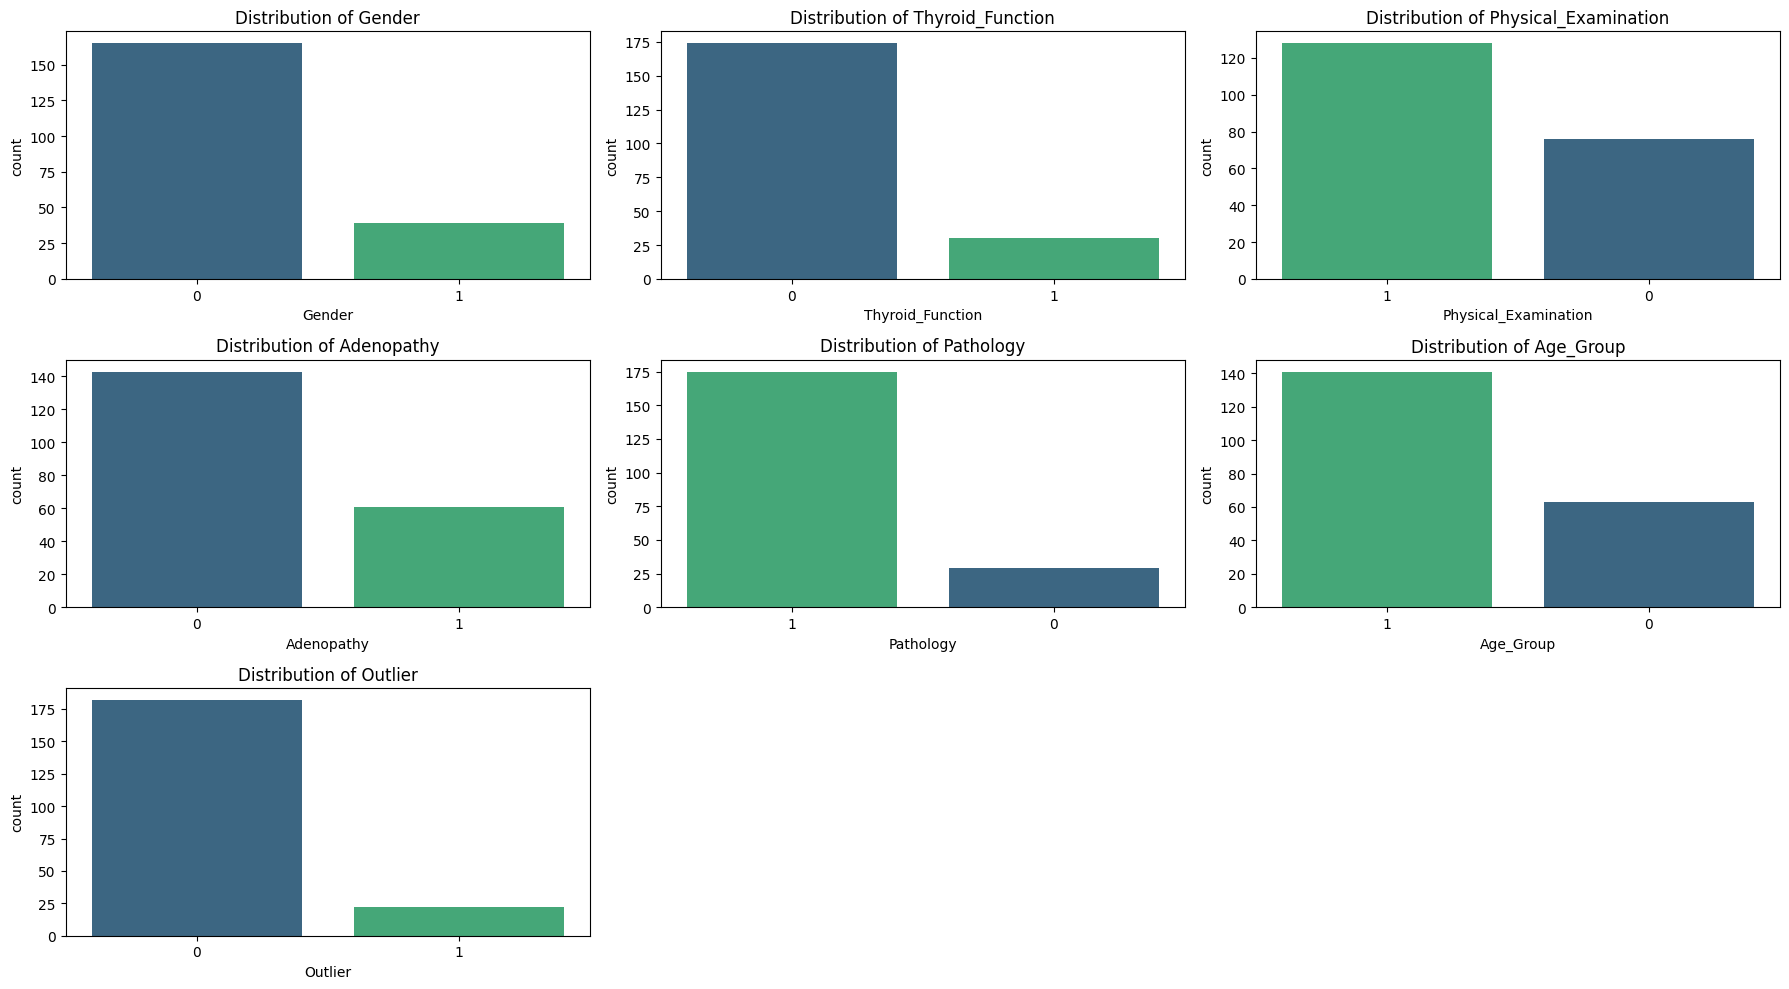

In [331]:
##################################
# Plotting count distributions for all categorical features 
# to assess class balance and frequency patterns across variables
##################################
plot_category_distribution(thyroid_cancer_train_EDA)


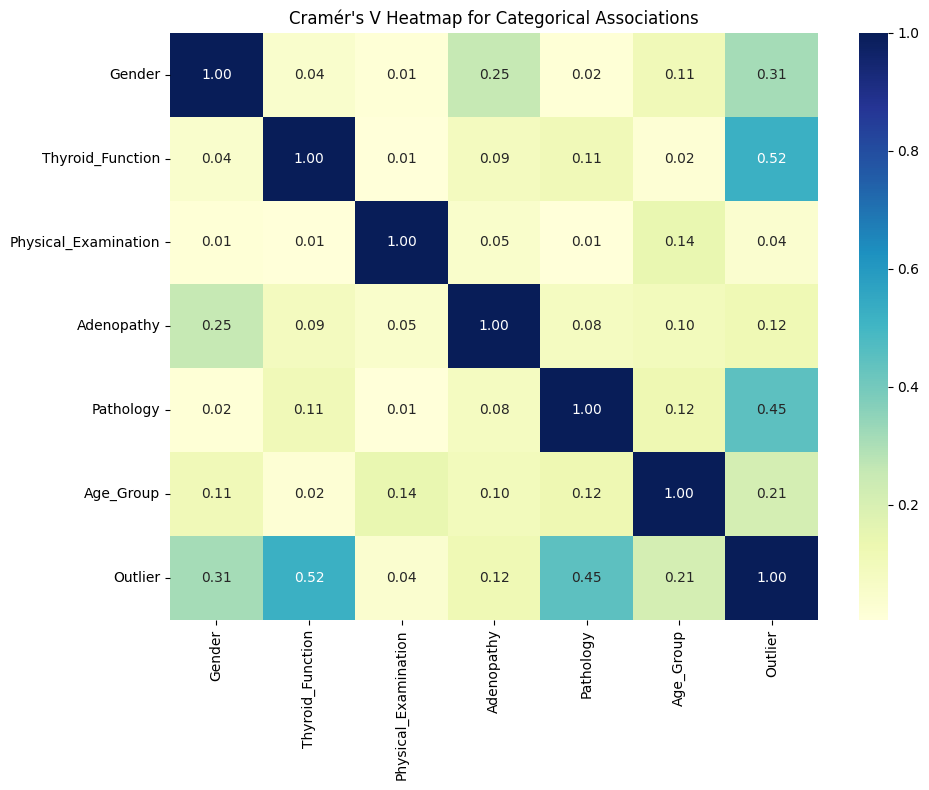

In [332]:
##################################
# Computing Cramér’s V to estimatte the association strength between categorical variables
# and displaying a correlation heatmap of label-encoded categorical features
# to identify relationships and potential redundancy
##################################
plot_cramers_v_heatmap(thyroid_cancer_train_EDA)


In [333]:
##################################
# Generating a t-SNE 2D scatter plot 
# for visualizing high-dimensional categorical structure
# colored by label/outlier status
##################################
plot_tsne(thyroid_cancer_train_EDA, label_col=label_col)


In [334]:
##################################
# Projecting high-dimensional encoded categorical data
# into two principal components for variance-driven visualization
# with label coloring applied
##################################
plot_pca(thyroid_cancer_train_EDA, label_col=label_col)


In [335]:
##################################
# Performing UMAP dimensionality reduction 
# to reveal clusters or outlier structure 
# in a low-dimensional space labeled by class
##################################
plot_umap(thyroid_cancer_train_EDA, label_col=label_col)


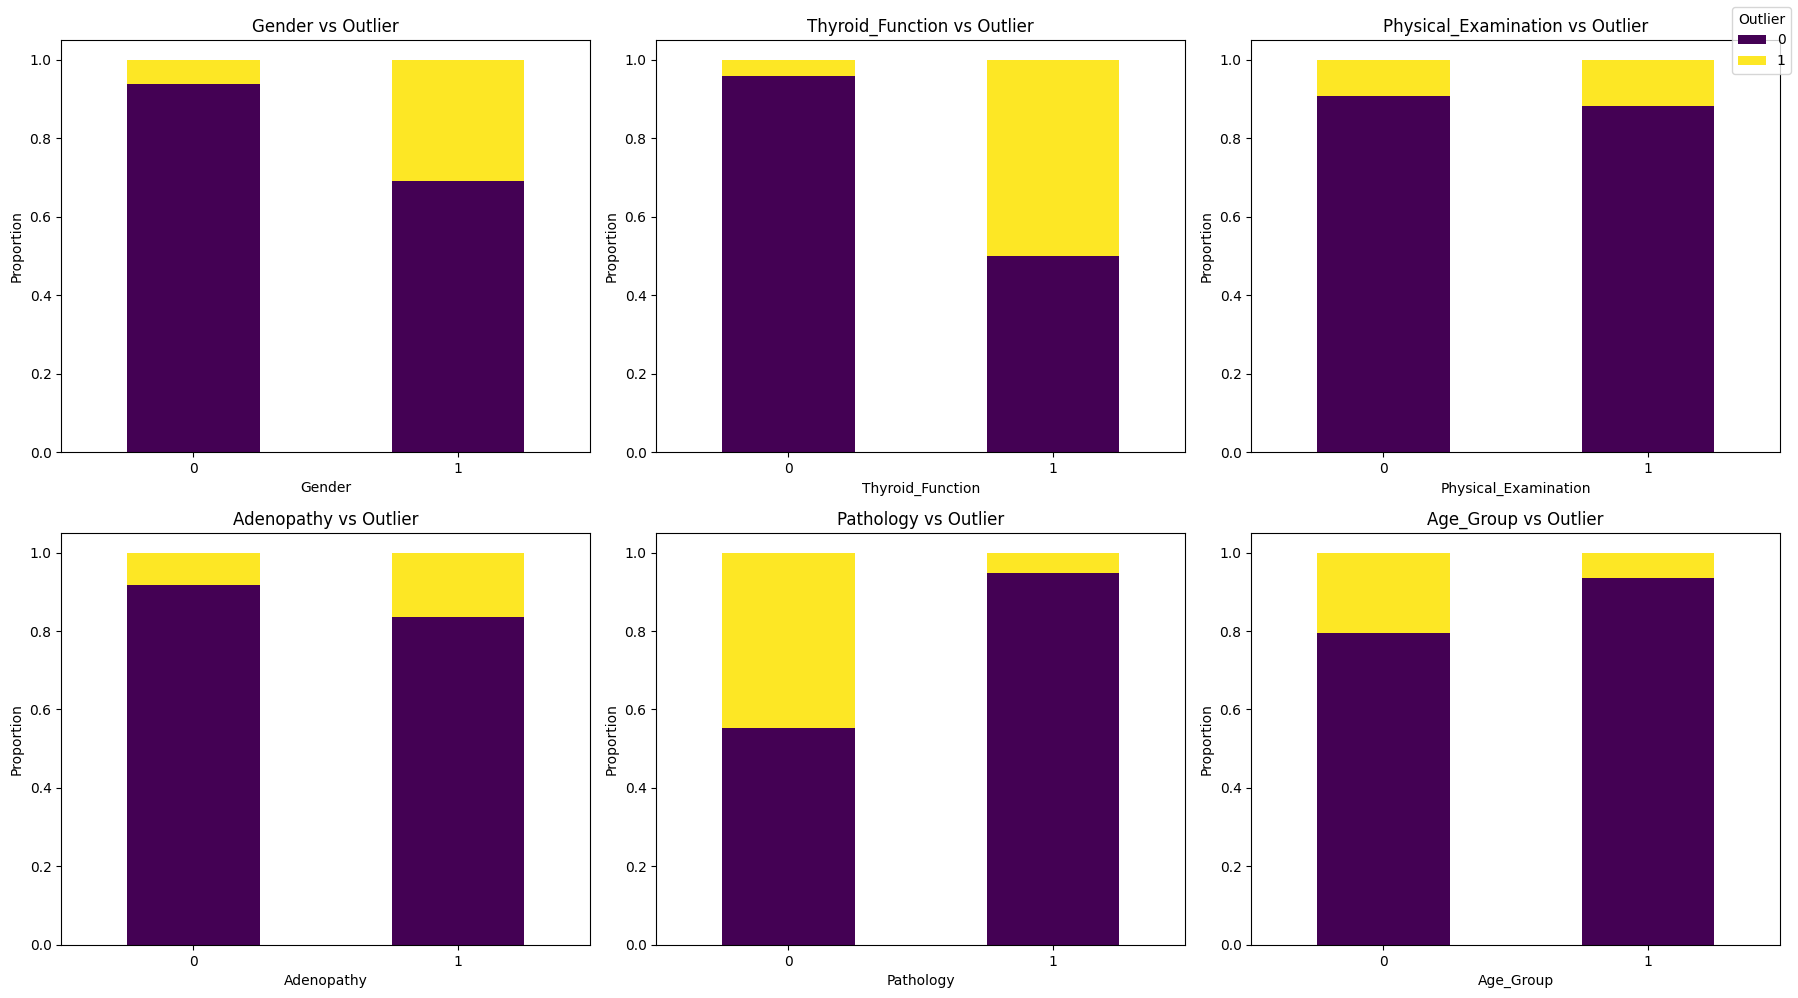

In [336]:
# Generating stacked bar plots showing the proportional distribution
# of each category across the label groups 
# to visualize feature-label association
stacked_bar_plot(thyroid_cancer_train_EDA, label_col=label_col)


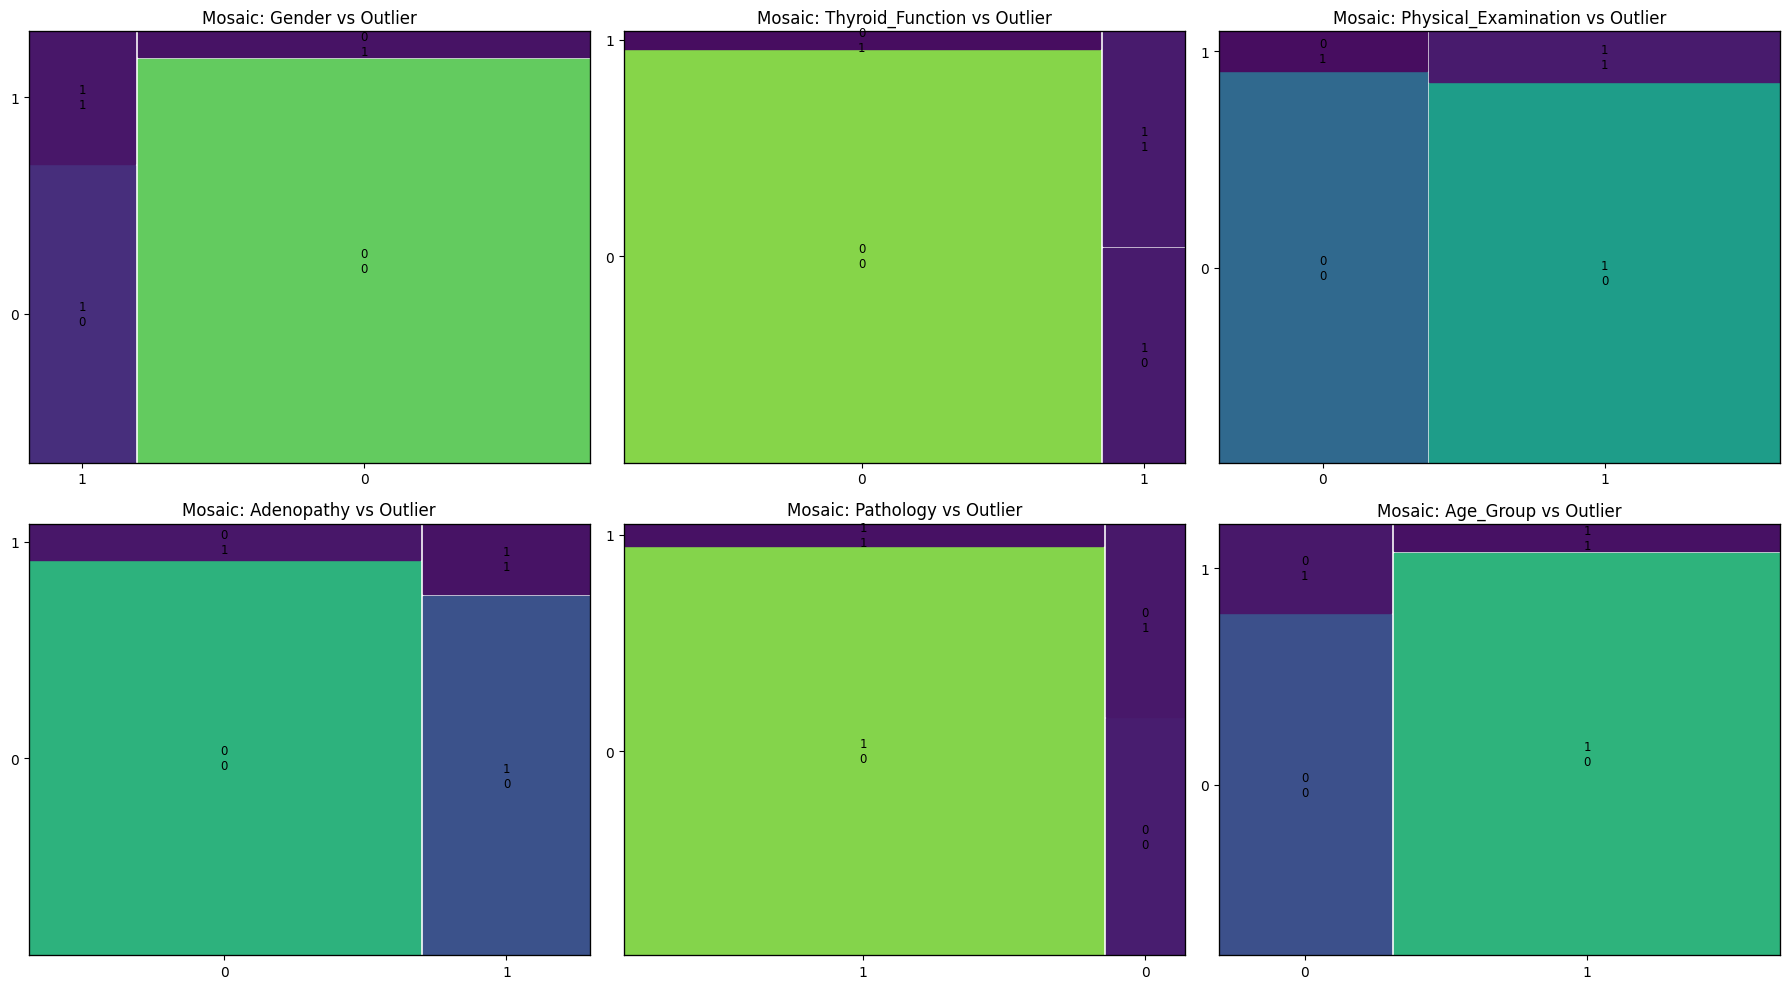

In [337]:
##################################
# Plotting a grid of mosaic charts to visualize 
# the joint distribution and interaction 
# between each categorical feature and the target label
##################################
mosaic_grid_plot(thyroid_cancer_train_EDA, label_col)


### 1.5.2 Hypothesis Testing <a class="anchor" id="1.5.2"></a>

1. The relationship between the categorical predictors to the <span style="color: #FF0000">Outlier</span> target variable was statistically evaluated using the following hypotheses:
    * **Null**: The categorical predictor is independent of the categorical target variable
    * **Alternative**: The categorical predictor is dependent of the categorical target variable
2. There is sufficient evidence to conclude of a statistically significant relationship between the categories of the categorical predictors and the Yes and No groups of the <span style="color: #FF0000">Outlier</span> target variable in 4 of 6 categorical predictors given their high chisquare statistic values with reported low p-values less than the significance level of 0.05.        
    * <span style="color: #FF0000">Thyroid_Function</span>: ChiSquare.Test.Statistic=51.542, ChiSquare.Test.PValue=0.000
    * <span style="color: #FF0000">Pathology</span>: ChiSquare.Test.Statistic=36.701, ChiSquare.Test.PValue=0.000
    * <span style="color: #FF0000">Gender</span>: ChiSquare.Test.Statistic=17.530, ChiSquare.Test.PValue=0.000
    * <span style="color: #FF0000">Age_Group</span>: ChiSquare.Test.Statistic=7.771, ChiSquare.Test.PValue=0.005

In [338]:
##################################
# Computing the chisquare
# statistic and p-values
# between the target variable
# and categorical predictor columns
##################################
thyroid_cancer_categorical_chisquare_target = {}
thyroid_cancer_categorical = thyroid_cancer_train.loc[:,(thyroid_cancer_train.columns != 'Outlier') | (thyroid_cancer_train.columns == 'Outlier')]
thyroid_cancer_categorical_columns = thyroid_cancer_train.loc[:,thyroid_cancer_train.columns != 'Outlier'].columns
for categorical_column in thyroid_cancer_categorical_columns:
    contingency_table = pd.crosstab(thyroid_cancer_categorical[categorical_column], 
                                    thyroid_cancer_categorical['Outlier'])
    thyroid_cancer_categorical_chisquare_target['Outlier_' + categorical_column] = chi2_contingency(
        contingency_table)[0:2]

In [339]:
##################################
# Formulating the pairwise chisquare summary
# between the target variable
# and categorical predictor columns
##################################
thyroid_cancer_categorical_summary = thyroid_cancer_categorical.from_dict(thyroid_cancer_categorical_chisquare_target, orient='index')
thyroid_cancer_categorical_summary.columns = ['ChiSquare.Test.Statistic', 'ChiSquare.Test.PValue']
display(thyroid_cancer_categorical_summary.sort_values(by=['ChiSquare.Test.PValue'], ascending=True).head(len(thyroid_cancer_categorical_columns)))

,ChiSquare.Test.Statistic,ChiSquare.Test.PValue
Outlier_Thyroid_Function,51.542520,7.006314e-13
Outlier_Pathology,36.700825,1.377211e-09
Outlier_Gender,17.530464,2.827409e-05
Outlier_Age_Group,7.771098,5.308876e-03
Outlier_Adenopathy,2.074736,1.497559e-01
Outlier_Physical_Examination,0.105606,7.452030e-01


## 1.6. Model Hyperparameter Tuning and Evaluation <a class="anchor" id="1.6"></a>

### 1.6.1 Model Evaluation Metrics Description <a class="anchor" id="1.6.1"></a>

### 1.6.2 Model Hyperparameter Tuning and Evaluation Function Development <a class="anchor" id="1.6.2"></a>

In [340]:
##################################
# Creating a function for performing
# hyperparameter tuning using Monte Carlo cross-validation 
# for categorical outlier detection with ground truth
##################################
def run_monte_carlo_cv_supervised_outlier_detection_model(model_class, param_grid, X, y, model_name="Model", n_splits=100, test_size=0.3):
    cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)
    param_combinations = list(ParameterGrid(param_grid))
    results = {str(params): [] for params in param_combinations}

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx].values, X.iloc[test_idx].values
        y_train, y_val = y.iloc[train_idx].values, y.iloc[test_idx].values

        for params in param_combinations:
            model = model_class(**params)
            model.fit(X_train)
            y_scores = model.decision_function(X_val)
            auc = roc_auc_score(y_val, y_scores)
            results[str(params)].append(auc)

    # Computing mean and std AUROC for each combination
    summary_data = [
        {"Params": k, "Mean AUROC": np.mean(v), "Std AUROC": np.std(v)}
        for k, v in results.items()
    ]
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by="Mean AUROC", ascending=False).reset_index(drop=True)

    # Showing the best hyperparameter combination
    best_row = summary_df.iloc[0]
    best_params = eval(best_row["Params"])
    print(f"Best {model_name} params: {best_row['Params']} with AUROC: {best_row['Mean AUROC']:.3f}")
    
    # Displaying top hyperparameter combinations
    print("\nTop Hyperparameter Combinations Ranked by Mean AUROC:")
    display(summary_df)

    return best_params, summary_df
    

In [341]:
##################################
# Creating a function for evaluating model metrics
# for categorical outlier detection with ground truth
##################################
def evaluate_supervised_outlier_detection_model(model, X, y_true, name, top_n=None):
    y_scores = model.decision_scores_ if hasattr(model, 'decision_scores_') else model.decision_function(X)
    
    roc_auc = roc_auc_score(y_true, y_scores)
    
    # Computing Precision at N (N = number of actual outliers)
    if top_n is None:
        top_n = y_true.sum()
    top_n_pred = np.argsort(y_scores)[-top_n:]
    y_pred_top_n = np.zeros_like(y_true)
    y_pred_top_n[top_n_pred] = 1
    precision_at_n = precision_score(y_true, y_pred_top_n)
    
    # Computing Threshold-based F1-score using a 70th percentile cutoff
    threshold = np.percentile(y_scores, 90)
    y_pred_f1 = (y_scores >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred_f1)

    print("-" * 40)
    print(f" {name}")
    print(f"  AUROC       : {roc_auc:.3f}")
    print(f"  Precision@N   : {precision_at_n:.3f}")
    print(f"  F1-score      : {f1:.3f}")
    print("-" * 40)

    return roc_auc, precision_at_n, f1
    

In [342]:
##################################
# Creating a function for evaluating model metrics
# for categorical outlier detection without ground truth
##################################
def score_entropy(scores):
    hist, _ = np.histogram(scores, bins=10, density=True)
    return entropy(hist + 1e-10)

def silhouette_on_scores(scores):
    scores_reshaped = np.array(scores).reshape(-1, 1)
    return silhouette_score(scores_reshaped, KMeans(n_clusters=2, n_init=10).fit_predict(scores_reshaped))

def score_variance(scores):
    return np.var(scores)

def evaluate_unsupervised_outlier_detection_model(scores, name):
    se = score_entropy(scores)
    ss = silhouette_on_scores(scores)
    sv = score_variance(scores)

    print("-" * 40)
    print(f" {name}")
    print(f"  Score Entropy     : {se:.3f}")
    print(f"  Score Silhouette  : {ss:.3f}")
    print(f"  Score Variance    : {sv:.3f}")
    print("-" * 40)

    return se, ss, sv

In [343]:
##################################
# Creating a function for performing
# hyperparameter tuning using Monte Carlo cross-validation 
# for categorical outlier detection without ground truth
##################################
def run_monte_carlo_cv_unsupervised_outlier_detection_model(model_class, param_grid, X, model_name="Model", n_splits=100, test_size=0.3):
    cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)
    param_combinations = list(ParameterGrid(param_grid))
    results = {str(params): [] for params in param_combinations}

    for train_idx, test_idx in cv.split(X, np.zeros(len(X))):  # using dummy y for stratification
        X_train, X_val = X.iloc[train_idx].values, X.iloc[test_idx].values

        for params in param_combinations:
            model = model_class(**params)
            model.fit(X_train)
            scores = model.decision_function(X_val)
            try:
                sil_score = silhouette_on_scores(scores)
                results[str(params)].append(sil_score)
            except:
                continue  # Skipping if silhouette fails (e.g., degenerate clusters)

    # Computing mean and std Silhouette Scores for each combination
    summary_data = [
        {"Params": k, "Mean Silhouette": np.mean(v), "Std Silhouette": np.std(v)}
        for k, v in results.items() if v
    ]
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by="Mean Silhouette", ascending=False).reset_index(drop=True)

    # Showing the best hyperparameter combination
    best_row = summary_df.iloc[0]
    best_params = eval(best_row["Params"])
    print(f"Best {model_name} params: {best_row['Params']} with Silhouette: {best_row['Mean Silhouette']:.3f}")
    
    # Displaying top hyperparameter combinations
    print("\nTop Hyperparameter Combinations Ranked by Mean Silhouette Score:")
    display(summary_df)

    return best_params, summary_df

In [344]:
##################################
# Creating a function for visualizing outlier scores
# for categorical outlier detection without ground truth
# Using PCA (Principal Component Analysis)
##################################
def pca_visualize_unsupervised_outlier_detection_model(X_train, X_val, train_scores, val_scores, method_name):
    # Implemeting PCA from the training data
    pca = PCA(n_components=2)
    X_train_2d = pca.fit_transform(X_train)
    X_val_2d = pca.transform(X_val)

    # Plotting PCA of the validation data based on the computations made from training data
    plt.figure(figsize=(7, 5))
    plt.title(f"{method_name} : PCA on Outlier Scores")
    plt.scatter(X_val_2d[:, 0], X_val_2d[:, 1], c=-val_scores, cmap='coolwarm', s=30)
    plt.colorbar(label="Outlier Score")
    plt.show()


In [345]:
##################################
# Creating a function for visualizing outlier scores
# for categorical outlier detection without ground truth
# using UMAP (Uniform Manifold Approximation and Projection)
##################################
def umap_visualize_unsupervised_outlier_detection_model(X_train, X_val, train_scores, val_scores, method_name):
    # Implemeting UMAP from the training data
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_train_2d = reducer.fit_transform(X_train)
    X_val_2d = reducer.transform(X_val)

    # Plotting UMAP of the validation data based on the computations made from training data
    plt.figure(figsize=(7, 5))
    plt.title(f"{method_name} : UMAP on Outlier Scores")
    plt.scatter(X_val_2d[:, 0], X_val_2d[:, 1], c=-val_scores, cmap='coolwarm', s=30)
    plt.colorbar(label="Outlier Score")
    plt.show()

## 1.7. Model Development With Synthetic Ground Truth Labels <a class="anchor" id="1.7"></a>

### 1.7.1 Isolation Forest <a class="anchor" id="1.7.1"></a>

[Isolation Forest](https://link.springer.com/book/10.1007/978-3-319-47578-3), in the supervised context, uses known labels (e.g., inliers versus outliers) to train and evaluate how effectively the model can separate the two classes. While iForest is inherently unsupervised, its outputs can be evaluated using ground truth labels through metrics like ROC AUC, Precision@N, and F1-score. The algorithm works by randomly selecting features and split values to build an ensemble of isolation trees. Each tree recursively partitions the data until each instance is isolated. The core intuition is that anomalies, being rare and different, are more likely to be isolated in fewer splits, resulting in shorter path lengths. In categorical data, where features are non-numeric, encoding schemes such as one-hot or ordinal encoding are first applied. Once fitted, the model generates an "anomaly score" for each instance based on its average path length across all trees. In the supervised setting, the score distribution can be validated against true labels to assess performance. This allows the practitioner to tune hyperparameters like n_estimators, max_samples, and max_features for optimal separation. Despite its unsupervised design, iForest's scoring mechanism lends itself well to supervised evaluation when ground truth is available. Its effectiveness stems from its ability to model structural irregularities in the data, which are often characteristic of categorical anomalies.

1. The [isolation forest](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/iforest.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.iforest</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">n_estimators</span> = number of isolation trees to build in the ensemble, where more trees generally improve stability but increase computation time made to vary between 100 and 200
    * <span style="color: #FF0000">max_samples</span> = proportion of samples to draw from the training data to build each tree, controlling the sub-sample size for isolation made to vary between 0.5, 0.8 and 1.0
    * <span style="color: #FF0000">max_features</span> = proportion of features to consider when splitting a node, which helps inject randomness and reduce overfitting made to vary between 0.5, 0.8 and 1.0
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
    * <span style="color: #FF0000">random_state</span> = seed for the random number generator, ensuring reproducibility of results across runs by controlling random sampling and feature selection fixed at 42
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">n_estimators</span> = 200
    * <span style="color: #FF0000">max_samples</span> = 1.0
    * <span style="color: #FF0000">max_features</span> = 0.8
5. The apparent model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.992
    * **Precision@N** = 0.900
    * **F1-score** = 0.818
6. The independent validation model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.982
    * **Precision@N** = 1.000
    * **F1-score** = 0.800
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [346]:
##################################
# Formulating a hyperparameter tuning grid
# based on Isolation Forest 
##################################
iforest_grid = {
    "n_estimators": [100, 200],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0],
    "contamination": [0.10],
    "random_state": [42]
}


In [347]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Isolation Forest 
##################################
best_supervised_model_iforest_params, supervised_model_iforest_results_df = run_monte_carlo_cv_supervised_outlier_detection_model(IForest, iforest_grid, X_train, y_train, model_name="Isolation Forest")
supervised_model_iforest = IForest(**best_supervised_model_iforest_params)


Best Isolation Forest params: {'contamination': 0.1, 'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 200, 'random_state': 42} with AUROC: 0.986

Top Hyperparameter Combinations Ranked by Mean AUROC:


,Params,Mean AUROC,Std AUROC
0,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.985740,0.011769
1,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.985195,0.012224
2,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.985065,0.013061
3,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.984701,0.013386
4,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.984545,0.012588
5,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.983792,0.012693
6,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.983610,0.014268
7,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.983273,0.014200
8,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.983169,0.014370
9,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.982312,0.013684


In [348]:
##################################
# Conducting apparent validation
# of the optimal Isolation Forest 
# using the train data
##################################
supervised_model_iforest.fit(X_train)
supervised_model_iforest.decision_scores_ = supervised_model_iforest.decision_function(X_train.values)
supervised_iforest_auroc_training, supervised_iforest_precision_training, supervised_iforest_f1_training = evaluate_supervised_outlier_detection_model(supervised_model_iforest, X_train, y_train, "Supervised Outlier Detection Using Isolation Forest (Training Performance)", top_n=int(0.10 * len(X_train)))


----------------------------------------
 Supervised Outlier Detection Using Isolation Forest (Training Performance)
  AUROC       : 0.992
  Precision@N   : 0.900
  F1-score      : 0.818
----------------------------------------


In [349]:
##################################
# Saving the optimal Isolation Forest model
# developed from the training data
##################################
joblib.dump(
    supervised_model_iforest, 
    os.path.join("..", MODELS_PATH, "supervised_model_iforest_optimal.pkl")
)

['..\\models\\supervised_model_iforest_optimal.pkl']

In [350]:
##################################
# Conducting external validation
# of the optimal Isolation Forest 
# using the validation data
##################################
supervised_model_iforest.fit(X_train)
supervised_model_iforest.decision_scores_ = supervised_model_iforest.decision_function(X_validation.values)
supervised_iforest_auroc_validation, supervised_iforest_precision_validation, supervised_iforest_f1_validation = evaluate_supervised_outlier_detection_model(supervised_model_iforest, X_validation, y_validation, "Supervised Outlier Detection Using Isolation Forest (Validation Performance)", top_n=int(0.10 * len(X_validation)))


----------------------------------------
 Supervised Outlier Detection Using Isolation Forest (Validation Performance)
  AUROC       : 0.982
  Precision@N   : 1.000
  F1-score      : 0.800
----------------------------------------


In [351]:
##################################
# Consolidating all the performance measures
# for the Isolation Forest model
# with synthetic ground truth labels
# for the train and validation data
##################################
supervised_model_iforest_metric_summary = pd.DataFrame()
supervised_model_iforest_metric_summary['metric'] = ["AUROC", "Precision@N", "F1Score"] * 2
supervised_model_iforest_metric_summary['metric_value'] = [supervised_iforest_auroc_training, supervised_iforest_precision_training, supervised_iforest_f1_training, supervised_iforest_auroc_validation, supervised_iforest_precision_validation, supervised_iforest_f1_validation]
supervised_model_iforest_metric_summary['model'] = ["Isolation Forest"] * 6
supervised_model_iforest_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(supervised_model_iforest_metric_summary)


,metric,metric_value,model,set
0,AUROC,0.991508,Isolation Forest,Train
1,Precision@N,0.900000,Isolation Forest,Train
2,F1Score,0.818182,Isolation Forest,Train
3,AUROC,0.981567,Isolation Forest,Validation
4,Precision@N,1.000000,Isolation Forest,Validation
5,F1Score,0.800000,Isolation Forest,Validation


### 1.7.2 Local Outlier Factor <a class="anchor" id="1.7.2"></a>

[Clustering-Based Local Outlier Factor](https://link.springer.com/book/10.1007/978-3-319-47578-3), in the supervised context, leverages ground truth labels to evaluate how well the clustering-based strategy distinguishes known anomalies. CBLOF first applies clustering (e.g., k-means) to assign each data point to a cluster, classifying them as either "large" or "small" clusters based on size thresholds. Points in small clusters or far from the centroid of their assigned cluster are considered more likely to be anomalies. After computing a CBLOF score for each instance, supervised metrics such as ROC AUC and Precision@N are calculated by comparing scores against the actual labels. This helps in selecting optimal clustering configurations (e.g., number of clusters) and tuning scoring thresholds. In categorical data, encoding is necessary to make the distance metrics meaningful. Supervised evaluation further enables comparative analysis across models and hyperparameters. The supervised application of CBLOF transforms it into a semi-supervised approach, using clustering for detection but ground truth for validation. This synergy helps highlight model strengths and blind spots. Particularly, it is effective when anomalies form isolated micro-clusters or are dispersed far from dense normal clusters. Supervised CBLOF gives interpretable and geometry-driven insights into outlier structure.

1. The [clustering-based local outlier factor](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/cblof.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.cblof</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">alpha</span> = threshold factor that determines whether a cluster is considered large or small based on the ratio of its size to the largest cluster, influencing the distinction between inliers and potential outliers made to vary between 0.90 and 0.80
    * <span style="color: #FF0000">n_clusters</span> = number of clusters to form during the internal KMeans clustering step, which serves as the foundation for assigning CBLOF scores made to vary between 8, 12 and 16
    * <span style="color: #FF0000">beta</span> = scaling factor used in the CBLOF score computation to penalize the distance of points in small clusters more heavily than those in large clusters made to vary between 5, 10 and 15
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
    * <span style="color: #FF0000">random_state</span> = seed for the random number generator, ensuring reproducibility of results across runs by controlling random sampling and feature selection fixed at 42
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">alpha</span> = 0.90
    * <span style="color: #FF0000">n_clusters</span> = 8
    * <span style="color: #FF0000">beta</span> = 5
5. The apparent model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.985
    * **Precision@N** = 0.850
    * **F1-score** = 0.773
6. The independent validation model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.965
    * **Precision@N** = 0.667
    * **F1-score** = 0.571
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.


In [352]:
##################################
# Formulating a hyperparameter tuning grid
# based on Local Outlier Factor
##################################
cblof_grid = {
    "alpha": [0.9, 0.8],
    "n_clusters": [8, 12, 16],
    "beta": [5, 10, 15],
    "contamination": [0.10],
    "random_state": [42]
}


In [353]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Local Outlier Factor 
##################################
best_supervised_model_cblof_params, supervised_model_cblof_results_df = run_monte_carlo_cv_supervised_outlier_detection_model(CBLOF, cblof_grid, X_train, y_train, model_name="CBLOF")
supervised_model_cblof = CBLOF(**best_supervised_model_cblof_params)


Best CBLOF params: {'alpha': 0.9, 'beta': 5, 'contamination': 0.1, 'n_clusters': 8, 'random_state': 42} with AUROC: 0.971

Top Hyperparameter Combinations Ranked by Mean AUROC:


,Params,Mean AUROC,Std AUROC
0,"{'alpha': 0.9, 'beta': 5, 'contamination': 0.1...",0.971143,0.025175
1,"{'alpha': 0.9, 'beta': 10, 'contamination': 0....",0.971143,0.025175
2,"{'alpha': 0.9, 'beta': 15, 'contamination': 0....",0.971143,0.025175
3,"{'alpha': 0.9, 'beta': 15, 'contamination': 0....",0.966662,0.028600
4,"{'alpha': 0.9, 'beta': 10, 'contamination': 0....",0.966662,0.028600
5,"{'alpha': 0.9, 'beta': 5, 'contamination': 0.1...",0.966260,0.028503
6,"{'alpha': 0.8, 'beta': 5, 'contamination': 0.1...",0.963104,0.030046
7,"{'alpha': 0.8, 'beta': 10, 'contamination': 0....",0.963104,0.030046
8,"{'alpha': 0.8, 'beta': 15, 'contamination': 0....",0.963104,0.030046
9,"{'alpha': 0.9, 'beta': 5, 'contamination': 0.1...",0.962805,0.028618


In [354]:
##################################
# Conducting apparent validation
# of the optimal Local Outlier Factor 
# using the train data
##################################
supervised_model_cblof.fit(X_train)
supervised_model_cblof.decision_scores_ = supervised_model_cblof.decision_function(X_train.values)
supervised_cblof_auroc_training, supervised_cblof_precision_training, supervised_cblof_f1_training = evaluate_supervised_outlier_detection_model(supervised_model_cblof, X_train, y_train, "Supervised Outlier Detection Using Local Outlier Factor (Training Performance)", top_n=int(0.10 * len(X_train)))


----------------------------------------
 Supervised Outlier Detection Using Local Outlier Factor (Training Performance)
  AUROC       : 0.985
  Precision@N   : 0.850
  F1-score      : 0.773
----------------------------------------


In [355]:
##################################
# Saving the optimal Local Outlier Factor model
# developed from the training data
##################################
joblib.dump(
    supervised_model_cblof, 
    os.path.join("..", MODELS_PATH, "supervised_model_cblof_optimal.pkl")
)

['..\\models\\supervised_model_cblof_optimal.pkl']

In [356]:
##################################
# Conducting external validation
# of the optimal Local Outlier Factor 
# using the validation data
##################################
supervised_model_cblof.fit(X_train)
supervised_model_cblof.decision_scores_ = supervised_model_cblof.decision_function(X_validation.values)
supervised_cblof_auroc_validation, supervised_cblof_precision_validation, supervised_cblof_f1_validation = evaluate_supervised_outlier_detection_model(supervised_model_cblof, X_validation, y_validation, "Supervised Outlier Detection Using Local Outlier Factor (Validation Performance)", top_n=int(0.10 * len(X_validation)))


----------------------------------------
 Supervised Outlier Detection Using Local Outlier Factor (Validation Performance)
  AUROC       : 0.965
  Precision@N   : 0.667
  F1-score      : 0.571
----------------------------------------


In [357]:
##################################
# Consolidating all the performance measures
# for the Local Outlier Factor model
# with synthetic ground truth labels
# for the train and validation data
##################################
supervised_model_cblof_metric_summary = pd.DataFrame()
supervised_model_cblof_metric_summary['metric'] = ["AUROC", "Precision@N", "F1Score"] * 2
supervised_model_cblof_metric_summary['metric_value'] = [supervised_cblof_auroc_training, supervised_cblof_precision_training, supervised_cblof_f1_training, supervised_cblof_auroc_validation, supervised_cblof_precision_validation, supervised_cblof_f1_validation]
supervised_model_cblof_metric_summary['model'] = ["Clustering-Based Local Outlier Factor"] * 6
supervised_model_cblof_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(supervised_model_cblof_metric_summary)


,metric,metric_value,model,set
0,AUROC,0.985265,Clustering-Based Local Outlier Factor,Train
1,Precision@N,0.850000,Clustering-Based Local Outlier Factor,Train
2,F1Score,0.772727,Clustering-Based Local Outlier Factor,Train
3,AUROC,0.965438,Clustering-Based Local Outlier Factor,Validation
4,Precision@N,0.666667,Clustering-Based Local Outlier Factor,Validation
5,F1Score,0.571429,Clustering-Based Local Outlier Factor,Validation


### 1.7.3 K-Nearest Neighbors Outlier Score <a class="anchor" id="1.7.3"></a>

[K-Nearest Neighbor Outlier Score](https://link.springer.com/book/10.1007/978-3-319-47578-3), in supervised outlier detection, each sample’s outlier score is computed as the average or maximum distance to its k nearest neighbors. The key idea is that normal data points are close to their neighbors, while anomalies are isolated. For categorical data, a distance metric like Hamming distance is commonly used after appropriate encoding. In supervised analysis, the computed outlier scores are validated against true labels using ROC AUC, Precision@N, and F1-score. Hyperparameters like the number of neighbors (k) and the distance metric can be tuned to maximize performance. The scoring function produces a continuum of values that can be thresholded or ranked to evaluate prediction quality. The advantage of supervised KNN is the ability to interpret and optimize its hyperparameters using known outcomes. When categorical anomalies exhibit rare or unique attribute combinations, they naturally appear further away from the denser neighborhoods of normal instances. This property makes KNN particularly effective in detecting localized anomalies. Supervised metrics reinforce confidence in model reliability and guide parameter selection.

1. The [k-nearest neighbor outlier score](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/knn.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.knn</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">method</span> = strategy for calculating outlier scores indicating the distance to the nearest neighbors, affecting how deviation from the neighborhood is quantified made to vary between largest and mean
    * <span style="color: #FF0000">n_neighbors</span> = number of nearest neighbors used to compute distances for determining the outlier score, which controls the local context of anomaly detection made to vary between 5, 10 and 15
    * <span style="color: #FF0000">metric</span> = determines the distance metric used to compute distances between instances, directly impacting neighborhood relationships and score calculations made to vary between minkowski, euclidean and manhattan
3. The model contains 1 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">method</span> = mean
    * <span style="color: #FF0000">n_neighbors</span> = 10
    * <span style="color: #FF0000">metric</span> = minkowski
5. The apparent model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.994
    * **Precision@N** = 0.950
    * **F1-score** = 0.830
6. The independent validation model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.994
    * **Precision@N** = 1.000
    * **F1-score** = 0.933
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [358]:
##################################
# Formulating a hyperparameter tuning grid
# based on K-Nearest Neighbors Outlier Score
##################################
knn_grid = {
    "method": ["largest", "mean"],
    "n_neighbors": [5, 10, 15],
    "metric": ["minkowski", "euclidean", "manhattan"],
    "contamination": [0.10]
}


In [359]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on K-Nearest Neighbors Outlier Score
##################################
best_supervised_model_knn_params, supervised_model_knn_results_df = run_monte_carlo_cv_supervised_outlier_detection_model(KNN, knn_grid, X_train, y_train, model_name="KNN")
supervised_model_knn = KNN(**best_supervised_model_knn_params)


Best KNN params: {'contamination': 0.1, 'method': 'mean', 'metric': 'minkowski', 'n_neighbors': 10} with AUROC: 0.994

Top Hyperparameter Combinations Ranked by Mean AUROC:


,Params,Mean AUROC,Std AUROC
0,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.994130,0.006216
1,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.994130,0.006216
2,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.994117,0.006213
3,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.992182,0.008964
4,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.992182,0.008964
5,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.988662,0.011338
6,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.987506,0.011271
7,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.986870,0.011794
8,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.986870,0.011794
9,"{'contamination': 0.1, 'method': 'largest', 'm...",0.921584,0.041228


In [360]:
##################################
# Conducting apparent validation
# of the optimal K-Nearest Neighbors Outlier Score 
# using the train data
##################################
supervised_model_knn.fit(X_train)
supervised_model_knn.decision_scores_ = supervised_model_knn.decision_function(X_train.values)
supervised_knn_auroc_training, supervised_knn_precision_training, supervised_knn_f1_training = evaluate_supervised_outlier_detection_model(supervised_model_knn, X_train, y_train, "Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)", top_n=int(0.10 * len(X_train)))


----------------------------------------
 Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)
  AUROC       : 0.994
  Precision@N   : 0.950
  F1-score      : 0.830
----------------------------------------


In [361]:
##################################
# Saving the optimal K-Nearest Neighbors Outlier Score model
# developed from the training data
##################################
joblib.dump(
    supervised_model_knn, 
    os.path.join("..", MODELS_PATH, "supervised_model_knn_optimal.pkl")
)

['..\\models\\supervised_model_knn_optimal.pkl']

In [362]:
##################################
# Conducting external validation
# of the optimal K-Nearest Neighbors Outlier Score
# using the validation data
##################################
supervised_model_knn.fit(X_train)
supervised_model_knn.decision_scores_ = supervised_model_knn.decision_function(X_validation.values)
supervised_knn_auroc_validation, supervised_knn_precision_validation, supervised_knn_f1_validation = evaluate_supervised_outlier_detection_model(supervised_model_knn, X_validation, y_validation, "Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)", top_n=int(0.10 * len(X_validation)))


----------------------------------------
 Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)
  AUROC       : 0.994
  Precision@N   : 1.000
  F1-score      : 0.933
----------------------------------------


In [363]:
##################################
# Consolidating all the performance measures
# for the K-Nearest Neighbors Outlier Score model
# with synthetic ground truth labels
# for the train and validation data
##################################
supervised_model_knn_metric_summary = pd.DataFrame()
supervised_model_knn_metric_summary['metric'] = ["AUROC", "Precision@N", "F1Score"] * 2
supervised_model_knn_metric_summary['metric_value'] = [supervised_knn_auroc_training, supervised_knn_precision_training, supervised_knn_f1_training, supervised_knn_auroc_validation, supervised_knn_precision_validation, supervised_knn_f1_validation]
supervised_model_knn_metric_summary['model'] = ["K-Nearest Neighbors Outlier Score"] * 6
supervised_model_knn_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(supervised_model_knn_metric_summary)


,metric,metric_value,model,set
0,AUROC,0.994131,K-Nearest Neighbors Outlier Score,Train
1,Precision@N,0.950000,K-Nearest Neighbors Outlier Score,Train
2,F1Score,0.830189,K-Nearest Neighbors Outlier Score,Train
3,AUROC,0.994240,K-Nearest Neighbors Outlier Score,Validation
4,Precision@N,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,F1Score,0.933333,K-Nearest Neighbors Outlier Score,Validation


### 1.7.4 Histogram-Based Outlier Score <a class="anchor" id="1.7.4"></a>

[Histogram-Based Outlier Score](https://link.springer.com/book/10.1007/978-3-319-47578-3), in supervised use, evaluates anomaly scores based on univariate feature distributions and validates them against known labels. Each feature is modeled using histograms, and the frequency (or density) of each feature value determines how “normal” it is. Lower frequencies imply higher anomaly scores. The overall anomaly score for a sample is typically an aggregation (e.g., sum or product) of the individual feature scores. For categorical data, frequencies of category occurrences per feature are directly usable. Supervised evaluation uses ROC AUC and similar metrics to determine how well these histogram-derived scores align with actual outlier labels. This allows for fine-tuning aspects like bin size, scoring aggregation strategy, and handling of rare categories. HBOS excels in cases where anomalies differ significantly on one or more marginal feature distributions. Supervised validation supports the development of feature selection and transformation strategies to enhance performance. The model's transparency and simplicity make it attractive for high-speed anomaly scoring.

1. The [histogram-based outlier score](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/hbos.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.hbos</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">alpha</span> = regularization parameter that adjusts the influence of sparsity in feature histograms to avoid overfitting to noise or rare bins made to vary between 0.10 and 0.20
    * <span style="color: #FF0000">n_bins</span> = number of bins used to discretize continuous features into histograms, directly affecting the granularity of the outlier detection made to vary between 5, 10 and 15
    * <span style="color: #FF0000">tol</span> = tolerance threshold for discarding features that have too many identical values, helping to avoid distortion in histogram-based density estimation made to vary between 0.25, 0.50 and 0.75
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">alpha</span> = 0.10
    * <span style="color: #FF0000">n_bins</span> = 10
    * <span style="color: #FF0000">tol</span> = 0.50
5. The apparent model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.981
    * **Precision@N** = 0.850
    * **F1-score** = 0.864
6. The independent validation model performance of the optimal model is summarized as follows:
    * **AUROC** = 0.959
    * **Precision@N** = 0.667
    * **F1-score** = 0.714
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [364]:
##################################
# Formulating a hyperparameter tuning grid
# based on Histogram-Based Outlier Score
##################################
hbos_grid = {
    "alpha": [0.1, 0.2],
    "n_bins": [5, 10, 15],
    "tol": [0.25, 0.50, 0.75],
    "contamination": [0.10]
}


In [365]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Histogram-Based Outlier Score
##################################
best_supervised_model_hbos_params, supervised_model_hbos_results_df = run_monte_carlo_cv_supervised_outlier_detection_model(HBOS, hbos_grid, X_train, y_train, model_name="HBOS")
supervised_model_hbos = HBOS(**best_supervised_model_hbos_params)


Best HBOS params: {'alpha': 0.1, 'contamination': 0.1, 'n_bins': 10, 'tol': 0.5} with AUROC: 0.978

Top Hyperparameter Combinations Ranked by Mean AUROC:


,Params,Mean AUROC,Std AUROC
0,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978403,0.015647
1,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978403,0.015647
2,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978403,0.015647
3,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978338,0.015646
4,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978338,0.015646
5,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.978338,0.015646
6,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.978299,0.015657
7,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.978299,0.015657
8,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.978299,0.015657
9,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.978221,0.015617


In [366]:
##################################
# Conducting apparent validation
# of the optimal Histogram-Based Outlier Score
# using the train data
##################################
supervised_model_hbos.fit(X_train)
supervised_model_hbos.decision_scores_ = supervised_model_hbos.decision_function(X_train.values)
supervised_hbos_auroc_training, supervised_hbos_precision_training, supervised_hbos_f1_training = evaluate_supervised_outlier_detection_model(supervised_model_hbos, X_train, y_train, "Supervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)", top_n=int(0.10 * len(X_train)))


----------------------------------------
 Supervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)
  AUROC       : 0.981
  Precision@N   : 0.850
  F1-score      : 0.864
----------------------------------------


In [367]:
##################################
# Saving the optimal Histogram-Based Outlier Score model
# developed from the training data
##################################
joblib.dump(
    supervised_model_hbos, 
    os.path.join("..", MODELS_PATH, "supervised_model_hbos_optimal.pkl")
)

['..\\models\\supervised_model_hbos_optimal.pkl']

In [368]:
##################################
# Conducting external validation
# of the optimal Histogram-Based Outlier Score
# using the validation data
##################################
supervised_model_hbos.fit(X_train)
supervised_model_hbos.decision_scores_ = supervised_model_hbos.decision_function(X_validation.values)
supervised_hbos_auroc_validation, supervised_hbos_precision_validation, supervised_hbos_f1_validation = evaluate_supervised_outlier_detection_model(supervised_model_hbos, X_validation, y_validation, "Supervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)", top_n=int(0.10 * len(X_validation)))


----------------------------------------
 Supervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)
  AUROC       : 0.959
  Precision@N   : 0.667
  F1-score      : 0.714
----------------------------------------


In [369]:
##################################
# Consolidating all the performance measures
# for the Histogram-Based Outlier Score model
# with synthetic ground truth labels
# for the train and validation data
##################################
supervised_model_hbos_metric_summary = pd.DataFrame()
supervised_model_hbos_metric_summary['metric'] = ["AUROC", "Precision@N", "F1Score"] * 2
supervised_model_hbos_metric_summary['metric_value'] = [supervised_hbos_auroc_training, supervised_hbos_precision_training, supervised_hbos_f1_training, supervised_hbos_auroc_validation, supervised_hbos_precision_validation, supervised_hbos_f1_validation]
supervised_model_hbos_metric_summary['model'] = ["Histogram-Based Outlier Score"] * 6
supervised_model_hbos_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(supervised_model_hbos_metric_summary)


,metric,metric_value,model,set
0,AUROC,0.981019,Histogram-Based Outlier Score,Train
1,Precision@N,0.850000,Histogram-Based Outlier Score,Train
2,F1Score,0.863636,Histogram-Based Outlier Score,Train
3,AUROC,0.958525,Histogram-Based Outlier Score,Validation
4,Precision@N,0.666667,Histogram-Based Outlier Score,Validation
5,F1Score,0.714286,Histogram-Based Outlier Score,Validation


## 1.8. Model Development Without Ground Truth Labels <a class="anchor" id="1.8"></a>

### 1.8.1 Isolation Forest <a class="anchor" id="1.8.1"></a>

[Isolation Forest](https://link.springer.com/book/10.1007/978-3-319-47578-3), in the supervised context, is applied without access to ground truth labels, relying entirely on the structure of the data to infer anomalies. After encoding the categorical variables, iForest randomly selects feature-split pairs to grow trees that isolate samples. Anomalous samples are isolated faster, leading to shorter average path lengths, which are then transformed into outlier scores. Since labels are unavailable, evaluation relies on unsupervised metrics like Silhouette Score on the score distribution, entropy of score histograms, and variance of scores. These metrics assess how well the outlier scores differentiate samples. For instance, high Silhouette Scores indicate a bimodal separation of normal vs. anomalous instances in the score space. Entropy reflects how uniformly the scores are distributed, with lower entropy suggesting clearer separation. This methodology allows iForest to serve as a powerful anomaly detector in categorical domains, even without explicit label supervision. It is particularly effective when anomalies break common attribute combinations or co-occurrence patterns. The model’s robustness comes from its randomness and ensemble structure, making it less sensitive to overfitting and noise.

1. The [isolation forest](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/iforest.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.iforest</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">n_estimators</span> = number of isolation trees to build in the ensemble, where more trees generally improve stability but increase computation time made to vary between 100 and 200
    * <span style="color: #FF0000">max_samples</span> = proportion of samples to draw from the training data to build each tree, controlling the sub-sample size for isolation made to vary between 0.5, 0.8 and 1.0
    * <span style="color: #FF0000">max_features</span> = proportion of features to consider when splitting a node, which helps inject randomness and reduce overfitting made to vary between 0.5, 0.8 and 1.0
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
    * <span style="color: #FF0000">random_state</span> = seed for the random number generator, ensuring reproducibility of results across runs by controlling random sampling and feature selection fixed at 42
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the Silhouette Score determined for: 
    * <span style="color: #FF0000">n_estimators</span> = 100
    * <span style="color: #FF0000">max_samples</span> = 1.0
    * <span style="color: #FF0000">max_features</span> = 0.5
5. The apparent model performance of the optimal model is summarized as follows:
    * **Entropy** = 2.052
    * **Silhouette Score** = 0.637
    * **Variance** = 0.008
6. The independent validation model performance of the optimal model is summarized as follows:
    * **Entropy** = 1.979
    * **Silhouette Score** = 0.688
    * **Variance** = 0.009
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [370]:
##################################
# Formulating a hyperparameter tuning grid
# based on Isolation Forest 
##################################
iforest_grid = {
    "n_estimators": [100, 200],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0],
    "contamination": [0.10],
    "random_state": [42]
}


In [371]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Isolation Forest 
##################################
best_unsupervised_model_iforest_params, unsupervised_model_iforest_results_df = run_monte_carlo_cv_unsupervised_outlier_detection_model(IForest, iforest_grid, X_train, model_name="Isolation Forest")
unsupervised_model_iforest = IForest(**best_unsupervised_model_iforest_params)


Best Isolation Forest params: {'contamination': 0.1, 'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 200, 'random_state': 42} with Silhouette: 0.670

Top Hyperparameter Combinations Ranked by Mean Silhouette Score:


,Params,Mean Silhouette,Std Silhouette
0,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.669727,0.038182
1,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.669170,0.041679
2,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.656758,0.038267
3,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.656574,0.039353
4,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.650436,0.040536
5,"{'contamination': 0.1, 'max_features': 1.0, 'm...",0.650358,0.040103
6,"{'contamination': 0.1, 'max_features': 0.8, 'm...",0.630640,0.034451
7,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.629584,0.037060
8,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.629253,0.036773
9,"{'contamination': 0.1, 'max_features': 0.5, 'm...",0.628273,0.034401


In [372]:
##################################
# Conducting apparent validation
# of the optimal Isolation Forest 
# using the train data
##################################
unsupervised_model_iforest.fit(X_train)
unsupervised_model_iforest_training_scores = unsupervised_model_iforest.decision_function(X_train.values)
unsupervised_iforest_entropy_training, unsupervised_iforest_silhouette_training, unsupervised_iforest_variance_training = evaluate_unsupervised_outlier_detection_model(unsupervised_model_iforest_training_scores, "Unsupervised Outlier Detection Using Isolation Forest (Training Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Isolation Forest (Training Performance)
  Score Entropy     : 2.060
  Score Silhouette  : 0.634
  Score Variance    : 0.008
----------------------------------------


In [373]:
##################################
# Saving the optimal Isolation Forest model
# developed from the training data
##################################
joblib.dump(
    unsupervised_model_iforest, 
    os.path.join("..", MODELS_PATH, "unsupervised_model_iforest_optimal.pkl")
)

['..\\models\\unsupervised_model_iforest_optimal.pkl']

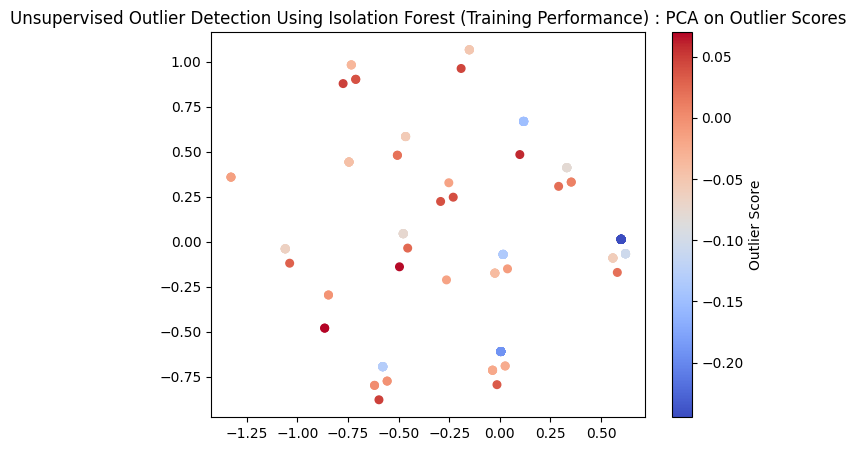

In [374]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Isolation Forest 
# using the train data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_iforest_training_scores, -unsupervised_model_iforest_training_scores, "Unsupervised Outlier Detection Using Isolation Forest (Training Performance)")


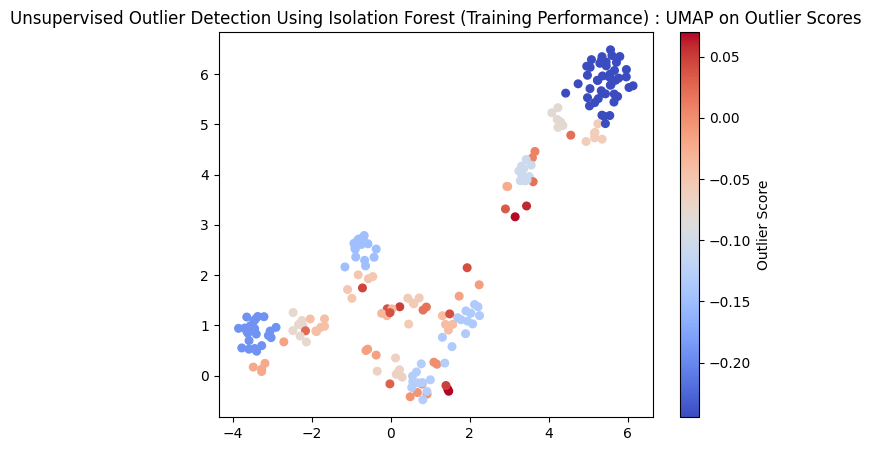

In [375]:
#################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Isolation Forest 
# using the train data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_iforest_training_scores, -unsupervised_model_iforest_training_scores, "Unsupervised Outlier Detection Using Isolation Forest (Training Performance)")


In [376]:
##################################
# Conducting apparent validation
# of the optimal Isolation Forest 
# using the train data
##################################
unsupervised_model_iforest.fit(X_train)
unsupervised_model_iforest_validation_scores = unsupervised_model_iforest.decision_function(X_validation.values)
unsupervised_iforest_entropy_validation, unsupervised_iforest_silhouette_validation, unsupervised_iforest_variance_validation = evaluate_unsupervised_outlier_detection_model(unsupervised_model_iforest_validation_scores, "Unsupervised Outlier Detection Using Isolation Forest (Validation Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Isolation Forest (Validation Performance)
  Score Entropy     : 1.981
  Score Silhouette  : 0.683
  Score Variance    : 0.009
----------------------------------------


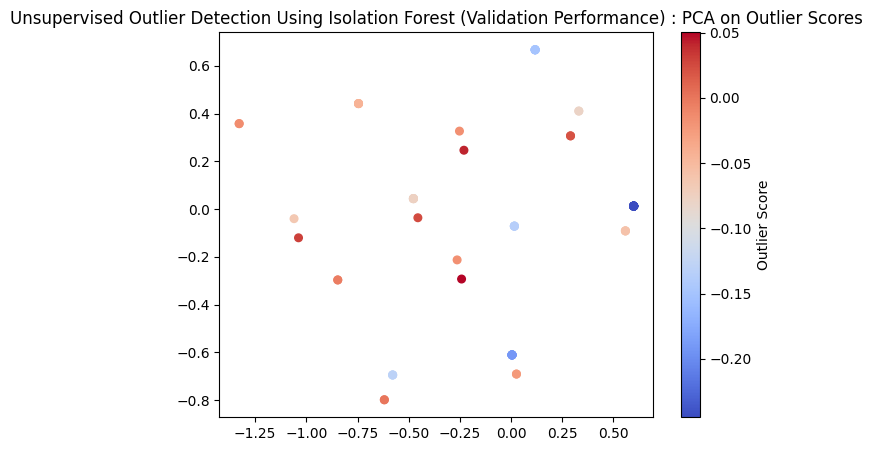

In [377]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Isolation Forest 
# using the validation data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_iforest_training_scores, -unsupervised_model_iforest_validation_scores, "Unsupervised Outlier Detection Using Isolation Forest (Validation Performance)")


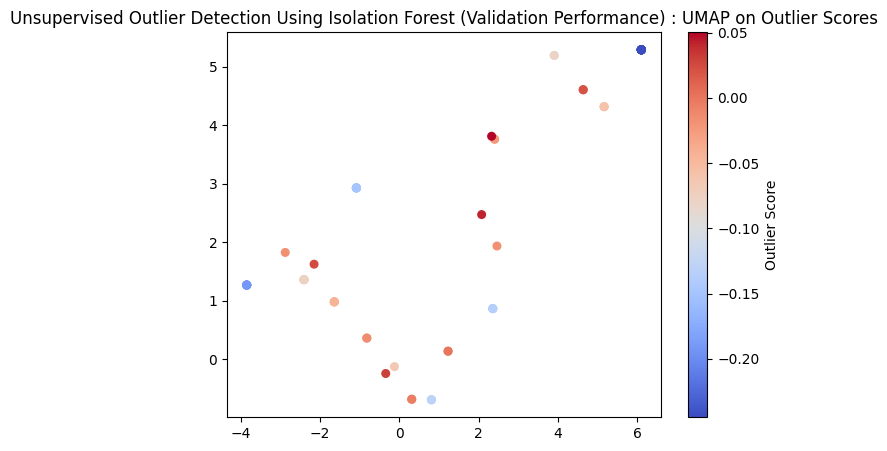

In [378]:
##################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Isolation Forest 
# using the validation data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_iforest_training_scores, -unsupervised_model_iforest_validation_scores, "Unsupervised Outlier Detection Using Isolation Forest (Validation Performance)")


In [379]:
##################################
# Consolidating all the performance measures
# for the Isolation Forest model
# without ground truth labels
# for the train and validation data
##################################
unsupervised_model_iforest_metric_summary = pd.DataFrame()
unsupervised_model_iforest_metric_summary['metric'] = ["Entropy", "Silhouette", "Variance"] * 2
unsupervised_model_iforest_metric_summary['metric_value'] = [unsupervised_iforest_entropy_training, unsupervised_iforest_silhouette_training, unsupervised_iforest_variance_training, unsupervised_iforest_entropy_validation, unsupervised_iforest_silhouette_validation, unsupervised_iforest_variance_validation]
unsupervised_model_iforest_metric_summary['model'] = ["Isolation Forest"] * 6
unsupervised_model_iforest_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(supervised_model_iforest_metric_summary)


,metric,metric_value,model,set
0,AUROC,0.991508,Isolation Forest,Train
1,Precision@N,0.900000,Isolation Forest,Train
2,F1Score,0.818182,Isolation Forest,Train
3,AUROC,0.981567,Isolation Forest,Validation
4,Precision@N,1.000000,Isolation Forest,Validation
5,F1Score,0.800000,Isolation Forest,Validation


### 1.8.2 Local Outlier Factor <a class="anchor" id="1.8.2"></a>

[Clustering-Based Local Outlier Factor](https://link.springer.com/book/10.1007/978-3-319-47578-3), in the unsupervised version, operates solely based on internal data structure, without referencing any ground truth. It clusters the dataset and then computes a score based on the distance of a sample to its cluster centroid and the size of the cluster. The key assumption is that anomalies either belong to small, sparse clusters or are far from the center of dense clusters. For categorical data, suitable encoding transforms (e.g., target, ordinal) are necessary for meaningful distance calculations. The CBLOF score quantifies this abnormality: high scores suggest deviation from the data's cluster structure. Since labels are unknown, models are assessed using internal metrics like Silhouette Score of the score distribution, entropy of scores, and score variance. A low entropy and high silhouette imply the model has successfully identified two distinct subgroups: likely inliers and outliers. CBLOF is intuitive in settings where anomalies are structurally different and not well-integrated into existing clusters. It performs well when categorical attributes cluster tightly under normal conditions. However, its success hinges on the validity of the cluster structure and the distance metric used.

1. The [clustering-based local outlier factor](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/cblof.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.cblof</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">alpha</span> = threshold factor that determines whether a cluster is considered large or small based on the ratio of its size to the largest cluster, influencing the distinction between inliers and potential outliers made to vary between 0.90 and 0.80
    * <span style="color: #FF0000">n_clusters</span> = number of clusters to form during the internal KMeans clustering step, which serves as the foundation for assigning CBLOF scores made to vary between 8, 12 and 16
    * <span style="color: #FF0000">beta</span> = scaling factor used in the CBLOF score computation to penalize the distance of points in small clusters more heavily than those in large clusters made to vary between 5, 10 and 15
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
    * <span style="color: #FF0000">random_state</span> = seed for the random number generator, ensuring reproducibility of results across runs by controlling random sampling and feature selection fixed at 42
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">alpha</span> = 0.80
    * <span style="color: #FF0000">n_clusters</span> = 16
    * <span style="color: #FF0000">beta</span> = 15
5. The apparent model performance of the optimal model is summarized as follows:
    * **Entropy** = 1.704
    * **Silhouette Score** = 0.766
    * **Variance** = 0.211
6. The independent validation model performance of the optimal model is summarized as follows:
    * **Entropy** = 1.758
    * **Silhouette Score** = 0.724
    * **Variance** = 0.174
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [380]:
##################################
# Formulating a hyperparameter tuning grid
# based on Local Outlier Factor
##################################
cblof_grid = {
    "alpha": [0.9, 0.8],
    "n_clusters": [8, 12, 16],
    "beta": [5, 10, 15],
    "contamination": [0.10],
    "random_state": [42]
}


In [381]:
##################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Local Outlier Factor
##################################
best_unsupervised_model_cblof_params, unsupervised_model_cblof_results_df = run_monte_carlo_cv_unsupervised_outlier_detection_model(CBLOF, cblof_grid, X_train, model_name="CBLOF")
unsupervised_model_cblof = CBLOF(**best_unsupervised_model_cblof_params)


Best CBLOF params: {'alpha': 0.8, 'beta': 15, 'contamination': 0.1, 'n_clusters': 16, 'random_state': 42} with Silhouette: 0.819

Top Hyperparameter Combinations Ranked by Mean Silhouette Score:


,Params,Mean Silhouette,Std Silhouette
0,"{'alpha': 0.8, 'beta': 15, 'contamination': 0....",0.818918,0.035398
1,"{'alpha': 0.8, 'beta': 10, 'contamination': 0....",0.818918,0.035398
2,"{'alpha': 0.8, 'beta': 5, 'contamination': 0.1...",0.818636,0.035181
3,"{'alpha': 0.9, 'beta': 10, 'contamination': 0....",0.812227,0.040166
4,"{'alpha': 0.9, 'beta': 15, 'contamination': 0....",0.812227,0.040166
5,"{'alpha': 0.9, 'beta': 5, 'contamination': 0.1...",0.812097,0.040081
6,"{'alpha': 0.8, 'beta': 10, 'contamination': 0....",0.782661,0.035828
7,"{'alpha': 0.8, 'beta': 15, 'contamination': 0....",0.782661,0.035828
8,"{'alpha': 0.8, 'beta': 5, 'contamination': 0.1...",0.781899,0.036482
9,"{'alpha': 0.9, 'beta': 5, 'contamination': 0.1...",0.774619,0.040676


In [382]:
##################################
# Conducting apparent validation
# of the optimal Local Outlier Factor
# using the train data
##################################
unsupervised_model_cblof.fit(X_train)
unsupervised_model_cblof_training_scores = unsupervised_model_cblof.decision_function(X_train.values)
unsupervised_cblof_entropy_training, unsupervised_cblof_silhouette_training, unsupervised_cblof_variance_training = evaluate_unsupervised_outlier_detection_model(unsupervised_model_cblof_training_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Training Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Local Outlier Factor (Training Performance)
  Score Entropy     : 1.704
  Score Silhouette  : 0.766
  Score Variance    : 0.211
----------------------------------------


In [383]:
##################################
# Saving the optimal Local Outlier Factor model
# developed from the training data
##################################
joblib.dump(
    unsupervised_model_cblof, 
    os.path.join("..", MODELS_PATH, "unsupervised_model_cblof_optimal.pkl")
)

['..\\models\\unsupervised_model_cblof_optimal.pkl']

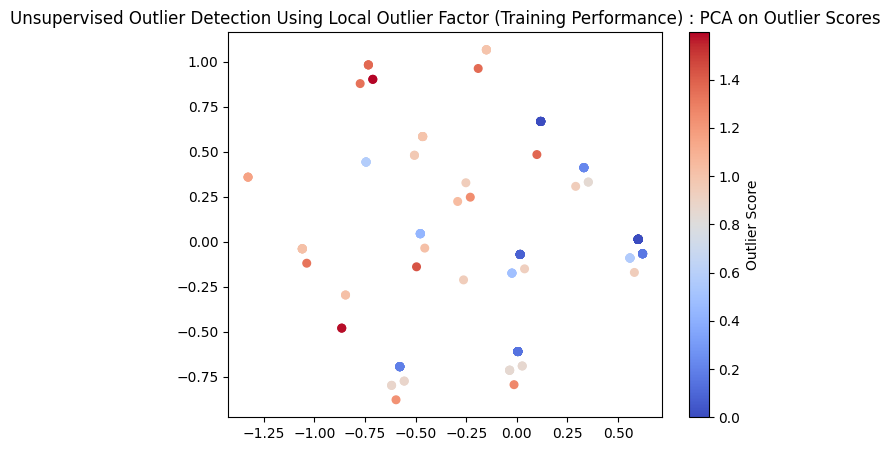

In [384]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Local Outlier Factor
# using the train data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_cblof_training_scores, -unsupervised_model_cblof_training_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Training Performance)")


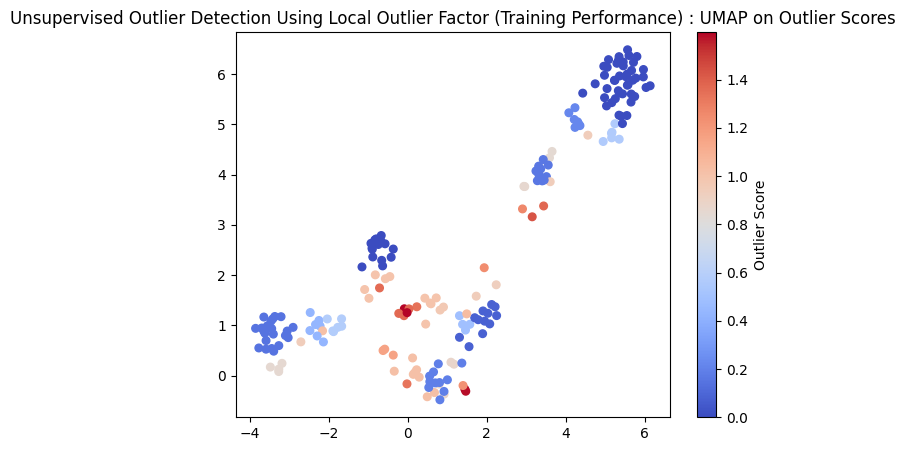

In [385]:
#################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Local Outlier Factor
# using the train data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_cblof_training_scores, -unsupervised_model_cblof_training_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Training Performance)")


In [386]:
##################################
# Conducting apparent validation
# of the optimal Local Outlier Factor
# using the train data
##################################
unsupervised_model_cblof.fit(X_train)
unsupervised_model_cblof_validation_scores = unsupervised_model_cblof.decision_function(X_validation.values)
unsupervised_cblof_entropy_validation, unsupervised_cblof_silhouette_validation, unsupervised_cblof_variance_validation =  evaluate_unsupervised_outlier_detection_model(unsupervised_model_cblof_validation_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Validation Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Local Outlier Factor (Validation Performance)
  Score Entropy     : 1.758
  Score Silhouette  : 0.724
  Score Variance    : 0.174
----------------------------------------


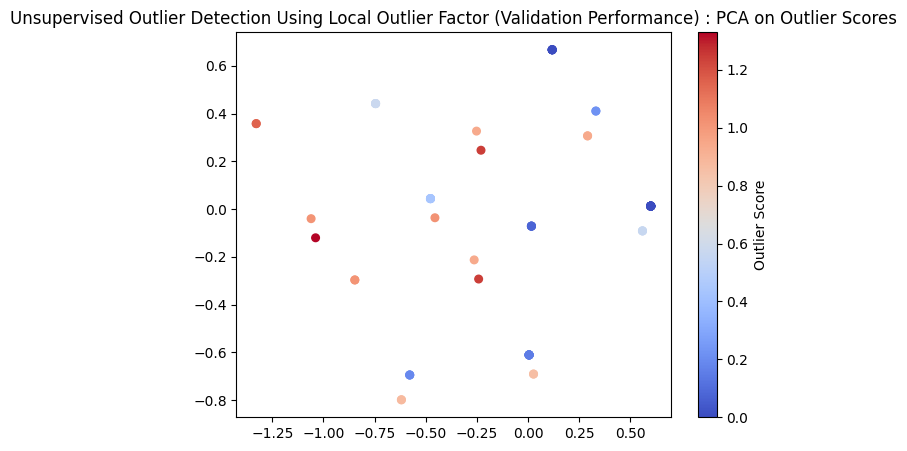

In [387]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Local Outlier Factor
# using the validation data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_cblof_training_scores, -unsupervised_model_cblof_validation_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Validation Performance)")


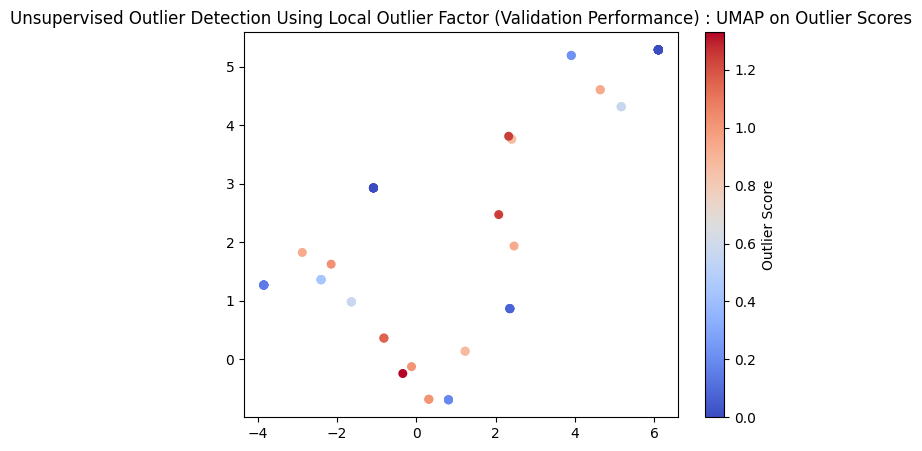

In [388]:
##################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Local Outlier Factor
# using the validation data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_cblof_training_scores, -unsupervised_model_cblof_validation_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Validation Performance)")


In [389]:
##################################
# Consolidating all the performance measures
# for the Local Outlier Factor model
# without ground truth labels
# for the train and validation data
##################################
unsupervised_model_cblof_metric_summary = pd.DataFrame()
unsupervised_model_cblof_metric_summary['metric'] = ["Entropy", "Silhouette", "Variance"] * 2
unsupervised_model_cblof_metric_summary['metric_value'] = [unsupervised_cblof_entropy_training, unsupervised_cblof_silhouette_training, unsupervised_cblof_variance_training, unsupervised_cblof_entropy_validation, unsupervised_cblof_silhouette_validation, unsupervised_cblof_variance_validation]
unsupervised_model_cblof_metric_summary['model'] = ["Clustering-Based Local Outlier Factor"] * 6
unsupervised_model_cblof_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(unsupervised_model_cblof_metric_summary)


,metric,metric_value,model,set
0,Entropy,1.703652,Clustering-Based Local Outlier Factor,Train
1,Silhouette,0.766419,Clustering-Based Local Outlier Factor,Train
2,Variance,0.211429,Clustering-Based Local Outlier Factor,Train
3,Entropy,1.757826,Clustering-Based Local Outlier Factor,Validation
4,Silhouette,0.723801,Clustering-Based Local Outlier Factor,Validation
5,Variance,0.173675,Clustering-Based Local Outlier Factor,Validation


### 1.8.3 K-Nearest Neighbors Outlier Score <a class="anchor" id="1.8.3"></a>

[K-Nearest Neighbor Outlier Score](https://link.springer.com/book/10.1007/978-3-319-47578-3), for the unsuperevised approach, no labels are available, so anomaly detection relies on local density estimates alone. Each point’s score is determined by its distance to the k nearest neighbors — a high score implies that the point lies in a sparse region, indicative of anomaly. After encoding categorical features, Hamming or other suitable categorical distances are used. The resulting scores are interpreted through unsupervised evaluation metrics: Silhouette Score on scores, entropy of the score distribution, and variance. These help in identifying natural separations in the score space. High silhouette scores, for example, indicate a clean separation between low-score (normal) and high-score (anomaly) groups. KNN is particularly effective when anomalies lie outside dense local clusters or in sparse corners of the feature space. It is non-parametric, requiring no distributional assumptions, making it versatile for complex categorical relationships. However, the curse of dimensionality and high cardinality features may dilute distance-based signals unless preprocessing and encoding are carefully managed.

1. The [k-nearest neighbor outlier score](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/knn.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.knn</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">method</span> = strategy for calculating outlier scores indicating the distance to the nearest neighbors, affecting how deviation from the neighborhood is quantified made to vary between largest and mean
    * <span style="color: #FF0000">n_neighbors</span> = number of nearest neighbors used to compute distances for determining the outlier score, which controls the local context of anomaly detection made to vary between 5, 10 and 15
    * <span style="color: #FF0000">metric</span> = determines the distance metric used to compute distances between instances, directly impacting neighborhood relationships and score calculations made to vary between minkowski, euclidean and manhattan
3. The model contains 1 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">method</span> = largest
    * <span style="color: #FF0000">n_neighbors</span> = 5
    * <span style="color: #FF0000">metric</span> = minkowski
5. The apparent model performance of the optimal model is summarized as follows:
    * **Entropy** = 0.594
    * **Silhouette Score** = 0.987
    * **Variance** = 0.188
6. The independent validation model performance of the optimal model is summarized as follows:
    * **Entropy** = 0.542
    * **Silhouette Score** = 1.000
    * **Variance** = 0.178
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [390]:
##################################
# Formulating a hyperparameter tuning grid
# based on K-Nearest Neighbors Outlier Score
##################################
knn_grid = {
    "method": ["largest", "mean"],
    "n_neighbors": [5, 10, 15],
    "metric": ["minkowski", "euclidean", "manhattan"],
    "contamination": [0.10]
}

In [391]:
#################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on K-Nearest Neighbors Outlier Score
##################################
best_unsupervised_model_knn_params, unsupervised_model_knn_results_df = run_monte_carlo_cv_unsupervised_outlier_detection_model(KNN, knn_grid, X_train, model_name="KNN")
unsupervised_model_knn = KNN(**best_unsupervised_model_knn_params)


Best KNN params: {'contamination': 0.1, 'method': 'largest', 'metric': 'minkowski', 'n_neighbors': 5} with Silhouette: 0.974

Top Hyperparameter Combinations Ranked by Mean Silhouette Score:


,Params,Mean Silhouette,Std Silhouette
0,"{'contamination': 0.1, 'method': 'largest', 'm...",0.974186,0.014496
1,"{'contamination': 0.1, 'method': 'largest', 'm...",0.974186,0.014496
2,"{'contamination': 0.1, 'method': 'largest', 'm...",0.945479,0.018007
3,"{'contamination': 0.1, 'method': 'largest', 'm...",0.945479,0.018007
4,"{'contamination': 0.1, 'method': 'largest', 'm...",0.945241,0.030751
5,"{'contamination': 0.1, 'method': 'largest', 'm...",0.907555,0.020800
6,"{'contamination': 0.1, 'method': 'largest', 'm...",0.907555,0.020800
7,"{'contamination': 0.1, 'method': 'largest', 'm...",0.882615,0.039191
8,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.830621,0.043829
9,"{'contamination': 0.1, 'method': 'mean', 'metr...",0.830621,0.043829


In [392]:
##################################
# Conducting apparent validation
# of the optimal K-Nearest Neighbors Outlier Score
# using the train data
##################################
unsupervised_model_knn.fit(X_train)
unsupervised_model_knn_training_scores = unsupervised_model_knn.decision_function(X_train.values)
unsupervised_knn_entropy_training, unsupervised_knn_silhouette_training, unsupervised_knn_variance_training = evaluate_unsupervised_outlier_detection_model(unsupervised_model_knn_training_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)
  Score Entropy     : 0.594
  Score Silhouette  : 0.987
  Score Variance    : 0.188
----------------------------------------


In [393]:
##################################
# Saving the optimal K-Nearest Neighbors Outlier Score model
# developed from the training data
##################################
joblib.dump(
    unsupervised_model_knn, 
    os.path.join("..", MODELS_PATH, "unsupervised_model_knn_optimal.pkl")
)

['..\\models\\unsupervised_model_knn_optimal.pkl']

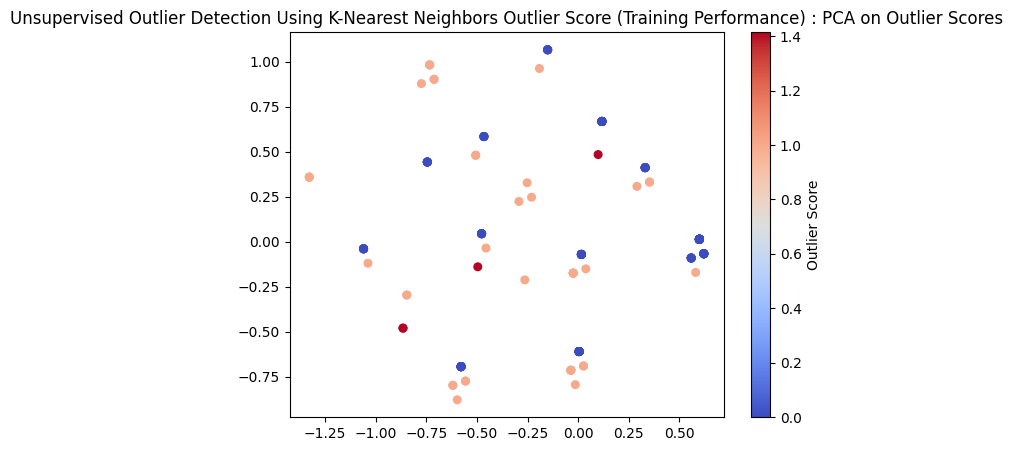

In [394]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal K-Nearest Neighbors Outlier Score
# using the train data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_knn_training_scores, -unsupervised_model_knn_training_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)")


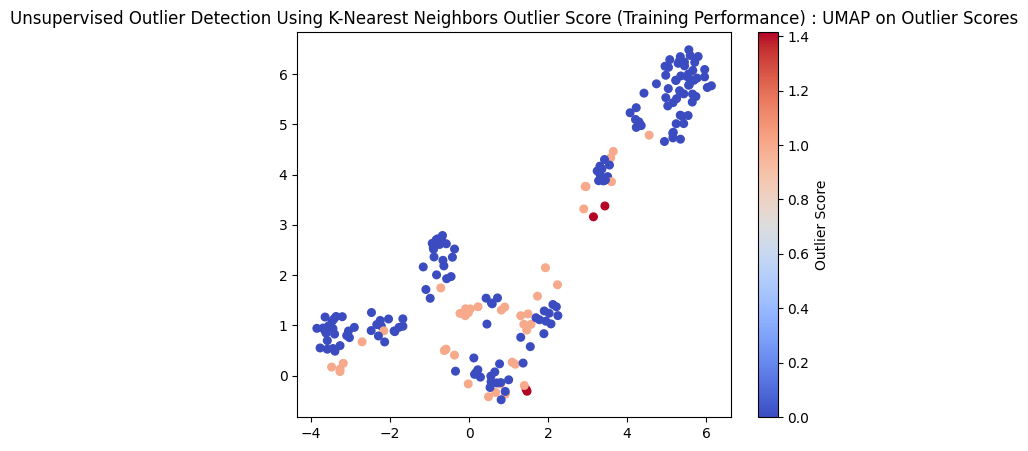

In [395]:
#################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal K-Nearest Neighbors Outlier Score
# using the train data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_knn_training_scores, -unsupervised_model_knn_training_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Training Performance)")


In [396]:
##################################
# Conducting apparent validation
# of the optimal K-Nearest Neighbors Outlier Score
# using the train data
##################################
unsupervised_model_knn.fit(X_train)
unsupervised_model_knn_validation_scores = unsupervised_model_knn.decision_function(X_validation.values)
unsupervised_knn_entropy_validation, unsupervised_knn_silhouette_validation, unsupervised_knn_variance_validation = evaluate_unsupervised_outlier_detection_model(unsupervised_model_knn_validation_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)
  Score Entropy     : 0.542
  Score Silhouette  : 1.000
  Score Variance    : 0.178
----------------------------------------


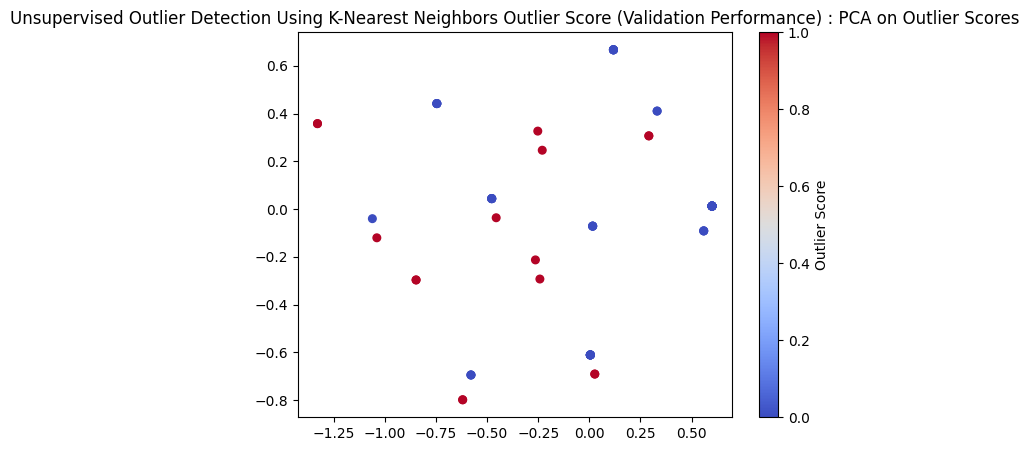

In [397]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal K-Nearest Neighbors Outlier Score
# using the validation data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_knn_training_scores, -unsupervised_model_knn_validation_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)")


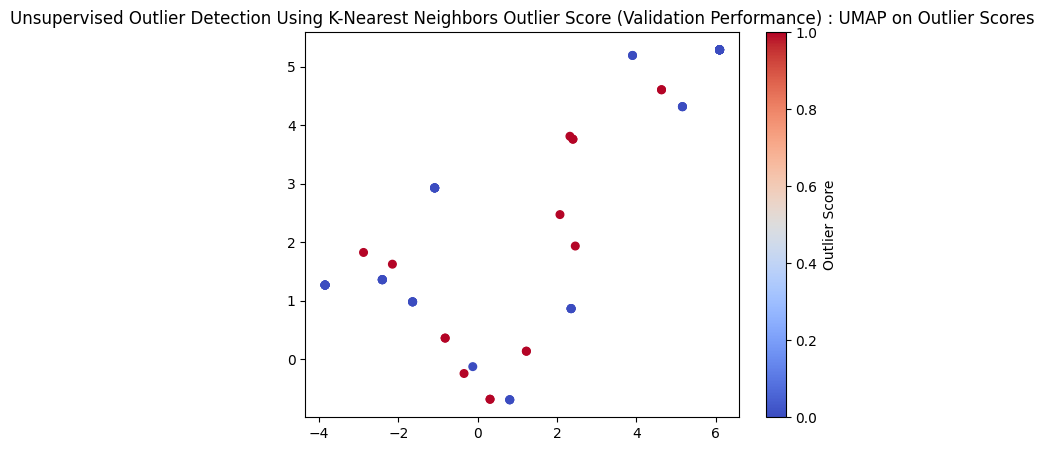

In [398]:
##################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal K-Nearest Neighbors Outlier Score
# using the validation data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_knn_training_scores, -unsupervised_model_knn_validation_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Validation Performance)")


In [399]:
##################################
# Consolidating all the performance measures
# for the K-Nearest Neighbors Outlier Score model
# without ground truth labels
# for the train and validation data
##################################
unsupervised_model_knn_metric_summary = pd.DataFrame()
unsupervised_model_knn_metric_summary['metric'] = ["Entropy", "Silhouette", "Variance"] * 2
unsupervised_model_knn_metric_summary['metric_value'] = [unsupervised_knn_entropy_training, unsupervised_knn_silhouette_training, unsupervised_knn_variance_training, unsupervised_knn_entropy_validation, unsupervised_knn_silhouette_validation, unsupervised_knn_variance_validation]
unsupervised_model_knn_metric_summary['model'] = ["K-Nearest Neighbors Outlier Score"] * 6
unsupervised_model_knn_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(unsupervised_model_knn_metric_summary)



,metric,metric_value,model,set
0,Entropy,0.593819,K-Nearest Neighbors Outlier Score,Train
1,Silhouette,0.987080,K-Nearest Neighbors Outlier Score,Train
2,Variance,0.187888,K-Nearest Neighbors Outlier Score,Train
3,Entropy,0.541543,K-Nearest Neighbors Outlier Score,Validation
4,Silhouette,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,Variance,0.178114,K-Nearest Neighbors Outlier Score,Validation


### 1.8.4 Histogram-Based Outlier Score <a class="anchor" id="1.8.4"></a>

[Histogram-Based Outlier Score](https://link.springer.com/book/10.1007/978-3-319-47578-3), in an unsupervised setting, works by modeling each feature independently and assessing how unusual a value is based on its frequency. For categorical data, this translates into computing how rare each category is per feature. A sample with rare values across multiple features will have a high combined outlier score. The main assumption is feature independence — HBOS does not consider interactions between features. This independence simplifies computation and makes HBOS highly scalable. Since ground truth is absent, evaluation uses score distribution metrics like silhouette on scores, entropy, and variance. A successful model produces clear separation between high and low scores, with lower entropy and higher variance being indicative of stronger separation. HBOS is effective when anomalies express themselves through rare feature values or unusual marginal distributions. Its independence assumption can be both a strength (speed) and a limitation (missing multivariate anomalies). Nevertheless, it is fast, interpretable, and particularly suitable for initial anomaly screening in high-cardinality categorical datasets.

1. The [histogram-based outlier score](https://pyod.readthedocs.io/en/latest/_modules/pyod/models/hbos.html) model from the <mark style="background-color: #CCECFF"><b>pyod.models.hbos</b></mark> Python library API was implemented. 
2. The model contains 3 hyperparameters for tuning:
    * <span style="color: #FF0000">alpha</span> = regularization parameter that adjusts the influence of sparsity in feature histograms to avoid overfitting to noise or rare bins made to vary between 0.10 and 0.20
    * <span style="color: #FF0000">n_bins</span> = number of bins used to discretize continuous features into histograms, directly affecting the granularity of the outlier detection made to vary between 5, 10 and 15
    * <span style="color: #FF0000">tol</span> = tolerance threshold for discarding features that have too many identical values, helping to avoid distortion in histogram-based density estimation made to vary between 0.25, 0.50 and 0.75
3. The model contains 2 hyperparameters fixed during tuning:
    * <span style="color: #FF0000">contamination</span> = expected proportion of outliers in the dataset, used to calibrate the decision threshold for classifying points as anomalies fixed at 0.10
4. Hyperparameter tuning was conducted using the 100-cycle Monte-Carlo cross-validation method with optimal model performance using the AUROC determined for: 
    * <span style="color: #FF0000">alpha</span> = 0.10
    * <span style="color: #FF0000">n_bins</span> = 15
    * <span style="color: #FF0000">tol</span> = 0.50
5. The apparent model performance of the optimal model is summarized as follows:
    * **Entropy** = 1.809
    * **Silhouette Score** = 0.623
    * **Variance** = 3.584
6. The independent validation model performance of the optimal model is summarized as follows:
    * **Entropy** = 2.113
    * **Silhouette Score** = 0.667
    * **Variance** = 2.976
7. Sufficiently comparable apparent and independent validation model performance observed that might be indicative of the absence of excessive model overfitting.

In [400]:
##################################
# Formulating a hyperparameter tuning grid
# based on Histogram-Based Outlier Score
##################################
hbos_grid = {
    "alpha": [0.1, 0.2],
    "n_bins": [5, 10, 15],
    "tol": [0.25, 0.50, 0.75],
    "contamination": [0.10]
}

In [401]:
#################################
# Conducting hyperparameter tuning
# using a Monte Carlo cross-validation setup
# and identifying the optimal hyperparamter combination
# based on Histogram-Based Outlier Score
##################################
best_unsupervised_model_hbos_params, unsupervised_model_hbos_results_df = run_monte_carlo_cv_unsupervised_outlier_detection_model(HBOS, hbos_grid, X_train, model_name="HBOS")
unsupervised_model_hbos = HBOS(**best_unsupervised_model_hbos_params)


Best HBOS params: {'alpha': 0.1, 'contamination': 0.1, 'n_bins': 15, 'tol': 0.75} with Silhouette: 0.630

Top Hyperparameter Combinations Ranked by Mean Silhouette Score:


,Params,Mean Silhouette,Std Silhouette
0,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.630131,0.033528
1,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.630039,0.033373
2,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.629970,0.033126
3,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.629943,0.033091
4,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.629920,0.033455
5,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.629894,0.033841
6,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.629870,0.033854
7,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.629832,0.033367
8,"{'alpha': 0.2, 'contamination': 0.1, 'n_bins':...",0.629798,0.033753
9,"{'alpha': 0.1, 'contamination': 0.1, 'n_bins':...",0.629758,0.033650


In [402]:
##################################
# Conducting apparent validation
# of the optimal Histogram-Based Outlier Score
# using the train data
##################################
unsupervised_model_hbos.fit(X_train)
unsupervised_model_hbos_training_scores = unsupervised_model_hbos.decision_function(X_train.values)
unsupervised_hbos_entropy_training, unsupervised_hbos_silhouette_training, unsupervised_hbos_variance_training = evaluate_unsupervised_outlier_detection_model(unsupervised_model_hbos_training_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)
  Score Entropy     : 1.809
  Score Silhouette  : 0.623
  Score Variance    : 3.584
----------------------------------------


In [403]:
##################################
# Saving the optimal Histogram-Based Outlier Score model
# developed from the training data
##################################
joblib.dump(
    unsupervised_model_hbos, 
    os.path.join("..", MODELS_PATH, "unsupervised_model_hbos_optimal.pkl")
)

['..\\models\\unsupervised_model_hbos_optimal.pkl']

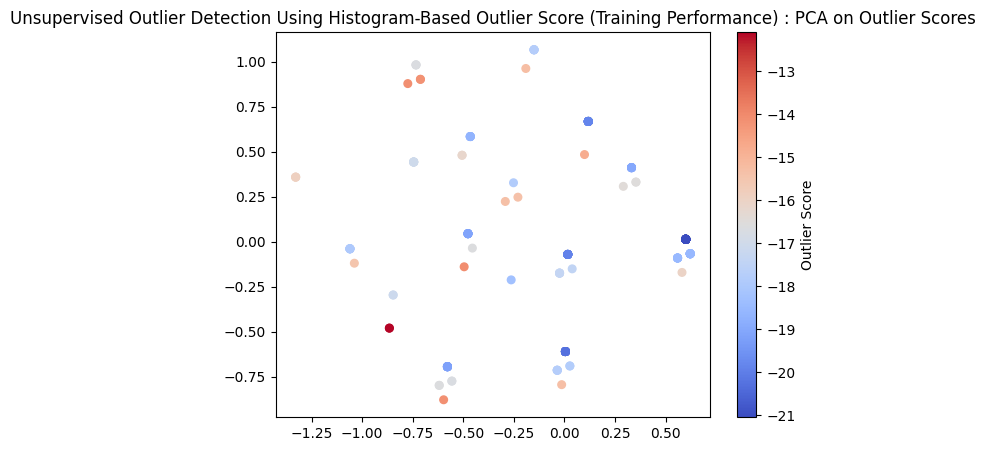

In [404]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Histogram-Based Outlier Score
# using the train data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_hbos_training_scores, -unsupervised_model_hbos_training_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)")


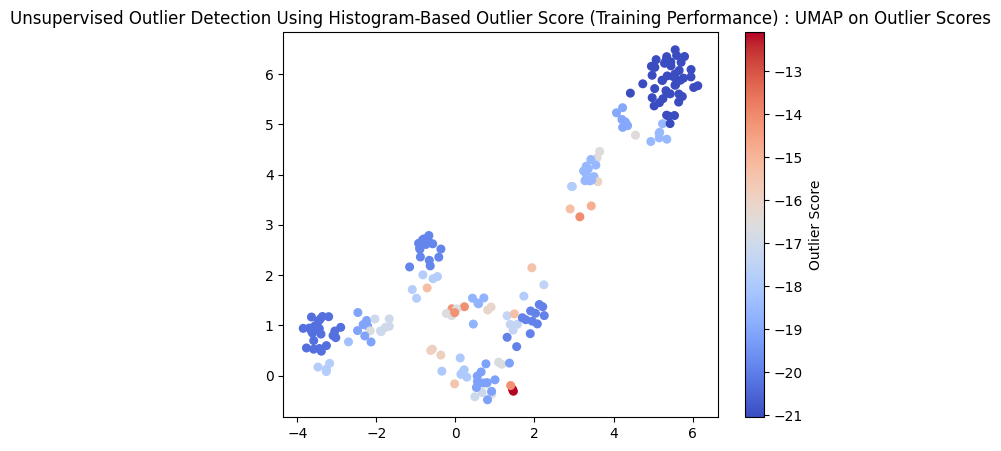

In [405]:
#################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Histogram-Based Outlier Score
# using the train data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_train, -unsupervised_model_hbos_training_scores, -unsupervised_model_hbos_training_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Training Performance)")


In [406]:
##################################
# Conducting apparent validation
# of the optimal Histogram-Based Outlier Score
# using the train data
##################################
unsupervised_model_hbos.fit(X_train)
unsupervised_model_hbos_validation_scores = unsupervised_model_hbos.decision_function(X_validation.values)
unsupervised_hbos_entropy_validation, unsupervised_hbos_silhouette_validation, unsupervised_hbos_variance_validation = evaluate_unsupervised_outlier_detection_model(unsupervised_model_hbos_validation_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)
  Score Entropy     : 2.113
  Score Silhouette  : 0.667
  Score Variance    : 2.976
----------------------------------------


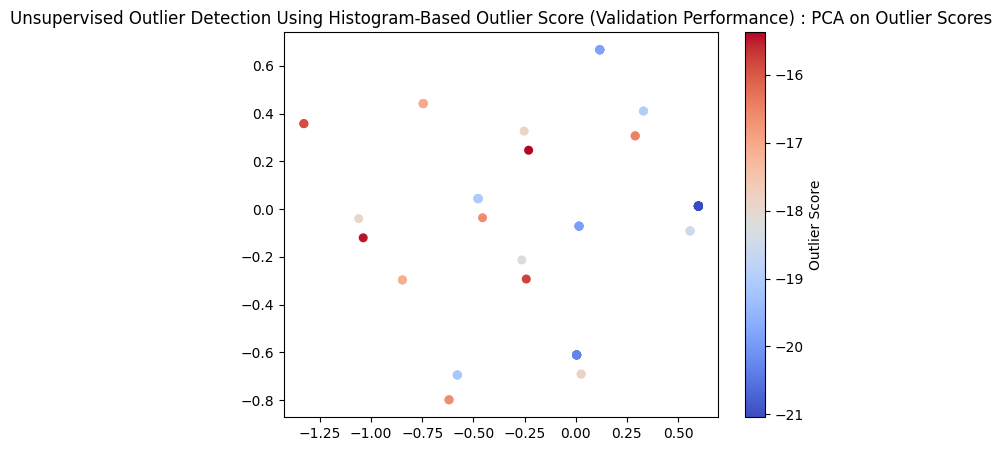

In [407]:
##################################
# Visualizing the outlier scores
# by implementing PCA
# obtained from the optimal Histogram-Based Outlier Score
# using the validation data
##################################
pca_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_hbos_training_scores, -unsupervised_model_hbos_validation_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)")


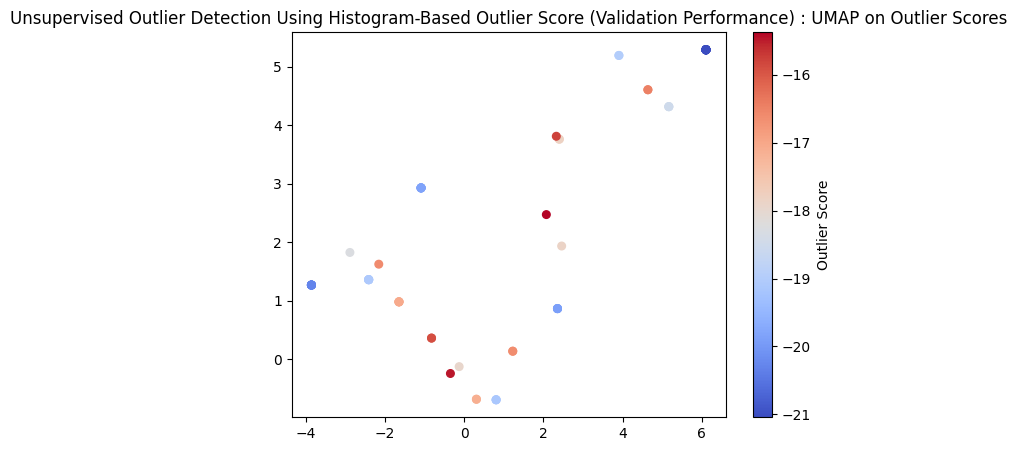

In [408]:
##################################
# Visualizing the outlier scores
# by implementing UMAP
# obtained from the optimal Histogram-Based Outlier Score
# using the validation data
##################################
umap_visualize_unsupervised_outlier_detection_model(X_train, X_validation, -unsupervised_model_hbos_training_scores, -unsupervised_model_hbos_validation_scores, "Unsupervised Outlier Detection Using Histogram-Based Outlier Score (Validation Performance)")


In [409]:
##################################
# Consolidating all the performance measures
# for the Histogram-Based Outlier Score model
# without ground truth labels
# for the train and validation data
##################################
unsupervised_model_hbos_metric_summary = pd.DataFrame()
unsupervised_model_hbos_metric_summary['metric'] = ["Entropy", "Silhouette", "Variance"] * 2
unsupervised_model_hbos_metric_summary['metric_value'] = [unsupervised_hbos_entropy_training, unsupervised_hbos_silhouette_training, unsupervised_hbos_variance_training, unsupervised_hbos_entropy_validation, unsupervised_hbos_silhouette_validation, unsupervised_hbos_variance_validation]
unsupervised_model_hbos_metric_summary['model'] = ["Histogram-Based Outlier Score"] * 6
unsupervised_model_hbos_metric_summary['set'] = (["Train"] * 3) + (["Validation"] * 3)
display(unsupervised_model_hbos_metric_summary)


,metric,metric_value,model,set
0,Entropy,1.809240,Histogram-Based Outlier Score,Train
1,Silhouette,0.623496,Histogram-Based Outlier Score,Train
2,Variance,3.584460,Histogram-Based Outlier Score,Train
3,Entropy,2.112608,Histogram-Based Outlier Score,Validation
4,Silhouette,0.667130,Histogram-Based Outlier Score,Validation
5,Variance,2.975885,Histogram-Based Outlier Score,Validation


## 1.9. Consolidated Findings <a class="anchor" id="1.9"></a>

In [410]:
##################################
# Consolidating all the performance measures
# for the supervised outlier detection models
# without ground truth labels
# for the train and validation data
##################################
supervised_model_metric_summary = pd.concat([supervised_model_iforest_metric_summary,
                                             supervised_model_cblof_metric_summary,
                                             supervised_model_knn_metric_summary,
                                             supervised_model_hbos_metric_summary], 
                                            ignore_index=True)
print('Consolidated Supervised Outlier Detection Model Performance on Train and Validation Data: ')
display(supervised_model_metric_summary)


Consolidated Supervised Outlier Detection Model Performance on Train and Validation Data: 


,metric,metric_value,model,set
0,AUROC,0.991508,Isolation Forest,Train
1,Precision@N,0.900000,Isolation Forest,Train
2,F1Score,0.818182,Isolation Forest,Train
3,AUROC,0.981567,Isolation Forest,Validation
4,Precision@N,1.000000,Isolation Forest,Validation
5,F1Score,0.800000,Isolation Forest,Validation
6,AUROC,0.985265,Clustering-Based Local Outlier Factor,Train
7,Precision@N,0.850000,Clustering-Based Local Outlier Factor,Train
8,F1Score,0.772727,Clustering-Based Local Outlier Factor,Train
9,AUROC,0.965438,Clustering-Based Local Outlier Factor,Validation


In [411]:
##################################
# Consolidating all the AUROC score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_auroc = supervised_model_metric_summary[supervised_model_metric_summary['metric']=='AUROC']
supervised_model_metric_summary_auroc_train = supervised_model_metric_summary_auroc[supervised_model_metric_summary_auroc['set']=='Train'].loc[:,"metric_value"]
supervised_model_metric_summary_auroc_validation = supervised_model_metric_summary_auroc[supervised_model_metric_summary_auroc['set']=='Validation'].loc[:,"metric_value"]

In [412]:
##################################
# Combining all the AUROC score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_auroc_plot = pd.DataFrame({'Train': supervised_model_metric_summary_auroc_train.values,
                                                           'Validation': supervised_model_metric_summary_auroc_validation.values},
                                                           index=supervised_model_metric_summary_auroc['model'].unique())
supervised_model_metric_summary_auroc_plot


,Train,Validation
Isolation Forest,0.991508,0.981567
Clustering-Based Local Outlier Factor,0.985265,0.965438
K-Nearest Neighbors Outlier Score,0.994131,0.994240
Histogram-Based Outlier Score,0.981019,0.958525


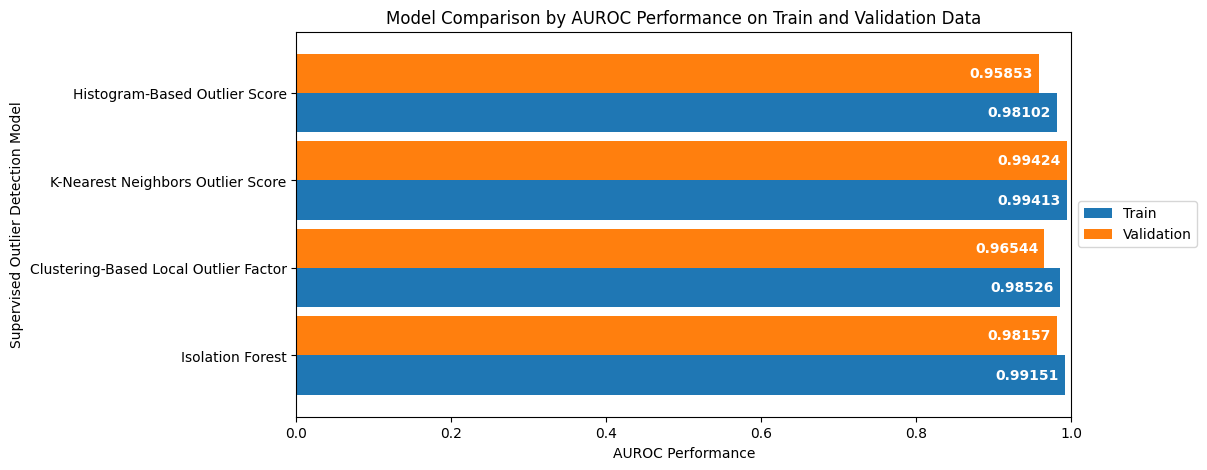

In [413]:
##################################
# Plotting all the AUROC score
# model performance measures
# between the train and validation sets
##################################
supervised_model_metric_summary_auroc_plot = supervised_model_metric_summary_auroc_plot.plot.barh(figsize=(10, 5), width=0.9)
supervised_model_metric_summary_auroc_plot.set_xlim(0.00,1.00)
supervised_model_metric_summary_auroc_plot.set_title("Model Comparison by AUROC Performance on Train and Validation Data")
supervised_model_metric_summary_auroc_plot.set_xlabel("AUROC Performance")
supervised_model_metric_summary_auroc_plot.set_ylabel("Supervised Outlier Detection Model")
supervised_model_metric_summary_auroc_plot.grid(False)
supervised_model_metric_summary_auroc_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in supervised_model_metric_summary_auroc_plot.containers:
    supervised_model_metric_summary_auroc_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')
    

In [414]:
##################################
# Consolidating all the Precision@N score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_precision = supervised_model_metric_summary[supervised_model_metric_summary['metric']=='Precision@N']
supervised_model_metric_summary_precision_train = supervised_model_metric_summary_precision[supervised_model_metric_summary_precision['set']=='Train'].loc[:,"metric_value"]
supervised_model_metric_summary_precision_validation = supervised_model_metric_summary_precision[supervised_model_metric_summary_precision['set']=='Validation'].loc[:,"metric_value"]


In [415]:
##################################
# Combining all the Precision@N score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_precision_plot = pd.DataFrame({'Train': supervised_model_metric_summary_precision_train.values,
                                                               'Validation': supervised_model_metric_summary_precision_validation.values},
                                                               index=supervised_model_metric_summary_precision['model'].unique())
supervised_model_metric_summary_precision_plot


,Train,Validation
Isolation Forest,0.90,1.000000
Clustering-Based Local Outlier Factor,0.85,0.666667
K-Nearest Neighbors Outlier Score,0.95,1.000000
Histogram-Based Outlier Score,0.85,0.666667


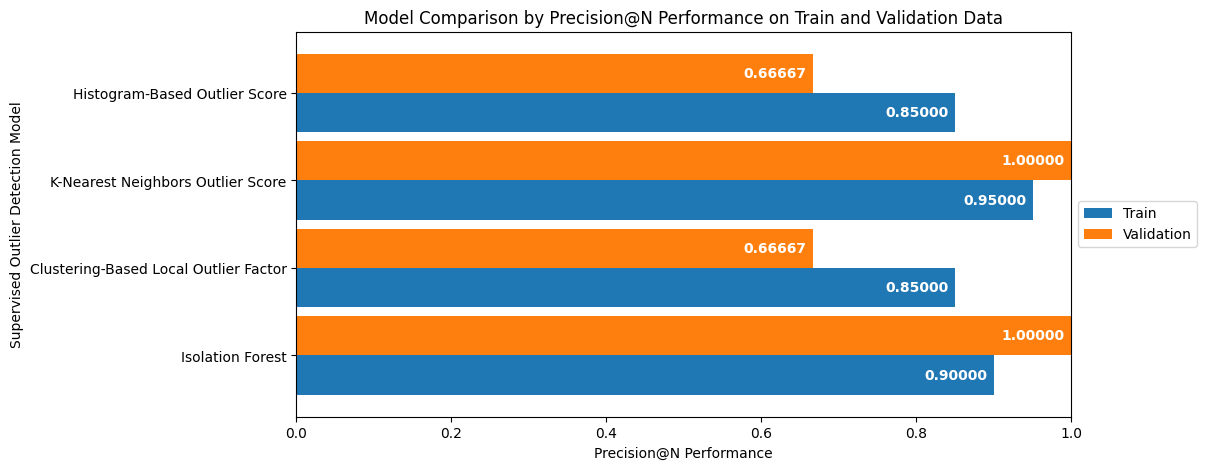

In [416]:
##################################
# Plotting all the Precision@N score
# model performance measures
# between the train and validation sets
##################################
supervised_model_metric_summary_precision_plot = supervised_model_metric_summary_precision_plot.plot.barh(figsize=(10, 5), width=0.9)
supervised_model_metric_summary_precision_plot.set_xlim(0.00,1.00)
supervised_model_metric_summary_precision_plot.set_title("Model Comparison by Precision@N Performance on Train and Validation Data")
supervised_model_metric_summary_precision_plot.set_xlabel("Precision@N Performance")
supervised_model_metric_summary_precision_plot.set_ylabel("Supervised Outlier Detection Model")
supervised_model_metric_summary_precision_plot.grid(False)
supervised_model_metric_summary_precision_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in supervised_model_metric_summary_precision_plot.containers:
    supervised_model_metric_summary_precision_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')
    


In [417]:
##################################
# Consolidating all the F1 score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_f1 = supervised_model_metric_summary[supervised_model_metric_summary['metric']=='F1Score']
supervised_model_metric_summary_f1_train = supervised_model_metric_summary_f1[supervised_model_metric_summary_f1['set']=='Train'].loc[:,"metric_value"]
supervised_model_metric_summary_f1_validation = supervised_model_metric_summary_f1[supervised_model_metric_summary_f1['set']=='Validation'].loc[:,"metric_value"]


In [418]:
##################################
# Combining all the F1 score
# model performance measures
# between the train and validation data
##################################
supervised_model_metric_summary_f1_plot = pd.DataFrame({'Train': supervised_model_metric_summary_f1_train.values,
                                                        'Validation': supervised_model_metric_summary_f1_validation.values},
                                                        index=supervised_model_metric_summary_f1['model'].unique())
supervised_model_metric_summary_f1_plot


,Train,Validation
Isolation Forest,0.818182,0.800000
Clustering-Based Local Outlier Factor,0.772727,0.571429
K-Nearest Neighbors Outlier Score,0.830189,0.933333
Histogram-Based Outlier Score,0.863636,0.714286


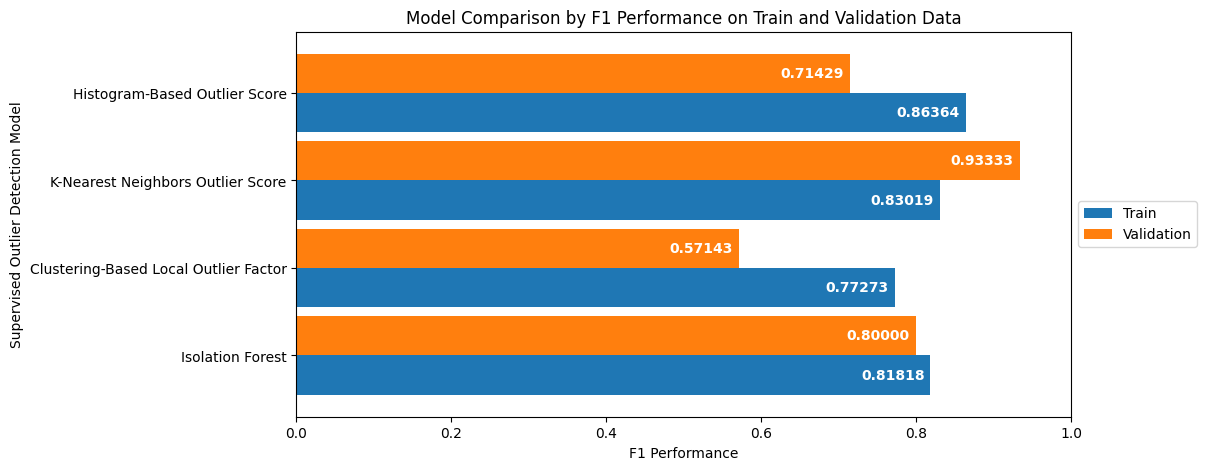

In [419]:
##################################
# Plotting all the F1 score
# model performance measures
# between the train and validation sets
##################################
supervised_model_metric_summary_f1_plot = supervised_model_metric_summary_f1_plot.plot.barh(figsize=(10, 5), width=0.9)
supervised_model_metric_summary_f1_plot.set_xlim(0.00,1.00)
supervised_model_metric_summary_f1_plot.set_title("Model Comparison by F1 Performance on Train and Validation Data")
supervised_model_metric_summary_f1_plot.set_xlabel("F1 Performance")
supervised_model_metric_summary_f1_plot.set_ylabel("Supervised Outlier Detection Model")
supervised_model_metric_summary_f1_plot.grid(False)
supervised_model_metric_summary_f1_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in supervised_model_metric_summary_f1_plot.containers:
    supervised_model_metric_summary_f1_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')



In [420]:
##################################
# Conducting external validation
# of the optimal K-Nearest Neighbors Outlier Score
# chosen as one of two best models
# using the test data
##################################
supervised_model_knn.fit(X_train)
supervised_model_knn.decision_scores_ = supervised_model_knn.decision_function(X_test.values)
supervised_knn_auroc_test, supervised_knn_precision_test, supervised_knn_f1_test = evaluate_supervised_outlier_detection_model(supervised_model_knn, X_test, y_test, "Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Test Performance)", top_n=int(0.10 * len(X_test)))

----------------------------------------
 Supervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Test Performance)
  AUROC       : 0.998
  Precision@N   : 0.889
  F1-score      : 0.909
----------------------------------------


In [421]:
##################################
# Consolidating all the performance measures
# for the K-Nearest Neighbors Outlier Score model
# with synthetic ground truth labels
# for the train, validation and test data
##################################
supervised_model_knn_metric_summary_final = pd.DataFrame()
supervised_model_knn_metric_summary_final['metric'] = ["AUROC", "Precision@N", "F1Score"] * 3
supervised_model_knn_metric_summary_final['metric_value'] = [supervised_knn_auroc_training, supervised_knn_precision_training, supervised_knn_f1_training, supervised_knn_auroc_validation, supervised_knn_precision_validation, supervised_knn_f1_validation, supervised_knn_auroc_test, supervised_knn_precision_test, supervised_knn_f1_test]
supervised_model_knn_metric_summary_final['model'] = ["K-Nearest Neighbors Outlier Score"] * 9
supervised_model_knn_metric_summary_final['set'] = (["Train"] * 3) + (["Validation"] * 3) + (["Test"] * 3)
display(supervised_model_knn_metric_summary_final)


,metric,metric_value,model,set
0,AUROC,0.994131,K-Nearest Neighbors Outlier Score,Train
1,Precision@N,0.950000,K-Nearest Neighbors Outlier Score,Train
2,F1Score,0.830189,K-Nearest Neighbors Outlier Score,Train
3,AUROC,0.994240,K-Nearest Neighbors Outlier Score,Validation
4,Precision@N,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,F1Score,0.933333,K-Nearest Neighbors Outlier Score,Validation
6,AUROC,0.997531,K-Nearest Neighbors Outlier Score,Test
7,Precision@N,0.888889,K-Nearest Neighbors Outlier Score,Test
8,F1Score,0.909091,K-Nearest Neighbors Outlier Score,Test


In [422]:
##################################
# Conducting external validation
# of the optimal Isolation Forest 
# chosen as one of two best models
# using the test data
##################################
supervised_model_iforest.fit(X_train)
supervised_model_iforest.decision_scores_ = supervised_model_iforest.decision_function(X_test.values)
supervised_iforest_auroc_test, supervised_iforest_precision_test, supervised_iforest_f1_test = evaluate_supervised_outlier_detection_model(supervised_model_iforest, X_test, y_test, "Supervised Outlier Detection Using Isolation Forest (Test Performance)", top_n=int(0.10 * len(X_test)))


----------------------------------------
 Supervised Outlier Detection Using Isolation Forest (Test Performance)
  AUROC       : 0.998
  Precision@N   : 1.000
  F1-score      : 0.857
----------------------------------------


In [423]:
##################################
# Consolidating all the performance measures
# for the K-Nearest Neighbors Outlier Score model
# with synthetic ground truth labels
# for the train, validation and test data
##################################
supervised_model_iforest_metric_summary_final = pd.DataFrame()
supervised_model_iforest_metric_summary_final['metric'] = ["AUROC", "Precision@N", "F1Score"] * 3
supervised_model_iforest_metric_summary_final['metric_value'] = [supervised_iforest_auroc_training, supervised_iforest_precision_training, supervised_iforest_f1_training, supervised_iforest_auroc_validation, supervised_iforest_precision_validation, supervised_iforest_f1_validation, supervised_iforest_auroc_test, supervised_iforest_precision_test, supervised_iforest_f1_test]
supervised_model_iforest_metric_summary_final['model'] = ["Isolation Forest"] * 9
supervised_model_iforest_metric_summary_final['set'] = (["Train"] * 3) + (["Validation"] * 3) + (["Test"] * 3)
display(supervised_model_iforest_metric_summary_final)



,metric,metric_value,model,set
0,AUROC,0.991508,Isolation Forest,Train
1,Precision@N,0.900000,Isolation Forest,Train
2,F1Score,0.818182,Isolation Forest,Train
3,AUROC,0.981567,Isolation Forest,Validation
4,Precision@N,1.000000,Isolation Forest,Validation
5,F1Score,0.800000,Isolation Forest,Validation
6,AUROC,0.997531,Isolation Forest,Test
7,Precision@N,1.000000,Isolation Forest,Test
8,F1Score,0.857143,Isolation Forest,Test


In [424]:
##################################
# Consolidating all the performance measures
# for the final supervised outlier detection models
# without ground truth labels
# for the train, validation and test data
##################################
supervised_model_metric_summary_final = pd.concat([supervised_model_knn_metric_summary_final,
                                                   supervised_model_iforest_metric_summary_final], 
                                                   ignore_index=True)
print('Consolidated Supervised Outlier Detection Model Performance on Train, Validation and Test Data: ')
display(supervised_model_metric_summary_final)



Consolidated Supervised Outlier Detection Model Performance on Train, Validation and Test Data: 


,metric,metric_value,model,set
0,AUROC,0.994131,K-Nearest Neighbors Outlier Score,Train
1,Precision@N,0.950000,K-Nearest Neighbors Outlier Score,Train
2,F1Score,0.830189,K-Nearest Neighbors Outlier Score,Train
3,AUROC,0.994240,K-Nearest Neighbors Outlier Score,Validation
4,Precision@N,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,F1Score,0.933333,K-Nearest Neighbors Outlier Score,Validation
6,AUROC,0.997531,K-Nearest Neighbors Outlier Score,Test
7,Precision@N,0.888889,K-Nearest Neighbors Outlier Score,Test
8,F1Score,0.909091,K-Nearest Neighbors Outlier Score,Test
9,AUROC,0.991508,Isolation Forest,Train


In [425]:
##################################
# Consolidating all the AUROC score
# model performance measures
# between the train, validation and test data
##################################
supervised_model_metric_summary_final_auroc = supervised_model_metric_summary_final[supervised_model_metric_summary_final['metric']=='AUROC']
supervised_model_metric_summary_final_auroc_train = supervised_model_metric_summary_final_auroc[supervised_model_metric_summary_final_auroc['set']=='Train'].loc[:,"metric_value"]
supervised_model_metric_summary_final_auroc_validation = supervised_model_metric_summary_final_auroc[supervised_model_metric_summary_final_auroc['set']=='Validation'].loc[:,"metric_value"]
supervised_model_metric_summary_final_auroc_test = supervised_model_metric_summary_final_auroc[supervised_model_metric_summary_final_auroc['set']=='Test'].loc[:,"metric_value"]


In [426]:
##################################
# Combining all the AUROC score
# model performance measures
# between the train, validation and test data
##################################
supervised_model_metric_summary_final_auroc_plot = pd.DataFrame({'Train': supervised_model_metric_summary_final_auroc_train.values,
                                                                 'Validation': supervised_model_metric_summary_final_auroc_validation.values,
                                                                 'Test': supervised_model_metric_summary_final_auroc_test.values},
                                                                 index=supervised_model_metric_summary_final_auroc['model'].unique())
supervised_model_metric_summary_final_auroc_plot


,Train,Validation,Test
K-Nearest Neighbors Outlier Score,0.994131,0.994240,0.997531
Isolation Forest,0.991508,0.981567,0.997531


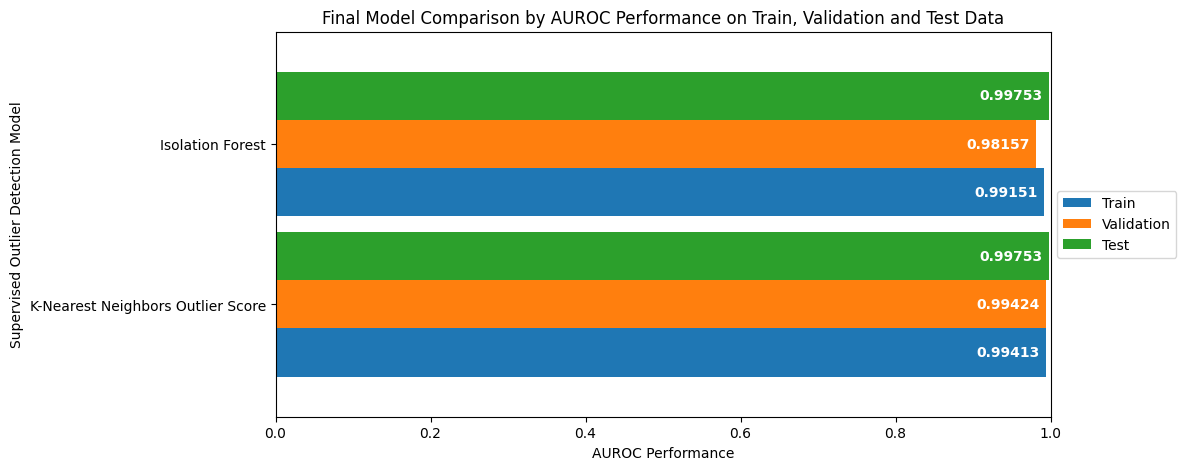

In [427]:
##################################
# Plotting all the AUROC score
# model performance measures
# between the train, validation and test sets
##################################
supervised_model_metric_summary_final_auroc_plot = supervised_model_metric_summary_final_auroc_plot.plot.barh(figsize=(10, 5), width=0.9)
supervised_model_metric_summary_final_auroc_plot.set_xlim(0.00,1.00)
supervised_model_metric_summary_final_auroc_plot.set_title("Final Model Comparison by AUROC Performance on Train, Validation and Test Data")
supervised_model_metric_summary_final_auroc_plot.set_xlabel("AUROC Performance")
supervised_model_metric_summary_final_auroc_plot.set_ylabel("Supervised Outlier Detection Model")
supervised_model_metric_summary_final_auroc_plot.grid(False)
supervised_model_metric_summary_final_auroc_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in supervised_model_metric_summary_final_auroc_plot.containers:
    supervised_model_metric_summary_final_auroc_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')


In [428]:
##################################
# Consolidating all the performance measures
# for the unsupervised outlier detection models
# without ground truth labels
# for the train and validation data
##################################
unsupervised_model_metric_summary = pd.concat([unsupervised_model_iforest_metric_summary,
                                             unsupervised_model_cblof_metric_summary,
                                             unsupervised_model_knn_metric_summary,
                                             unsupervised_model_hbos_metric_summary], 
                                            ignore_index=True)
print('Consolidated Unsupervised Outlier Detection Model Performance on Train and Validation Data: ')
display(unsupervised_model_metric_summary)


Consolidated Unsupervised Outlier Detection Model Performance on Train and Validation Data: 


,metric,metric_value,model,set
0,Entropy,2.059502,Isolation Forest,Train
1,Silhouette,0.634180,Isolation Forest,Train
2,Variance,0.008456,Isolation Forest,Train
3,Entropy,1.981241,Isolation Forest,Validation
4,Silhouette,0.683338,Isolation Forest,Validation
5,Variance,0.008951,Isolation Forest,Validation
6,Entropy,1.703652,Clustering-Based Local Outlier Factor,Train
7,Silhouette,0.766419,Clustering-Based Local Outlier Factor,Train
8,Variance,0.211429,Clustering-Based Local Outlier Factor,Train
9,Entropy,1.757826,Clustering-Based Local Outlier Factor,Validation


In [429]:
##################################
# Consolidating all the Silhouette score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_silhouette = unsupervised_model_metric_summary[unsupervised_model_metric_summary['metric']=='Silhouette']
unsupervised_model_metric_summary_silhouette_train = unsupervised_model_metric_summary_silhouette[unsupervised_model_metric_summary_silhouette['set']=='Train'].loc[:,"metric_value"]
unsupervised_model_metric_summary_silhouette_validation = unsupervised_model_metric_summary_silhouette[unsupervised_model_metric_summary_silhouette['set']=='Validation'].loc[:,"metric_value"]


In [430]:
##################################
# Combining all the Silhouette score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_silhouette_plot = pd.DataFrame({'Train': unsupervised_model_metric_summary_silhouette_train.values,
                                                                  'Validation': unsupervised_model_metric_summary_silhouette_validation.values},
                                                                  index=unsupervised_model_metric_summary_silhouette['model'].unique())
unsupervised_model_metric_summary_silhouette_plot



,Train,Validation
Isolation Forest,0.634180,0.683338
Clustering-Based Local Outlier Factor,0.766419,0.723801
K-Nearest Neighbors Outlier Score,0.987080,1.000000
Histogram-Based Outlier Score,0.623496,0.667130


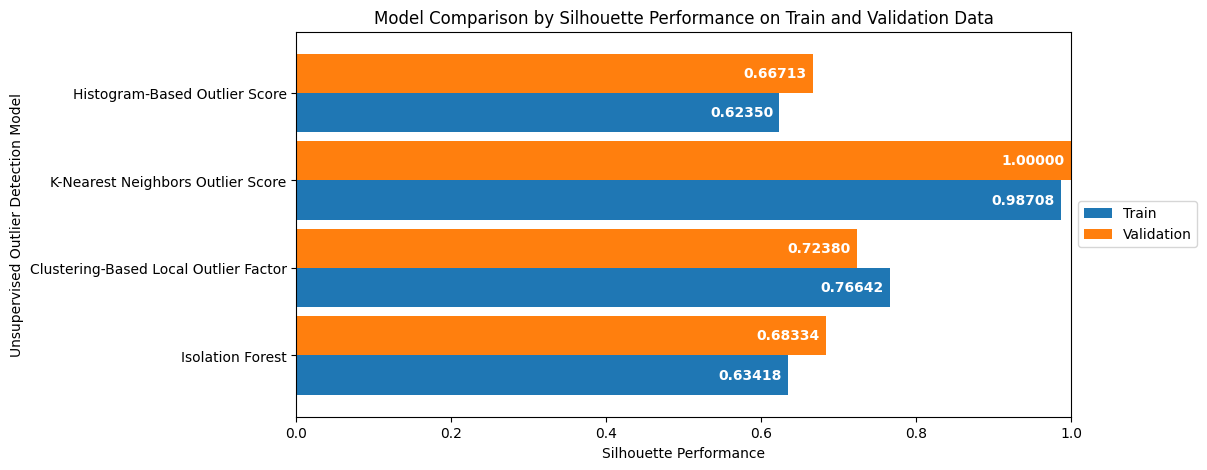

In [431]:
##################################
# Plotting all the Silhouette score
# model performance measures
# between the train and validation sets
##################################
unsupervised_model_metric_summary_silhouette_plot = unsupervised_model_metric_summary_silhouette_plot.plot.barh(figsize=(10, 5), width=0.9)
unsupervised_model_metric_summary_silhouette_plot.set_xlim(0.00,1.00)
unsupervised_model_metric_summary_silhouette_plot.set_title("Model Comparison by Silhouette Performance on Train and Validation Data")
unsupervised_model_metric_summary_silhouette_plot.set_xlabel("Silhouette Performance")
unsupervised_model_metric_summary_silhouette_plot.set_ylabel("Unsupervised Outlier Detection Model")
unsupervised_model_metric_summary_silhouette_plot.grid(False)
unsupervised_model_metric_summary_silhouette_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in unsupervised_model_metric_summary_silhouette_plot.containers:
    unsupervised_model_metric_summary_silhouette_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')


In [432]:
##################################
# Consolidating all the Entropy score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_entropy = unsupervised_model_metric_summary[unsupervised_model_metric_summary['metric']=='Entropy']
unsupervised_model_metric_summary_entropy_train = unsupervised_model_metric_summary_entropy[unsupervised_model_metric_summary_entropy['set']=='Train'].loc[:,"metric_value"]
unsupervised_model_metric_summary_entropy_validation = unsupervised_model_metric_summary_entropy[unsupervised_model_metric_summary_entropy['set']=='Validation'].loc[:,"metric_value"]


In [433]:
##################################
# Combining all the Entropy score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_entropy_plot = pd.DataFrame({'Train': unsupervised_model_metric_summary_entropy_train.values,
                                                               'Validation': unsupervised_model_metric_summary_entropy_validation.values},
                                                               index=unsupervised_model_metric_summary_entropy['model'].unique())
unsupervised_model_metric_summary_entropy_plot


,Train,Validation
Isolation Forest,2.059502,1.981241
Clustering-Based Local Outlier Factor,1.703652,1.757826
K-Nearest Neighbors Outlier Score,0.593819,0.541543
Histogram-Based Outlier Score,1.809240,2.112608


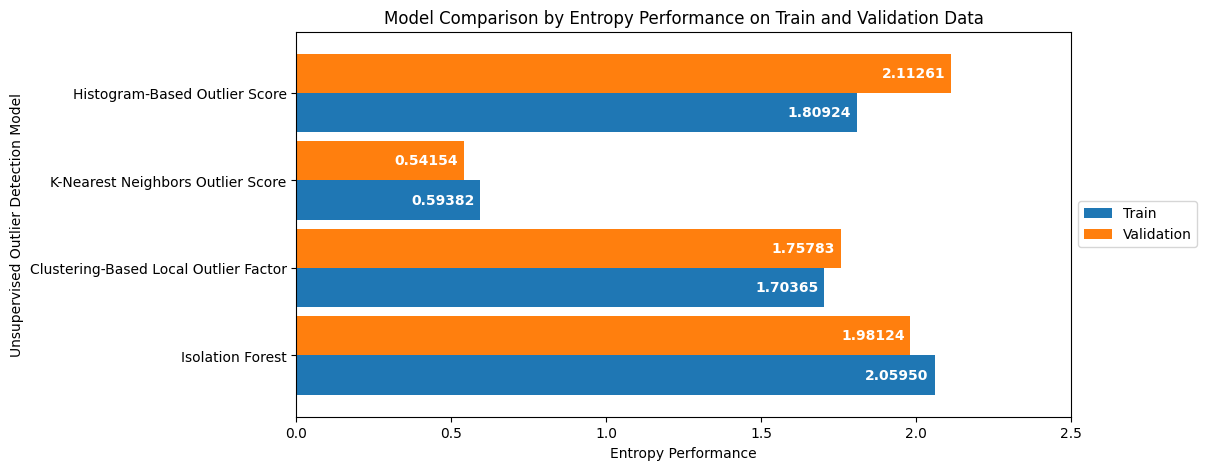

In [434]:
##################################
# Plotting all the Entropy score
# model performance measures
# between the train and validation sets
##################################
unsupervised_model_metric_summary_entropy_plot = unsupervised_model_metric_summary_entropy_plot.plot.barh(figsize=(10, 5), width=0.9)
unsupervised_model_metric_summary_entropy_plot.set_xlim(0.00,2.50)
unsupervised_model_metric_summary_entropy_plot.set_title("Model Comparison by Entropy Performance on Train and Validation Data")
unsupervised_model_metric_summary_entropy_plot.set_xlabel("Entropy Performance")
unsupervised_model_metric_summary_entropy_plot.set_ylabel("Unsupervised Outlier Detection Model")
unsupervised_model_metric_summary_entropy_plot.grid(False)
unsupervised_model_metric_summary_entropy_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in unsupervised_model_metric_summary_entropy_plot.containers:
    unsupervised_model_metric_summary_entropy_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')


In [435]:
##################################
# Consolidating all the Variance score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_variance = unsupervised_model_metric_summary[unsupervised_model_metric_summary['metric']=='Variance']
unsupervised_model_metric_summary_variance_train = unsupervised_model_metric_summary_variance[unsupervised_model_metric_summary_variance['set']=='Train'].loc[:,"metric_value"]
unsupervised_model_metric_summary_variance_validation = unsupervised_model_metric_summary_variance[unsupervised_model_metric_summary_variance['set']=='Validation'].loc[:,"metric_value"]


In [436]:
##################################
# Combining all the Variance score
# model performance measures
# between the train and validation data
##################################
unsupervised_model_metric_summary_variance_plot = pd.DataFrame({'Train': unsupervised_model_metric_summary_variance_train.values,
                                                                'Validation': unsupervised_model_metric_summary_variance_validation.values},
                                                                index=unsupervised_model_metric_summary_variance['model'].unique())
unsupervised_model_metric_summary_variance_plot


,Train,Validation
Isolation Forest,0.008456,0.008951
Clustering-Based Local Outlier Factor,0.211429,0.173675
K-Nearest Neighbors Outlier Score,0.187888,0.178114
Histogram-Based Outlier Score,3.584460,2.975885


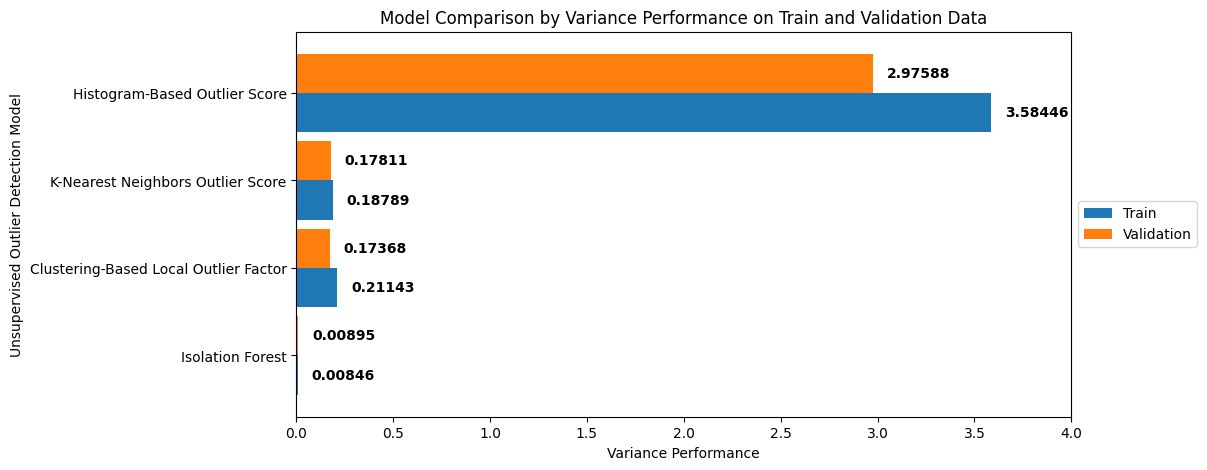

In [437]:
##################################
# Plotting all the Variance score
# model performance measures
# between the train and validation sets
##################################
unsupervised_model_metric_summary_variance_plot = unsupervised_model_metric_summary_variance_plot.plot.barh(figsize=(10, 5), width=0.9)
unsupervised_model_metric_summary_variance_plot.set_xlim(0.00,4.00)
unsupervised_model_metric_summary_variance_plot.set_title("Model Comparison by Variance Performance on Train and Validation Data")
unsupervised_model_metric_summary_variance_plot.set_xlabel("Variance Performance")
unsupervised_model_metric_summary_variance_plot.set_ylabel("Unsupervised Outlier Detection Model")
unsupervised_model_metric_summary_variance_plot.grid(False)
unsupervised_model_metric_summary_variance_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in unsupervised_model_metric_summary_variance_plot.containers:
    unsupervised_model_metric_summary_variance_plot.bar_label(container, fmt='%.5f', padding=10, color='black', fontweight='bold')


In [438]:
##################################
# Conducting external validation
# of the optimal K-Nearest Neighbors Outlier Score
# chosen as one of two best models
# using the test data
##################################
unsupervised_model_knn.fit(X_train)
unsupervised_model_knn_test_scores = unsupervised_model_knn.decision_function(X_test.values)
unsupervised_knn_entropy_test, unsupervised_knn_silhouette_test, unsupervised_knn_variance_test = evaluate_unsupervised_outlier_detection_model(unsupervised_model_knn_test_scores, "Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Test Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using K-Nearest Neighbors Outlier Score (Test Performance)
  Score Entropy     : 0.634
  Score Silhouette  : 0.992
  Score Variance    : 0.208
----------------------------------------


In [439]:
##################################
# Consolidating all the performance measures
# for the K-Nearest Neighbors Outlier Score model
# without ground truth labels
# for the train, validation and test data
##################################
unsupervised_model_knn_metric_summary_final = pd.DataFrame()
unsupervised_model_knn_metric_summary_final['metric'] = ["Entropy", "Silhouette", "Variance"] * 3
unsupervised_model_knn_metric_summary_final['metric_value'] = [unsupervised_knn_entropy_training, unsupervised_knn_silhouette_training, unsupervised_knn_variance_training, unsupervised_knn_entropy_validation, unsupervised_knn_silhouette_validation, unsupervised_knn_variance_validation, unsupervised_knn_entropy_test, unsupervised_knn_silhouette_test, unsupervised_knn_variance_test]
unsupervised_model_knn_metric_summary_final['model'] = ["K-Nearest Neighbors Outlier Score"] * 9
unsupervised_model_knn_metric_summary_final['set'] = (["Train"] * 3) + (["Validation"] * 3) + (["Test"] * 3)
display(unsupervised_model_knn_metric_summary_final)


,metric,metric_value,model,set
0,Entropy,0.593819,K-Nearest Neighbors Outlier Score,Train
1,Silhouette,0.987080,K-Nearest Neighbors Outlier Score,Train
2,Variance,0.187888,K-Nearest Neighbors Outlier Score,Train
3,Entropy,0.541543,K-Nearest Neighbors Outlier Score,Validation
4,Silhouette,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,Variance,0.178114,K-Nearest Neighbors Outlier Score,Validation
6,Entropy,0.634041,K-Nearest Neighbors Outlier Score,Test
7,Silhouette,0.992230,K-Nearest Neighbors Outlier Score,Test
8,Variance,0.207719,K-Nearest Neighbors Outlier Score,Test


In [440]:
##################################
# Conducting external validation
# of the optimal Isolation Forest 
# chosen as one of two best models
# using the test data
##################################
unsupervised_model_cblof.fit(X_train)
unsupervised_model_cblof_test_scores = unsupervised_model_cblof.decision_function(X_test.values)
unsupervised_cblof_entropy_test, unsupervised_cblof_silhouette_test, unsupervised_cblof_variance_test = evaluate_unsupervised_outlier_detection_model(unsupervised_model_cblof_test_scores, "Unsupervised Outlier Detection Using Local Outlier Factor (Test Performance)")


----------------------------------------
 Unsupervised Outlier Detection Using Local Outlier Factor (Test Performance)
  Score Entropy     : 1.568
  Score Silhouette  : 0.760
  Score Variance    : 0.213
----------------------------------------


In [441]:
##################################
# Consolidating all the performance measures
# for the Isolation Forest model
# without ground truth labels
# for the train, validation and test data
##################################
unsupervised_model_cblof_metric_summary_final = pd.DataFrame()
unsupervised_model_cblof_metric_summary_final['metric'] = ["Entropy", "Silhouette", "Variance"] * 3
unsupervised_model_cblof_metric_summary_final['metric_value'] = [unsupervised_cblof_entropy_training, unsupervised_cblof_silhouette_training, unsupervised_cblof_variance_training, unsupervised_cblof_entropy_validation, unsupervised_cblof_silhouette_validation, unsupervised_cblof_variance_validation, unsupervised_cblof_entropy_test, unsupervised_cblof_silhouette_test, unsupervised_cblof_variance_test]
unsupervised_model_cblof_metric_summary_final['model'] = ["Isolation Forest"] * 9
unsupervised_model_cblof_metric_summary_final['set'] = (["Train"] * 3) + (["Validation"] * 3) + (["Test"] * 3)
display(unsupervised_model_cblof_metric_summary_final)

,metric,metric_value,model,set
0,Entropy,1.703652,Isolation Forest,Train
1,Silhouette,0.766419,Isolation Forest,Train
2,Variance,0.211429,Isolation Forest,Train
3,Entropy,1.757826,Isolation Forest,Validation
4,Silhouette,0.723801,Isolation Forest,Validation
5,Variance,0.173675,Isolation Forest,Validation
6,Entropy,1.568048,Isolation Forest,Test
7,Silhouette,0.759947,Isolation Forest,Test
8,Variance,0.212832,Isolation Forest,Test


In [442]:
##################################
# Consolidating all the performance measures
# for the final unsupervised outlier detection models
# without ground truth labels
# for the train, validation and test data
##################################
unsupervised_model_metric_summary_final = pd.concat([unsupervised_model_knn_metric_summary_final,
                                                     unsupervised_model_cblof_metric_summary_final], 
                                                     ignore_index=True)
print('Consolidated Unsupervised Outlier Detection Model Performance on Train, Validation and Test Data: ')
display(unsupervised_model_metric_summary_final)


Consolidated Unsupervised Outlier Detection Model Performance on Train, Validation and Test Data: 


,metric,metric_value,model,set
0,Entropy,0.593819,K-Nearest Neighbors Outlier Score,Train
1,Silhouette,0.987080,K-Nearest Neighbors Outlier Score,Train
2,Variance,0.187888,K-Nearest Neighbors Outlier Score,Train
3,Entropy,0.541543,K-Nearest Neighbors Outlier Score,Validation
4,Silhouette,1.000000,K-Nearest Neighbors Outlier Score,Validation
5,Variance,0.178114,K-Nearest Neighbors Outlier Score,Validation
6,Entropy,0.634041,K-Nearest Neighbors Outlier Score,Test
7,Silhouette,0.992230,K-Nearest Neighbors Outlier Score,Test
8,Variance,0.207719,K-Nearest Neighbors Outlier Score,Test
9,Entropy,1.703652,Isolation Forest,Train


In [443]:
##################################
# Consolidating all the Silhouette score
# model performance measures
# between the train, validation and test data
##################################
unsupervised_model_metric_summary_final_silhouette = unsupervised_model_metric_summary_final[unsupervised_model_metric_summary_final['metric']=='Silhouette']
unsupervised_model_metric_summary_final_silhouette_train = unsupervised_model_metric_summary_final_silhouette[unsupervised_model_metric_summary_final_silhouette['set']=='Train'].loc[:,"metric_value"]
unsupervised_model_metric_summary_final_silhouette_validation = unsupervised_model_metric_summary_final_silhouette[unsupervised_model_metric_summary_final_silhouette['set']=='Validation'].loc[:,"metric_value"]
unsupervised_model_metric_summary_final_silhouette_test = unsupervised_model_metric_summary_final_silhouette[unsupervised_model_metric_summary_final_silhouette['set']=='Test'].loc[:,"metric_value"]


In [444]:
##################################
# Combining all the Silhouette score
# model performance measures
# between the train, validation and test data
##################################
unsupervised_model_metric_summary_final_silhouette_plot = pd.DataFrame({'Train': unsupervised_model_metric_summary_final_silhouette_train.values,
                                                                        'Validation': unsupervised_model_metric_summary_final_silhouette_validation.values,
                                                                        'Test': unsupervised_model_metric_summary_final_silhouette_test.values},
                                                                        index=unsupervised_model_metric_summary_final_silhouette['model'].unique())
unsupervised_model_metric_summary_final_silhouette_plot


,Train,Validation,Test
K-Nearest Neighbors Outlier Score,0.987080,1.000000,0.992230
Isolation Forest,0.766419,0.723801,0.759947


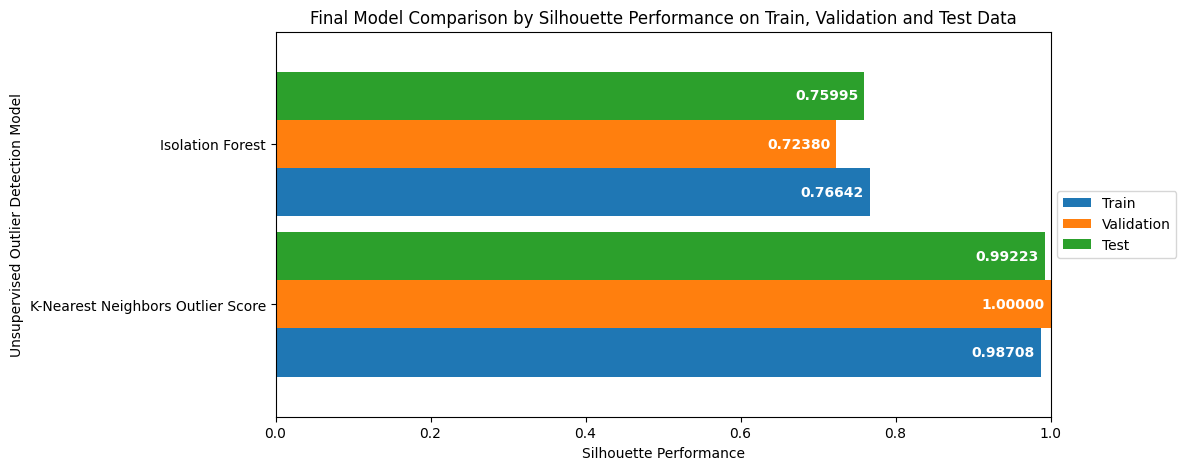

In [445]:
##################################
# Plotting all the Silhouette score
# model performance measures
# between the train, validation and test sets
##################################
unsupervised_model_metric_summary_final_silhouette_plot = unsupervised_model_metric_summary_final_silhouette_plot.plot.barh(figsize=(10, 5), width=0.9)
unsupervised_model_metric_summary_final_silhouette_plot.set_xlim(0.00,1.00)
unsupervised_model_metric_summary_final_silhouette_plot.set_title("Final Model Comparison by Silhouette Performance on Train, Validation and Test Data")
unsupervised_model_metric_summary_final_silhouette_plot.set_xlabel("Silhouette Performance")
unsupervised_model_metric_summary_final_silhouette_plot.set_ylabel("Unsupervised Outlier Detection Model")
unsupervised_model_metric_summary_final_silhouette_plot.grid(False)
unsupervised_model_metric_summary_final_silhouette_plot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
for container in unsupervised_model_metric_summary_final_silhouette_plot.containers:
    unsupervised_model_metric_summary_final_silhouette_plot.bar_label(container, fmt='%.5f', padding=-50, color='white', fontweight='bold')


# 2. Summary <a class="anchor" id="Summary"></a>

# 3. References <a class="anchor" id="References"></a>
* **[Book]** [Applied Predictive Modeling](http://appliedpredictivemodeling.com/) by Max Kuhn and Kjell Johnson
* **[Book]** [An Introduction to Statistical Learning](https://www.statlearning.com/) by Gareth James, Daniela Witten, Trevor Hastie and Rob Tibshirani
* **[Book]** [Outlier Analysis](https://link.springer.com/book/10.1007/978-3-319-47578-3) by Charu Aggarwal 
* **[Book]** [Beginning Anomaly Detection Using Python-Based Deep Learning: With Keras and PyTorch](https://link.springer.com/book/10.1007/978-1-4842-5177-5) by Sridhar Alla and Suman Kalyan Adari
* **[Python Library API]** [NumPy](https://numpy.org/doc/) by NumPy Team
* **[Python Library API]** [pandas](https://pandas.pydata.org/docs/) by Pandas Team
* **[Python Library API]** [seaborn](https://seaborn.pydata.org/) by Seaborn Team
* **[Python Library API]** [matplotlib.pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) by MatPlotLib Team
* **[Python Library API]** [matplotlib.image](https://matplotlib.org/stable/api/image_api.html) by MatPlotLib Team
* **[Python Library API]** [matplotlib.offsetbox](https://matplotlib.org/stable/api/offsetbox_api.html) by MatPlotLib Team
* **[Python Library API]** [itertools](https://docs.python.org/3/library/itertools.html) by Python Team
* **[Python Library API]** [operator](https://docs.python.org/3/library/operator.html) by Python Team
* **[Python Library API]** [sklearn.experimental](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.experimental) by Scikit-Learn Team
* **[Python Library API]** [sklearn.impute](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.impute) by Scikit-Learn Team
* **[Python Library API]** [sklearn.linear_model](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model) by Scikit-Learn Team
* **[Python Library API]** [sklearn.preprocessing](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing) by Scikit-Learn Team
* **[Python Library API]** [scipy](https://docs.scipy.org/doc/scipy/) by SciPy Team
* **[Python Library API]** [sklearn.tree](https://scikit-learn.org/stable/modules/tree.html) by Schttps://scikit-learn.org/stable/api/sklearn.neighbors.htmlikit-Learn Team
* **[Python Library API]** [sklearn.neighbors](https://scikit-learn.org/stable/api/sklearn.neighbors.html) by Scikit-Learn Team
* **[Python Library API]** [StatsModels](https://www.statsmodels.org/stable/index.html) by StatsModels Team
* **[Python Library API]** [SciPy](https://scipy.org/) by SciPy Team
* **[Python Library API]** [pyod](https://pyod.readthedocs.io/en/latest/index.html) by PyOD Team
* **[Python Library API]** [prince](https://github.com/MaxHalford/prince) by Prince Team
* **[Article]** [Awesome Outlier Detection Resources](https://github.com/durgeshsamariya/awesome-outlier-detection-resources) by Durgesh Samariya (GitHub.Com)
* **[Video Tutorial]** [Complete Anomaly Detection Tutorials Machine Learning And Its Types With Implementation](https://www.youtube.com/watch?v=OS9xRGKfx4E&t=1790s) by Krish Naik (YouTube)
* **[Course]** [DataCamp Python Data Analyst Certificate](https://app.datacamp.com/learn/career-tracks/data-analyst-with-python) by DataCamp Team (DataCamp)
* **[Course]** [DataCamp Python Associate Data Scientist Certificate](https://app.datacamp.com/learn/career-tracks/associate-data-scientist-in-python) by DataCamp Team (DataCamp)
* **[Course]** [DataCamp Python Data Scientist Certificate](https://app.datacamp.com/learn/career-tracks/data-scientist-in-python) by DataCamp Team (DataCamp)
* **[Course]** [DataCamp Machine Learning Engineer Certificate](https://app.datacamp.com/learn/career-tracks/machine-learning-engineer) by DataCamp Team (DataCamp)
* **[Course]** [DataCamp Machine Learning Scientist Certificate](https://app.datacamp.com/learn/career-tracks/machine-learning-scientist-with-python) by DataCamp Team (DataCamp)
* **[Course]** [IBM Data Analyst Professional Certificate](https://www.coursera.org/professional-certificates/ibm-data-analyst) by IBM Team (Coursera)
* **[Course]** [IBM Data Science Professional Certificate](https://www.coursera.org/professional-certificates/ibm-data-science) by IBM Team (Coursera)
* **[Course]** [IBM Machine Learning Professional Certificate](https://www.coursera.org/professional-certificates/ibm-machine-learning) by IBM Team (Coursera)



In [446]:
from IPython.display import display, HTML
display(HTML("<style>.rendered_html { font-size: 15px; font-family: 'Trebuchet MS'; }</style>"))